In [1]:
# 1. Load Packages --------------------------------------------------------
suppressMessages({
  library(CellChat)
  library(ggplot2)
  library(patchwork)
  library(scales) # For color generation

library(Seurat)
library(dplyr)
library(Matrix)
library(zellkonverter)
library(SingleCellExperiment)
library(CellChat)
library(patchwork)
library(ggplot2)
library(future)

  library(CellChat)
  library(ggplot2)
  library(patchwork)
  library(scales)
  library(Seurat)
    library(readr)
})


library(stringr) #deal with string
options(stringsAsFactors = FALSE)
options(future.globals.maxSize = 10 * 1024^3)  

# 1. Set up parallelization and load object  ======
plan("multicore", workers = 15)


In [2]:
setwd("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard")

In [3]:
# Read the object
cellchat_extended <- readRDS("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/cellchat_fractions/CellChat_obj_Extended_protocol_netP.RDS")
cellchat_standard <- readRDS("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/cellchat_fractions/CellChat_obj_standard_protocol_netP.RDS")
cell_types_extended <- levels(cellchat_extended@idents)

 levels(cellchat_extended@idents)

cell_types_standard <- levels(cellchat_standard@idents)

 levels(cellchat_standard@idents)


group.new <- union(cell_types_extended, cell_types_standard) 


cellchat_extended <- liftCellChat(cellchat_extended, group.new)
cellchat_standard  <- liftCellChat(cellchat_standard,  group.new)


object.list <- list(Standard_protocol = cellchat_standard, Extended_protocol = cellchat_extended)
cellchat_merged <- mergeCellChat(object.list, add.names = names(object.list), cell.prefix = TRUE)


# For Standard Protocol
df_standard <- subsetCommunication(cellchat_standard)
# write.csv(df_standard, file = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv", row.names = FALSE)

# For Rejection
df_extended <- subsetCommunication(cellchat_extended)
# write.csv(df_extended, file = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/cellchat_Extended_info_table.csv", row.names = FALSE)
# 1. RankNet differential signaling analysis
ranknet_frame <- rankNet(
  cellchat_merged,
  mode = "comparison",
  stacked = TRUE,
  do.stat = TRUE,
  cutoff.pvalue = 0.05,
  return.data = TRUE,
  measure = "weight"
)$signaling.contribution

# Save as CSV instead of write.table
# write.csv(
#   ranknet_frame,
#   file = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/Diff_ALL_sources_Extended_vs_standard.csv",
#   row.names = FALSE
# )

[1] "CM"                         "Endocardial/lymphatic EC"  
 [3] "Endothelial cells (baboon)" "Fibroblasts"               
 [5] "Lymphoids (baboon)"         "Mast cells (baboon)"       
 [7] "Mural cells"                "Myeloids (baboon)"         
 [9] "Neuronal cells"             "Resident Immune"           
[11] "Vascular EC"

[1] "CM"                         "Endocardial/lymphatic EC"  
 [3] "Endothelial cells (baboon)" "Fibroblasts"               
 [5] "Lymphoids (baboon)"         "Mast cells (baboon)"       
 [7] "Mural cells"                "Myeloids (baboon)"         
 [9] "Neuronal cells"             "Resident Immune"           
[11] "Vascular EC"

The CellChat object will be lifted up using the cell labels CM, Endocardial/lymphatic EC, Endothelial cells (baboon), Fibroblasts, Lymphoids (baboon), Mast cells (baboon), Mural cells, Myeloids (baboon), Neuronal cells, Resident Immune, Vascular EC



Update slots object@net, object@netP, object@idents in a single dataset... 


The CellChat object will be lifted up using the cell labels CM, Endocardial/lymphatic EC, Endothelial cells (baboon), Fibroblasts, Lymphoids (baboon), Mast cells (baboon), Mural cells, Myeloids (baboon), Neuronal cells, Resident Immune, Vascular EC



Update slots object@net, object@netP, object@idents in a single dataset... 


Warning message in mergeCellChat(object.list, add.names = names(object.list), cell.prefix = TRUE):
“Prefix cell names!”


The cell barcodes in merged 'meta' is  ATCCACCGTATGCTAC___PAV66 TTCTTCCCACGACAAG___PAV66 CTCAACCAGGCATTTC___PAV66 TCCCATGCATTAGGAA___PAV66 CCGTAGGCACACGTGC___PAV66 CTATCCGCATCTCAAG___PAV66 


Warning message in mergeCellChat(object.list, add.names = names(object.list), cell.prefix = TRUE):
“The cell barcodes in merged 'meta' is different from those in the used data matrix.
              We now simply assign the colnames in the data matrix to the rownames of merged 'mata'!”
Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



In [3]:
# Read the CSV for downstream use
dif_table <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/Diff_ALL_sources_Extended_vs_standard.csv", header = TRUE)
signal_path <- unique(dif_table$name)

# 2. Compare total number of interactions and strength
gg1 <- compareInteractions(cellchat_merged, show.legend = FALSE, group = c(1,2))

gg2 <- compareInteractions(cellchat_merged, show.legend = FALSE, group = c(1,2), measure = "weight")
print(gg1)
print(gg2)


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'as.data.frame': object 'cellchat_merged' not found


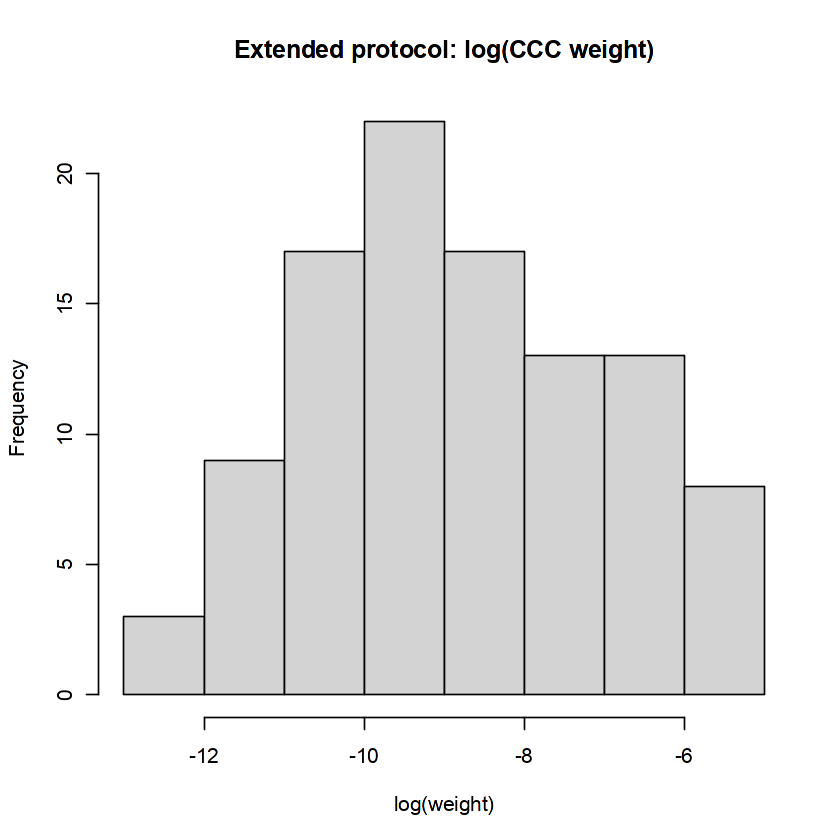

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


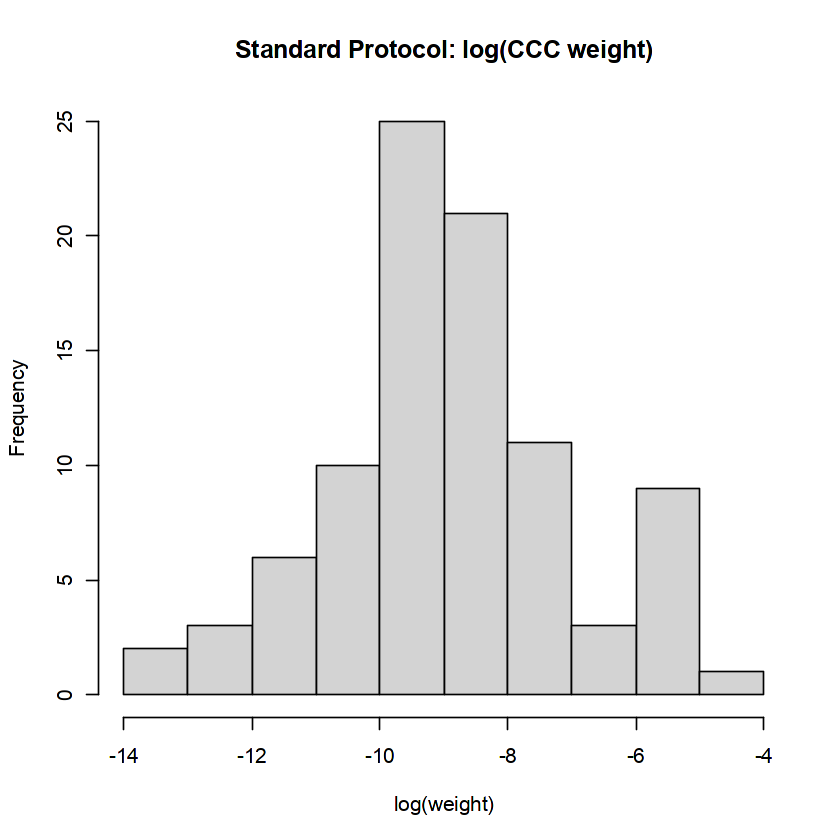

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


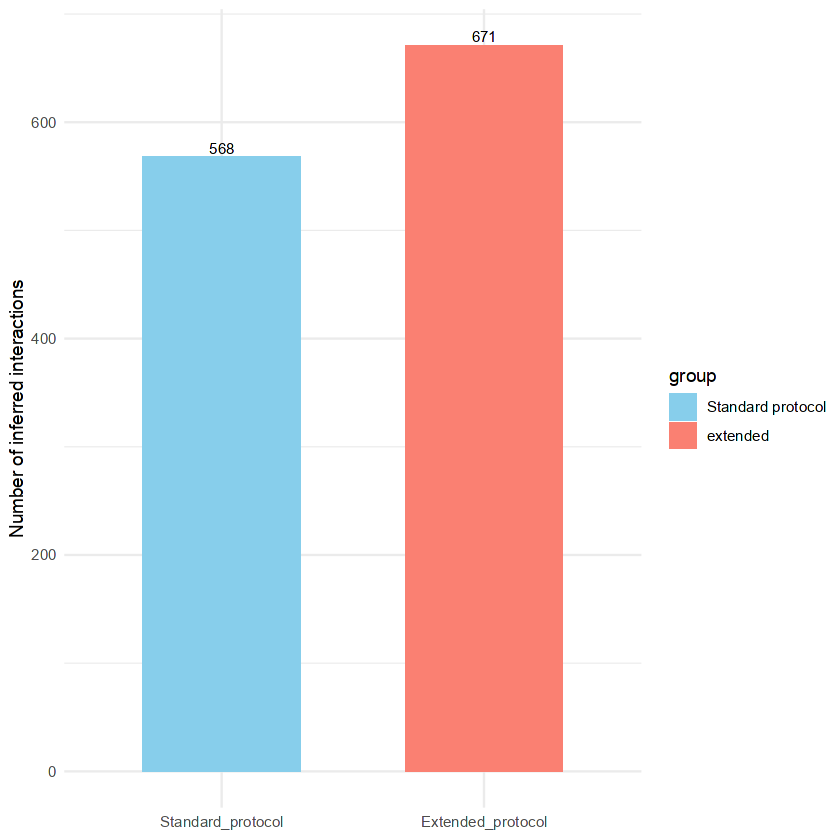

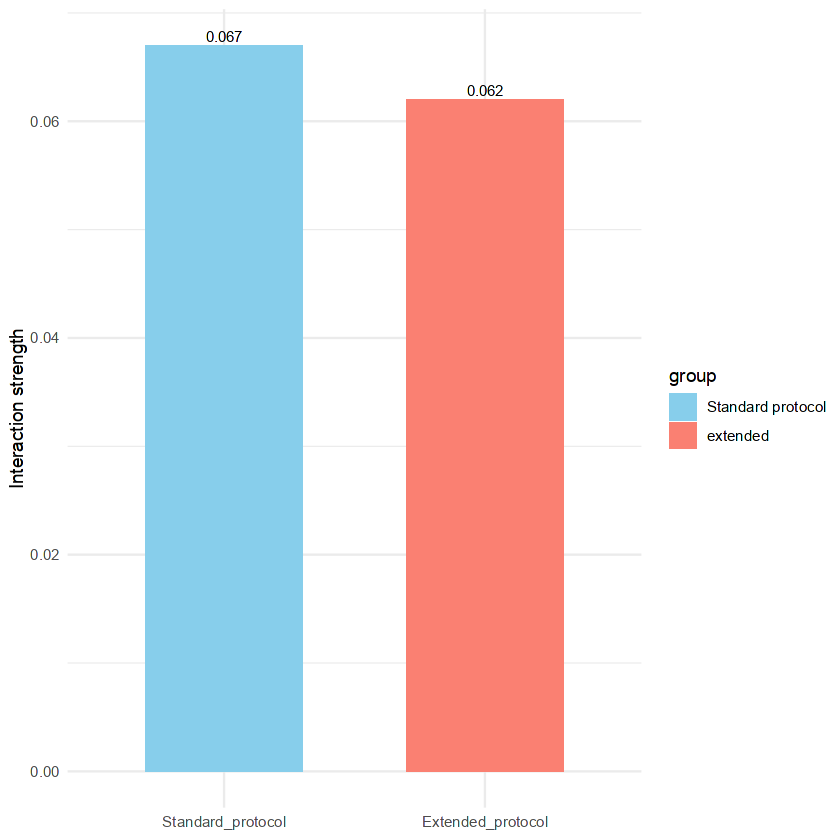

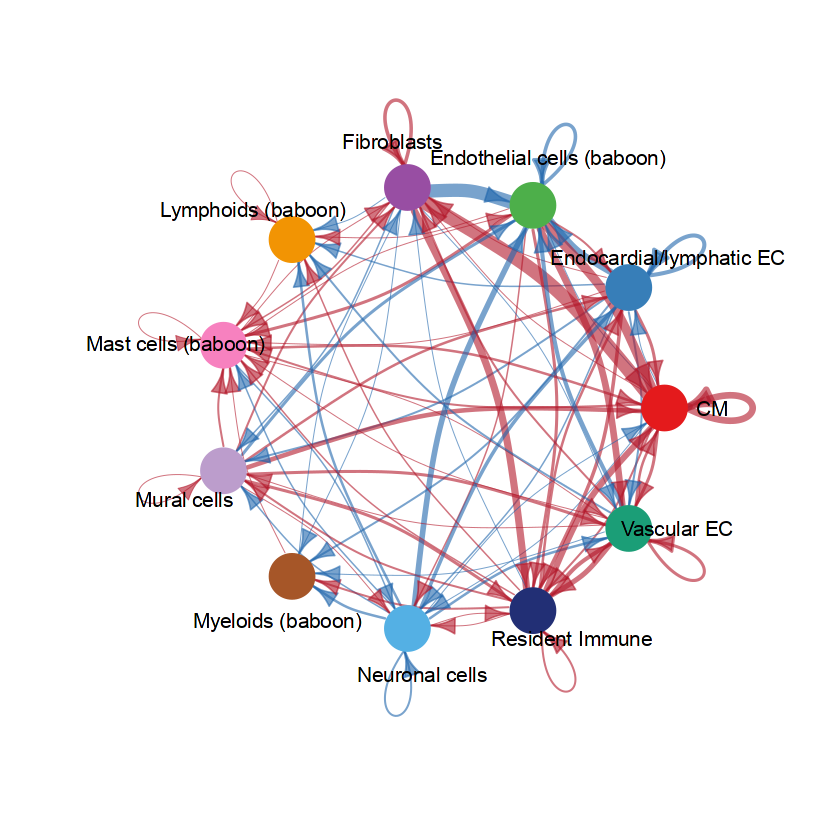

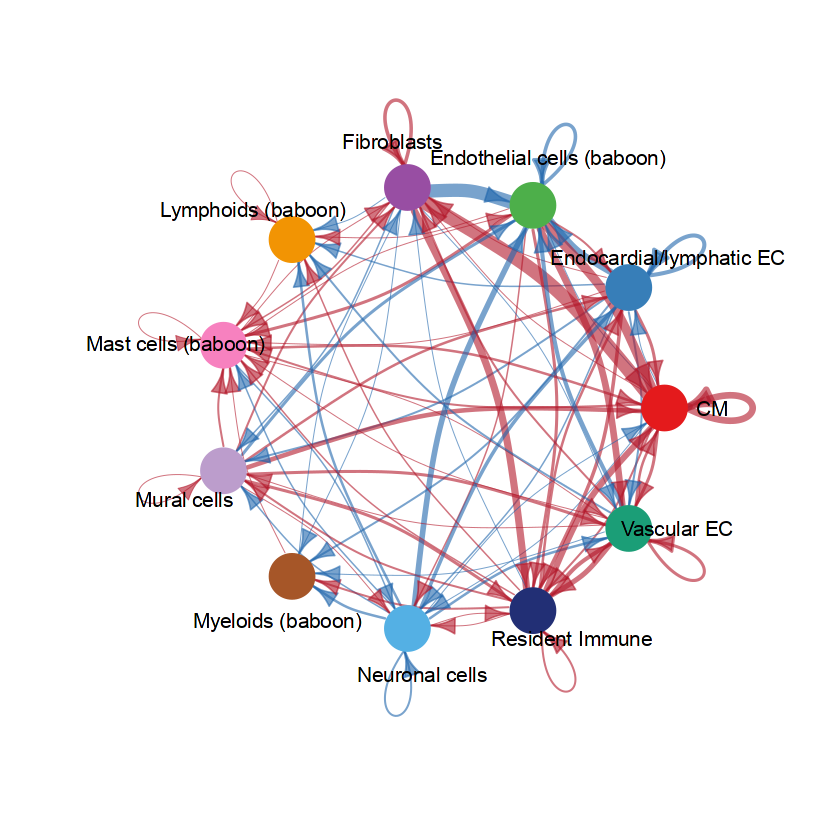

In [11]:
# 3. Plot CCC probability distributions (histograms)
hist(log(cellchat_extended@net$weight), main="Extended protocol: log(CCC weight)", xlab="log(weight)")
hist(log(cellchat_standard@net$weight), main="Standard Protocol: log(CCC weight)", xlab="log(weight)")
library(ggplot2)

# Define fill color vector for as many bars as you have; here, first two special, others grey
cols1 <- c("skyblue", "salmon", rep("grey", nrow(ggplot_build(gg1)$data[[1]]) - 2))
cols2 <- c("skyblue", "salmon", rep("grey", nrow(ggplot_build(gg2)$data[[1]]) - 2))

# Specify which fill values/levels correspond to your groups
# Adjust breaks as needed if group levels differ (e.g., numeric vs character)
gg1 +
  scale_fill_manual(
    values = cols1,
    breaks = c("1", "2"),
    labels = c("Standard protocol", "extended")
  ) +
  theme_minimal()

gg2 +
  scale_fill_manual(
    values = cols2,
    breaks = c("1", "2"),
    labels = c("Standard protocol", "extended")
  ) +
  theme_minimal()
netVisual_diffInteraction(
  cellchat_merged, 
  weight.scale = TRUE,
  # color.use = c("blue", "red"),   # blue=PerProtocol, red=Rejection
  arrow.size = 1
)


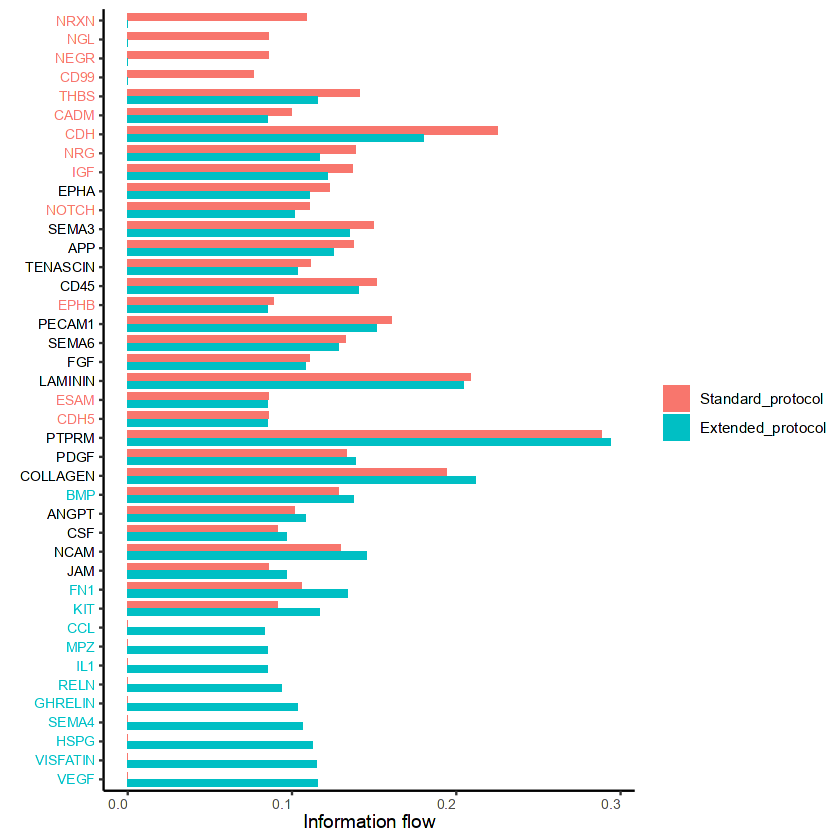

In [12]:
# Rank signaling pathways by differences in overall communication strength
rankNet(cellchat_merged, mode = "comparison", stacked = FALSE, do.stat = TRUE)


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


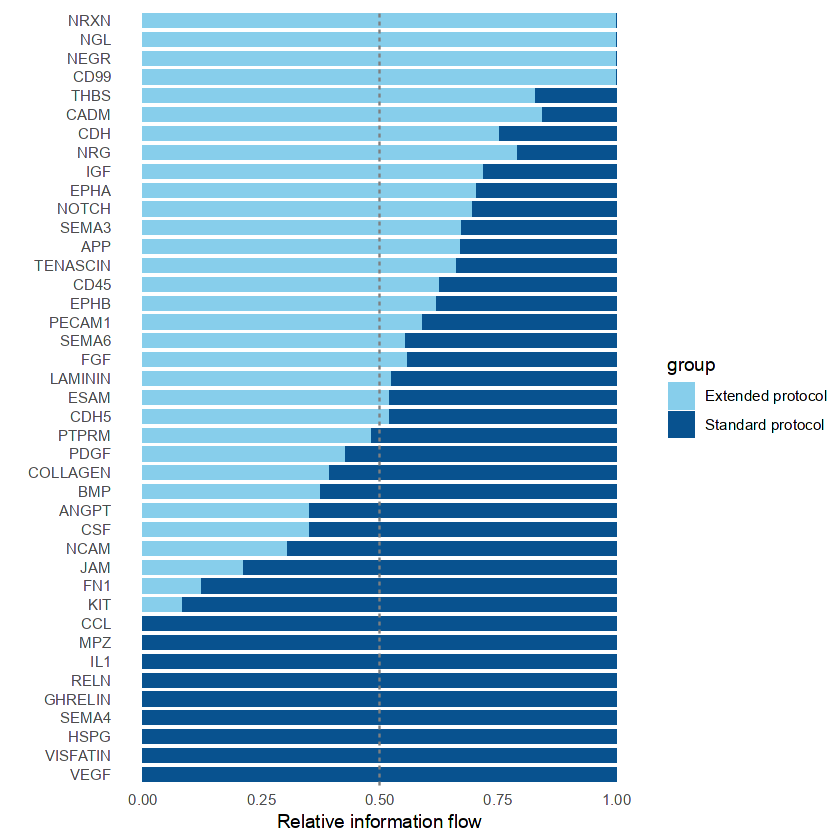

In [13]:
# Re-run rankNet with stacked = TRUE to get the appropriate plot structure
p_ranknet_stacked <- rankNet(
  cellchat_merged,
  mode = "comparison",
  stacked = TRUE, # <--- Change this
  do.stat = TRUE
)

# Apply your custom colors—this should now work
p_ranknet_stacked +
  scale_fill_manual(
    values = c("Standard_protocol" = "skyblue",
               "Extended_protocol" = "#08528f"),
    # Fix labels to match the legend order if needed, but the values mapping is key
    labels = c("Standard protocol", "Extended protocol") # Assuming this is the order in the legend
  ) +
  theme_minimal() +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )

In [14]:
# 1. Re-run rankNet, REMOVING the invalid 'height' and 'width' arguments
p_ranknet_stacked <- rankNet(
  cellchat_merged,
  mode = "comparison",
  stacked = TRUE,
  do.stat = TRUE
)

# 2. Apply custom colors and theme, then assign the final plot to a variable
final_plot <- p_ranknet_stacked +
  scale_fill_manual(
    values = c("Standard_protocol" = "skyblue",
               "Extended_protocol" = "#08528f"),
    # Fix labels for clarity in the legend
    labels = c("Standard protocol", "Extended protocol")
  ) +
  theme_minimal() +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )

# 3. Save the final plot as a PDF with 300 DPI using ggsave (where width/height belong)

# Define the file path for saving
file_path <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Typical cellchat stuff/rankNet_Comparison_Stacked_300dpi.pdf"

# Use ggsave to save the plot. Adjust width and height here as needed.
ggsave(
  filename = file_path,
  plot = final_plot,
  device = "pdf",
  width = 5,
  height = 5,
  units = "in",
  dpi = 300
)

cat(paste("Plot successfully saved to:", file_path, "\n"))

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


Plot successfully saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Typical cellchat stuff/rankNet_Comparison_Stacked_300dpi.pdf 


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


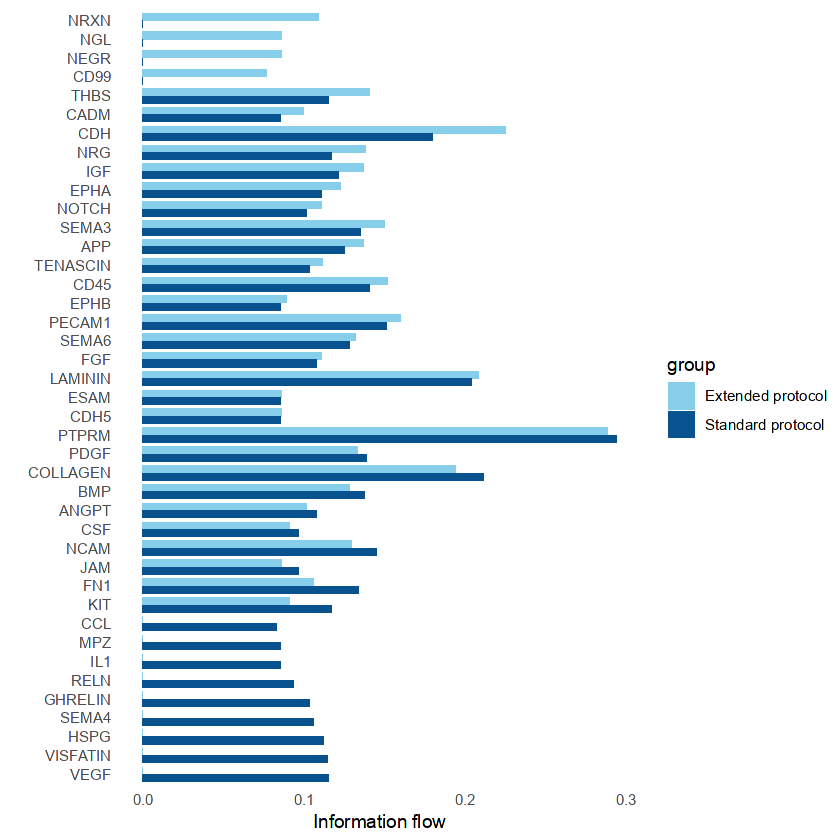

In [9]:
# Run rankNet and get ggplot object
p_ranknet <- rankNet(
  cellchat_merged,
  mode = "comparison",
  stacked = FALSE,
  do.stat = TRUE
)

# Apply your custom colors: skyblue for Standard, dark navy (#08528f) for Extended
p_ranknet +
  scale_fill_manual(
    values = c("Standard_protocol" = "skyblue",
               "Extended_protocol" = "#08528f"),
     labels = c("Standard protocol", "Extended protocol")
  ) +
  theme_minimal() +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )



# Ligand-receptor pairs expression levels- Violin plots

Generating gene expression plot for pathway: NOTCH in Standard protocol...


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


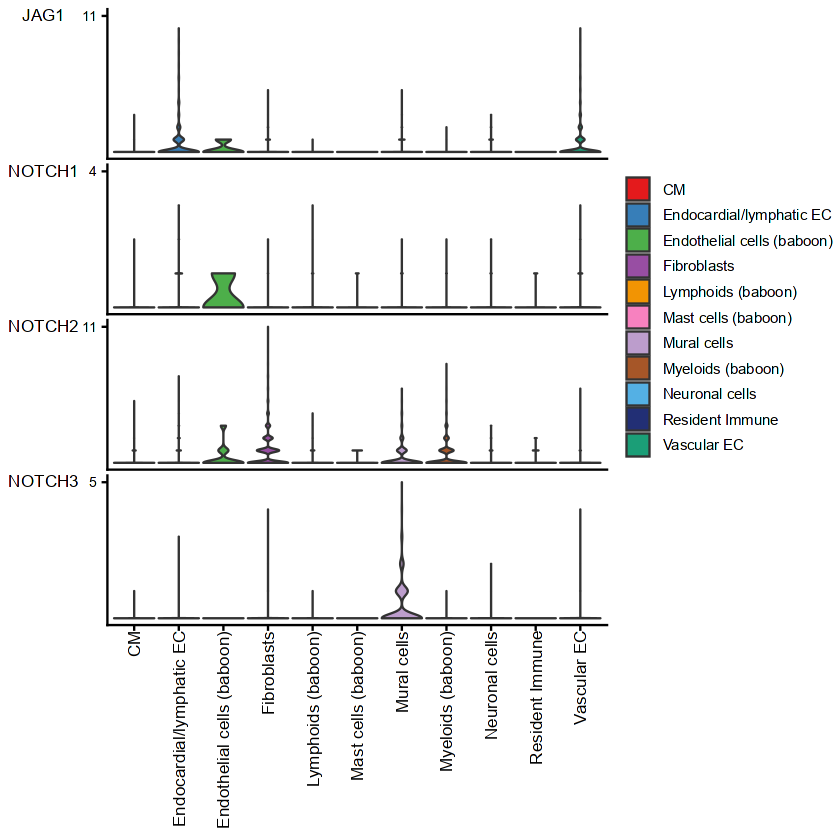

In [20]:
# 1. Define the pathways you want to inspect
pathways_to_check <- c("NOTCH")
object_to_check <- cellchat_standard

# Load necessary libraries (ensure ggplot2 is loaded for print)
library(ggplot2) 

# 2. Loop through each pathway and generate the plot using the exported function
for (pw in pathways_to_check) {
    cat(paste("Generating gene expression plot for pathway:", pw, "in Standard protocol...\n"))

    # The issue was passing extra arguments that the internal function didn't like.
    # The simplest, most robust call is:
    p <- CellChat::plotGeneExpression(
        object_to_check, 
        signaling = pw 
    ) + ggplot2::ggtitle(paste("Standard Protocol: L-R Gene Expression for", pw))
    
    # Check if a ggplot object was returned before printing
    if (inherits(p, "ggplot")) {
        print(p)
    } else {
        cat(paste("Warning: plotGeneExpression for", pw, "did not return a standard plot object. May indicate no expression data for the pathway genes.\n"))
    }
}

# --- Continue to run the plot generation for VEGF and HSPG ---

# Note: The prior manual gene extraction and 'features.plot' failed due to 
# unexported function access and column mismatch. Relying on the package's 
# official function ('plotGeneExpression') is the standard practice.
# This should now work for all three pathways.

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


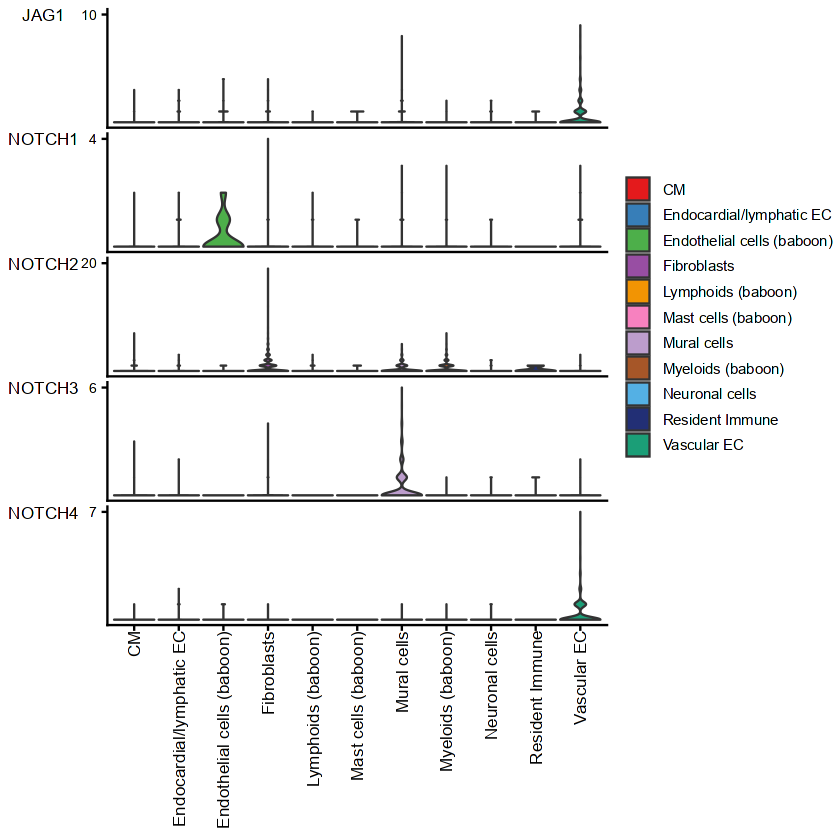

In [21]:
# 1. Inspect the remaining pathways in the Standard protocol
# pathways_to_check_std <- c("VISFATIN")
# object_to_check_std <- cellchat_extended

# for (pw in pathways_to_check_std) {
#     p <- CellChat::plotGeneExpression(
#         object_to_check_std, 
#         signaling = pw 
#     ) + ggplot2::ggtitle(paste("Standard Protocol: L-R Gene Expression for", pw))
#     if (inherits(p, "ggplot")) { print(p) }
# }

# 2. Inspect the same pathways in the Extended protocol (where they were found)
pathways_to_check_ext <- c("NOTCH")
object_to_check_ext <- cellchat_extended

for (pw in pathways_to_check_ext) {
    p <- CellChat::plotGeneExpression(
        object_to_check_ext, 
        signaling = pw 
    ) + ggplot2::ggtitle(paste("Extended Protocol: L-R Gene Expression for", pw))
    if (inherits(p, "ggplot")) { print(p) }
}

In [10]:
library(dplyr)
library(tidyr)

# Run rankNet with unstacked (group-level) results
ranknet_frame <- rankNet(
  cellchat_merged,
  mode = "comparison",
  stacked = FALSE,
  do.stat = TRUE,
  cutoff.pvalue = 1,    # show all
  return.data = TRUE,
  measure = "weight"
)$signaling.contribution

# Save the raw (long) table for transparency
write.csv(ranknet_frame, "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/GENERAL_Diff_ALL_sources_GROUP_comparison.csv", row.names = FALSE)

# Pivot wider for direct group-by-group pathway comparison
wide_frame <- ranknet_frame %>%
  select(name, contribution, pvalues, group) %>%
  pivot_wider(
    id_cols = name,
    names_from = group,
    values_from = c(contribution, pvalues)
  )

# Write to CSV
write.csv(wide_frame, "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/Wide_Diff_ALL_sources_GROUP_comparison.csv", row.names = FALSE)



Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


The following object is masked from ‘package:igraph’:

    crossing




In [11]:
# Load interaction tables
df_standard <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv")
df_extended <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/cellchat_Extended_CCC_info_table.csv")

# Combine all unique pathways from both conditions
all_pathways <- unique(c(
    as.character(unique(df_standard$pathway_name)),
    as.character(unique(df_extended$pathway_name))
))
all_pathways <- all_pathways[!is.na(all_pathways) & all_pathways != ""]

# Directory to save
outdir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/pathway_specific/"
dir.create(outdir, showWarnings = FALSE)

# Loop through each pathway and save comparison table
for (pw in all_pathways) {
  # Flexible match (case insensitive, handles errors)
  pw_standard <- df_standard %>%
    filter(tolower(pathway_name) == tolower(pw)) %>%
    select(pathway_name, ligand, receptor, source, target, prob, pval) %>%
    mutate(group = "Standard_protocol")
  
  pw_rej <- df_extended %>%
    filter(tolower(pathway_name) == tolower(pw)) %>%
    select(pathway_name, ligand, receptor, source, target, prob, pval) %>%
    mutate(group = "extended")
  
  pw_all <- bind_rows(pw_standard, pw_rej) %>%
    arrange(pathway_name, ligand, receptor, source, target, group)
  
  # Only write if at least one row exists
  if (nrow(pw_all) > 0) {
    outfn <- paste0(outdir, gsub("[^A-Za-z0-9]", "_", pw), "_group_comparison.csv")
    write_csv(pw_all, outfn)
  }
}


In [12]:
library(dplyr)
library(tidyr)
library(readr)
library(stringr)

# I/O
in_standard <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv"

# Candidate paths for the Extended CSV (fix double 'nhadizad' + try both filenames)
extended_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results"
candidates_extended <- file.path(extended_dir, c(
  "cellchat_Extended_CCC_info_table.csv",
  "cellchat_Extended_info_table.csv"
))

# Pick the first existing candidate
in_extended <- NULL
for (cand in candidates_extended) {
  if (file.exists(cand)) { in_extended <- cand; break }
}

# Sanity checks
missing_files <- c(
  if (!file.exists(in_standard)) in_standard else NULL,
  if (is.null(in_extended)) paste0("{none of: ", paste(candidates_extended, collapse=" , "), " }") else NULL
)
if (length(missing_files) > 0) {
  stop(paste0(
    "File(s) not found:\n- ",
    paste(missing_files, collapse = "\n- "),
    "\n\nFix the path(s) above and re-run."
  ))
}

out_dir <- extended_dir

# Read tables exported via subsetCommunication()
df_std <- read.csv(in_standard, check.names = FALSE)
df_ext <- read.csv(in_extended, check.names = FALSE)

# Standardize expected column names
names(df_std) <- tolower(names(df_std))
names(df_ext) <- tolower(names(df_ext))

# Check essential columns
need <- c("pathway_name", "source", "target", "prob", "pval")
missing_std <- setdiff(need, names(df_std))
missing_ext <- setdiff(need, names(df_ext))
if (length(missing_std) > 0 || length(missing_ext) > 0) {
  stop(paste0("Missing required columns.\n",
              "std missing: ", paste(missing_std, collapse=", "),
              "\next missing: ", paste(missing_ext, collapse=", ")))
}

# Label each condition
df_std$group <- "Standard_protocol"
df_ext$group <- "Extended_protocol"

# Combine
df_all <- bind_rows(df_std, df_ext) %>%
  mutate(
    source       = as.character(source),
    target       = as.character(target),
    pathway_name = as.character(pathway_name)
  )

# Aggregate sender–pathway–target per group
agg_edge <- function(x) {
  x %>%
    group_by(group, source, pathway_name, target) %>%
    summarise(
      contribution = sum(prob, na.rm = TRUE),
      pvalue_min   = suppressWarnings(min(pval, na.rm = TRUE)),
      .groups = "drop"
    )
}
edges_by_group <- agg_edge(df_all)

# Per-sender–pathway totals across ALL targets
pathway_totals <- edges_by_group %>%
  group_by(group, source, pathway_name) %>%
  summarise(
    contribution = sum(contribution, na.rm = TRUE),
    pvalue_min   = suppressWarnings(min(pvalue_min, na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(target = "ALL") %>%
  select(group, source, pathway_name, target, contribution, pvalue_min)

# Combine + complete grid
edges_and_totals <- bind_rows(edges_by_group, pathway_totals)
complete_edges <- edges_and_totals %>%
  complete(
    group = c("Standard_protocol", "Extended_protocol"),
    source, pathway_name, target,
    fill = list(contribution = 0, pvalue_min = NA_real_)
  )

# Split to groups
std_edge <- complete_edges %>%
  filter(group == "Standard_protocol") %>%
  select(source, pathway_name, target,
         contribution_std = contribution, pvalue_min_std = pvalue_min)

ext_edge <- complete_edges %>%
  filter(group == "Extended_protocol") %>%
  select(source, pathway_name, target,
         contribution_ext = contribution, pvalue_min_ext = pvalue_min)

# Join + diffs
comp_edge <- std_edge %>%
  full_join(ext_edge, by = c("source","pathway_name","target")) %>%
  mutate(
    contribution_std = replace_na(contribution_std, 0),
    contribution_ext = replace_na(contribution_ext, 0),
    diff_contribution = contribution_ext - contribution_std,
    log2fc_contribution = log2((contribution_ext + 1e-6) / (contribution_std + 1e-6))
  ) %>%
  select(
    sender = source,
    pathway = pathway_name,
    target,
    contribution_std, pvalue_min_std,
    contribution_ext, pvalue_min_ext,
    diff_contribution, log2fc_contribution
  ) %>%
  arrange(sender, pathway, desc(target == "ALL"), desc(diff_contribution))

# Write one CSV per sender
safe_filename <- function(x) gsub("[^A-Za-z0-9._-]", "_", x)
all_senders <- sort(unique(comp_edge$sender))
for (s in all_senders) {
  out_fn <- file.path(out_dir, paste0("Sender_", safe_filename(s), "_pathway_target_comparison.csv"))
  comp_edge %>% filter(sender == s) %>% write_csv(out_fn)
  cat("Saved:", out_fn, "\n")
}

# Master table too
master_fn <- file.path(out_dir, "ALL_senders_pathway_target_comparison_whole.csv")
write_csv(comp_edge, master_fn)
cat("Saved master:", master_fn, "\n")


Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/Sender_CM_pathway_target_comparison.csv 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/Sender_Endocardial_lymphatic_EC_pathway_target_comparison.csv 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/Sender_Endothelial_cells__baboon__pathway_target_comparison.csv 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/Sender_Fibroblasts_pathway_target_comparison.csv 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/Sender_Lymphoids__baboon__pathway_target_comparison.csv 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/Sender_Mast_cell

# Fancy chord plot with probabilities around the circle

In [24]:
library(dplyr)
library(tidyr)
library(circlize)
library(viridis)

# Load the data from your CSV file
df_ext <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/cellchat_Extended_info_table.csv")

# Filter for the specific pathway (VISFATIN in this case)
tgfb_data <- df_ext %>%
  filter(pathway_name == "IL1")

# Define custom colors (Crucial: This list must contain ALL cell types you want to visualize)
custom_colors <- c(
  "Lymphoids (baboon)" = "#FFA500", 
  "Mast cells (baboons)" = "#FFC0CB", 
  "Mural cells" = "#C8A2C8", 
  "Myeloids (baboon)" = "#A52A2A", 
  "Neuronal cells" = "#87CEFA", 
  "Resident Immune" = "#000080", 
  "Vascular EC" = "#006400", 
  "CM" = "#FA8072", 
  "Fibroblasts" = "#A020F0",
  "Endothelial cells (baboon)" = "#4CAF50",
  "Endocardial/lymphatic EC" = "#1F78B4"
)

# --- THE CRITICAL MODIFICATION ---
# Simply set the color mapping to the full custom_colors vector.
# This ensures that ALL defined cell types are available for plotting.
cell_type_color_mapping <- custom_colors 

# Generate the chord diagram
pdf(file = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/LFC_Chord_plots_FANCY/IL1_circos_extended.pdf",
    width = 7, height = 7)

circos.clear()
circos.par(start.degree = 90, gap.degree = 15)

chordDiagram(
  x = tgfb_data %>% select(source, target, prob),
  grid.col = cell_type_color_mapping, # Uses the full color list
  directional = 1,
  direction.type = c("diffHeight", "arrows"),
  link.arr.type = "big.arrow",
  link.arr.length = 0.15,
  link.sort = TRUE,
  link.border = "grey"
)

circos.track(track.index = 1, ylim = c(0, 1), panel.fun = function(x, y) {
  circos.text(CELL_META$xcenter, CELL_META$ylim[1] + 1.5, CELL_META$sector.index,
              facing = "clockwise", niceFacing = TRUE, adj = c(0, 0.5), cex = 1.0)
}, bg.border = NA)

title("IL1 Signaling Interactions in extended")

dev.off()
cat("Publication-ready chord diagram for IL1 (all cell types) saved.\n")

Note: 1 point is out of plotting region in sector 'Resident Immune',
track '1'.

Note: 1 point is out of plotting region in sector 'Resident Immune',
track '1'.

Note: 1 point is out of plotting region in sector 'Mural cells', track
'1'.

Note: 1 point is out of plotting region in sector 'Mural cells', track
'1'.



png 
  2

Publication-ready chord diagram for IL1 (all cell types) saved.


# chord plots with LR pairs on the circle

In [57]:
# Paste the names you provided into single strings
pathways_standard_str <- "PTPRM,CDH,LAMININ,COLLAGEN,PECAM1,CD45,SEMA3,THBS,NRG,APP,IGF,PDGF,SEMA6,NCAM,BMP,EPHA,TENASCIN,FGF,NOTCH,NRXN,FN1,ANGPT,CADM,CSF,KIT,EPHB,CDH5,ESAM,JAM,NEGR,NGL,CD99"
pathways_extended_str <- "PTPRM,COLLAGEN,LAMININ,CDH,PECAM1,NCAM,CD45,PDGF,BMP,SEMA3,FN1,SEMA6,APP,IGF,KIT,NRG,VEGF,THBS,VISFATIN,HSPG,EPHA,ANGPT,FGF,SEMA4,GHRELIN,TENASCIN,NOTCH,CSF,JAM,RELN,IL1,CADM,CDH5,EPHB,ESAM,MPZ,CCL"

# Split the strings into vectors of names and create a master list
pathway_names_standard <- unlist(strsplit(pathways_standard_str, ","))
pathway_names_extended <- unlist(strsplit(pathways_extended_str, ","))

all_pathways <- unique(c(pathway_names_standard, pathway_names_extended))
print(paste("Generating chord diagrams for", length(all_pathways), "unique pathways..."))

# Set up the output directory
out_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways"
if (!dir.exists(out_dir)) dir.create(out_dir, recursive = TRUE)

# Function to create safe filenames
safe_filename <- function(x) gsub("[/\\\\ ]", "_", x)


# Loop through every pathway and create a single PDF for comparison
for (pw in all_pathways) {
  f <- file.path(out_dir, paste0(safe_filename(pw), "_chord_compare.pdf"))
  pdf(f, width = 14, height = 7)
  par(mfrow = c(1,2), mar = c(1,1,2,1))

  ## Plot for Standard Protocol
  if (pw %in% pathway_names_standard) {
    lr.use.std <- extractEnrichedLR(cellchat_standard, signaling = pw, geneLR.return = FALSE)
    netVisual_chord_gene(
      cellchat_standard,
      pairLR.use = lr.use.std,
      title.name = paste0(pw, " — Standard protocol"),
      small.gap = 1, big.gap = 5,
      lab.cex = 0.8
    )
  } else {
    plot.new()
    title(paste0(pw," — Standard protocol\n(Not detected)"))
  }

  ## Plot for Extended Protocol
  if (pw %in% pathway_names_extended) {
    lr.use.ext <- extractEnrichedLR(cellchat_extended, signaling = pw, geneLR.return = FALSE)
    netVisual_chord_gene(
      cellchat_extended,
      pairLR.use = lr.use.ext,
      title.name = paste0(pw, " — Extended protocol"),
      small.gap = 1, big.gap = 5,
      lab.cex = 0.8
    )
  } else {
    plot.new()
    title(paste0(pw," — Extended protocol\n(Not detected)"))
  }

  dev.off()
  cat("Saved:", f, "\n")
}

[1] "Generating chord diagrams for 41 unique pathways..."


You may try the function `netVisual_chord_cell` for visualizing individual signaling pathway

You may try the function `netVisual_chord_cell` for visualizing individual signaling pathway



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways/PTPRM_chord_compare.pdf 


You may try the function `netVisual_chord_cell` for visualizing individual signaling pathway

You may try the function `netVisual_chord_cell` for visualizing individual signaling pathway



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways/CDH_chord_compare.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways/LAMININ_chord_compare.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways/COLLAGEN_chord_compare.pdf 


...

Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways/IL1_chord_compare.pdf 


You may try the function `netVisual_chord_cell` for visualizing individual signaling pathway



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways/MPZ_chord_compare.pdf 


You may try the function `netVisual_chord_cell` for visualizing individual signaling pathway



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways/CCL_chord_compare.pdf 


In [15]:
cellchat_extended@netP$pathways

[1] "PTPRM"    "COLLAGEN" "LAMININ"  "CDH"      "PECAM1"   "NCAM"    
 [7] "CD45"     "PDGF"     "BMP"      "SEMA3"    "FN1"      "SEMA6"   
[13] "APP"      "IGF"      "KIT"      "NRG"      "VEGF"     "THBS"    
[19] "VISFATIN" "HSPG"     "EPHA"     "ANGPT"    "FGF"      "SEMA4"   
[25] "GHRELIN"  "TENASCIN" "NOTCH"    "CSF"      "JAM"      "RELN"    
[31] "IL1"      "CADM"     "CDH5"     "EPHB"     "ESAM"     "MPZ"     
[37] "CCL"

In [6]:
cellchat_standard@netP$pathways

[1] "PTPRM"    "CDH"      "LAMININ"  "COLLAGEN" "PECAM1"   "CD45"    
 [7] "SEMA3"    "THBS"     "NRG"      "APP"      "IGF"      "PDGF"    
[13] "SEMA6"    "NCAM"     "BMP"      "EPHA"     "TENASCIN" "FGF"     
[19] "NOTCH"    "NRXN"     "FN1"      "ANGPT"    "CADM"     "CSF"     
[25] "KIT"      "EPHB"     "CDH5"     "ESAM"     "JAM"      "NEGR"    
[31] "NGL"      "CD99"

In [30]:
# Paste the names you provided into single strings
pathways_standard_str <- "PTPRM,CDH,LAMININ,COLLAGEN,PECAM1,CD45,SEMA3,THBS,NRG,APP,IGF,PDGF,SEMA6,NCAM,BMP,EPHA,TENASCIN,FGF,NOTCH,NRXN,FN1,ANGPT,CADM,CSF,KIT,EPHB,CDH5,ESAM,JAM,NEGR,NGL,CD99"
pathways_extended_str <- "PTPRM,COLLAGEN,LAMININ,CDH,PECAM1,NCAM,CD45,PDGF,BMP,SEMA3,FN1,SEMA6,APP,IGF,KIT,NRG,VEGF,THBS,VISFATIN,HSPG,EPHA,ANGPT,FGF,SEMA4,GHRELIN,TENASCIN,NOTCH,CSF,JAM,RELN,IL1,CADM,CDH5,EPHB,ESAM,MPZ,CCL"

# Split the strings into vectors of names and create a master list
pathway_names_standard <- unlist(strsplit(pathways_standard_str, ","))
pathway_names_extended <- unlist(strsplit(pathways_extended_str, ","))

all_pathways <- unique(c(pathway_names_standard, pathway_names_extended))
print(paste("Generating chord diagrams for", length(all_pathways), "unique pathways..."))

# Set up the output directory
out_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways_CellOnly_Fancy" 
if (!dir.exists(out_dir)) dir.create(out_dir, recursive = TRUE)

# Function to create safe filenames
safe_filename <- function(x) gsub("[/\\\\ ]", "_", x)


# Loop through every pathway and create a single PDF for comparison
for (pw in all_pathways) {
  f <- file.path(out_dir, paste0(safe_filename(pw), "_chord_cell_compare.pdf"))
  pdf(f, width = 16, height = 8) # Increased size for better label visibility
  # Adjust margins for more plotting space
  par(mfrow = c(1,2), mar = c(1,1,3,1)) 

  ## Plot for Standard Protocol
  if (pw %in% pathway_names_standard) {
    # Use netVisual_chord_cell for Cell-Cell interaction plots
    netVisual_chord_cell(
      cellchat_standard,
      signaling = pw, 
      title.name = paste0(pw, " — Standard protocol"),
      # Use small.gap and big.gap for sector spacing
      small.gap = 1, 
      big.gap = 5,
      # Increase text size slightly
      lab.cex = 0.9,
      # Ensure directional arrows are clear
      directional = 1,
      # The probability values should appear due to the nature of netVisual_chord_cell
      # and the default setup of the 'annotationTrack'. We ensure space:
      annotationTrackHeight = c(0.05, 0.08) 
    )
  } else {
    plot.new()
    title(paste0(pw," — Standard protocol\n(Not detected)"))
  }

  ## Plot for Extended Protocol
  if (pw %in% pathway_names_extended) {
    # Use netVisual_chord_cell for Cell-Cell interaction plots
    netVisual_chord_cell(
      cellchat_extended,
      signaling = pw, 
      title.name = paste0(pw, " — Extended protocol"),
      small.gap = 1, 
      big.gap = 5,
      lab.cex = 0.9,
      directional = 1,
      annotationTrackHeight = c(0.05, 0.08)
    )
  } else {
    plot.new()
    title(paste0(pw," — Extended protocol\n(Not detected)"))
  }

  dev.off()
  cat("Saved:", f, "\n")
}

[1] "Generating chord diagrams for 41 unique pathways..."


Plot the aggregated cell-cell communication network at the signaling pathway level

Plot the aggregated cell-cell communication network at the signaling pathway level



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways_CellOnly_Fancy/PTPRM_chord_cell_compare.pdf 


Plot the aggregated cell-cell communication network at the signaling pathway level

Plot the aggregated cell-cell communication network at the signaling pathway level



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways_CellOnly_Fancy/CDH_chord_cell_compare.pdf 


...

Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways_CellOnly_Fancy/IL1_chord_cell_compare.pdf 


Plot the aggregated cell-cell communication network at the signaling pathway level



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways_CellOnly_Fancy/MPZ_chord_cell_compare.pdf 


Plot the aggregated cell-cell communication network at the signaling pathway level



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots_all_pathways_CellOnly_Fancy/CCL_chord_cell_compare.pdf 


In [21]:
# Collect all pathways detected in either object
all_pathways <- unique(c(cellchat_extended@netP$pathways, cellchat_standard@netP$pathways))

# Prepare output folder
plot_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_pathways_circleplots"
if (!dir.exists(plot_dir)) dir.create(plot_dir, recursive = TRUE)


# Define objects and panel names
object.list <- list(Standard_protocol = cellchat_standard, extended = cellchat_extended)
panel_titles <- names(object.list)


# ------------------------------------------------------

for (pathway.show in all_pathways) {
  pdf_file <- file.path(plot_dir, paste0(gsub("[/ ]", "_", pathway.show), "_circle_comparison.pdf"))
  pdf(pdf_file, width = 14, height = 7)
  par(mfrow = c(1,2))
  for (i in seq_along(object.list)) {
    obj <- object.list[[i]]
    # Plot only if pathway is present
    if (pathway.show %in% obj@netP$pathways) {
      netVisual_aggregate(
        obj,
        signaling = pathway.show,
        layout = "circle",
        signaling.name = paste(pathway.show, panel_titles[i]),
        arrow.size = 1,
        remove.isolate = FALSE  # To always show, even if only 1 edge
      )
      title(panel_titles[i], line = 1, cex.main = 2, font.main = 2)
    } else {
      plot.new()
      title(paste(panel_titles[i], "\n(Not detected)"), line = 1, cex.main = 2, font.main = 2)
    }
  }
  dev.off()
  cat("Saved:", pdf_file, "\n")
}



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_pathways_circleplots/PTPRM_circle_comparison.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_pathways_circleplots/COLLAGEN_circle_comparison.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_pathways_circleplots/LAMININ_circle_comparison.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_pathways_circleplots/CDH_circle_comparison.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_pathways_circleplots/PECAM1_circle_comparison.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_pathways_circl


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




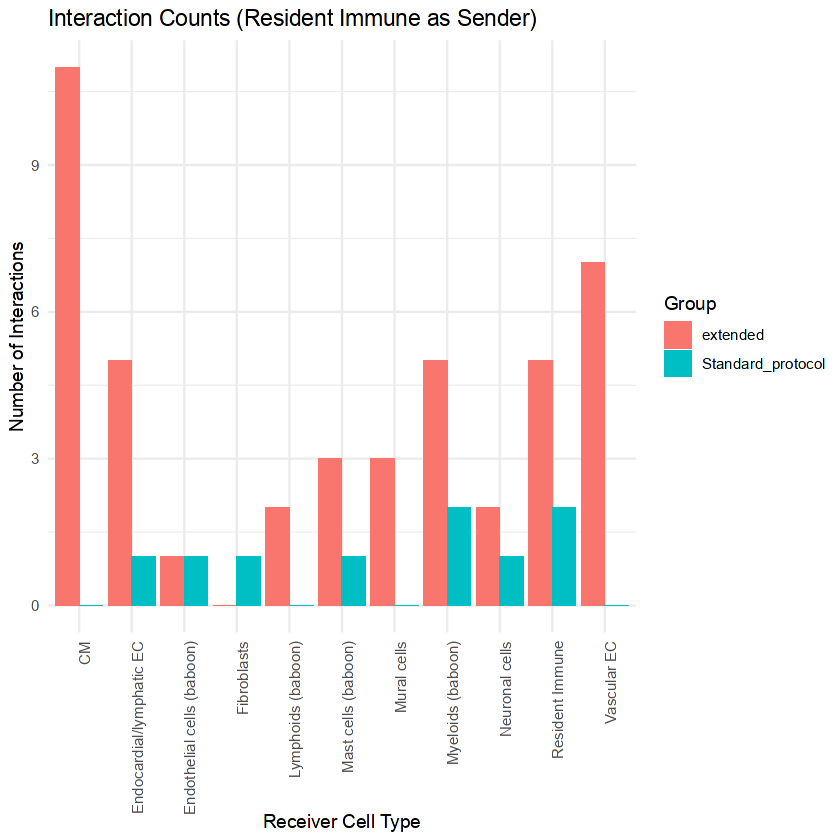

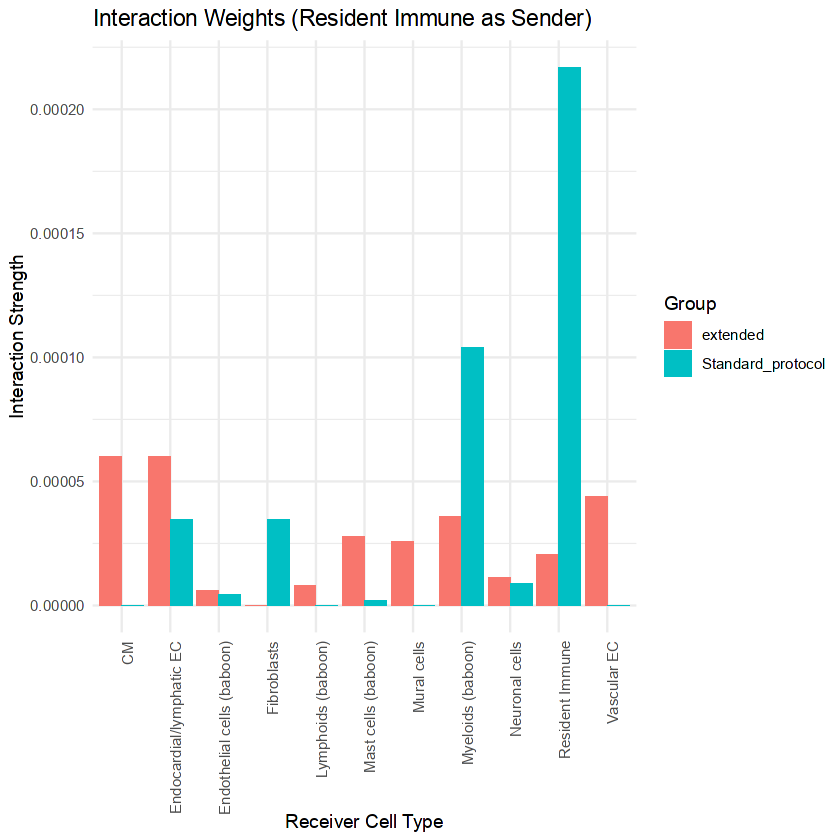

In [22]:
# For extended group
extended_interactions <- cellchat_extended@net$count["Resident Immune", ]
extended_interactions_weight <- cellchat_extended@net$weight["Resident Immune", ]

# For Standard protocol group
standard_interactions <- cellchat_standard@net$count["Resident Immune", ]
standard_interactions_weight <- cellchat_standard@net$weight["Resident Immune", ]

# Differential (Rejection - Standard)
diff_count <- extended_interactions - standard_interactions
diff_weight <- extended_interactions_weight - standard_interactions_weight

# Combine data into a data frame for plotting

count_data <- data.frame(
  Receiver = names(extended_interactions),
  extended = extended_interactions,
  Standard_protocol = standard_interactions
)

# Melt for ggplot
library(reshape2)
count_melted <- melt(count_data, id.vars = "Receiver", variable.name = "Group", value.name = "Count")

# Plot
ggplot(count_melted, aes(x = Receiver, y = Count, fill = Group)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Interaction Counts (Resident Immune as Sender)", x = "Receiver Cell Type", y = "Number of Interactions") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))




# --------------------------------------------------------------------------------------------------------------------------------------------------------------




weight_data <- data.frame(
  Receiver = names(extended_interactions_weight),
  extended = extended_interactions_weight,
  Standard_protocol = standard_interactions_weight
)

weight_melted <- melt(weight_data, id.vars = "Receiver", variable.name = "Group", value.name = "Weight")

# Plot
ggplot(weight_melted, aes(x = Receiver, y = Weight, fill = Group)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Interaction Weights (Resident Immune as Sender)", x = "Receiver Cell Type", y = "Interaction Strength") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
# Identify pathways where Resident Immune is a significant sender
pathways_extended <- cellchat_extended@netP$pathways  # All pathways in Rejection
pathways_standard <- cellchat_standard@netP$pathways     # All pathways in Per-Protocol

# Get communication patterns where Resident Immune is a sender
net_extended <- subsetCommunication(cellchat_extended, sources.use = "Resident Immune")
net_standard <- subsetCommunication(cellchat_standard, sources.use = "Resident Immune")

# Find unique pathways involving Resident Immune
resident_pathways_extended <- unique(net_extended$pathway_name)
resident_pathways_standard <- unique(net_standard$pathway_name)

# Combine pathways from both conditions
all_pathways <- union(resident_pathways_extended, resident_pathways_standard)

# Set larger plot margins
par(mar = c(5, 8, 4, 4))  

In [13]:
# Load necessary libraries
library(CellChat)

# Define the sender cell type of interest
my_sender <- "Resident Immune"

# Get a list of all unique target cell types
target_cells <- unique(c(names(cellchat_extended@net$count[my_sender, ]),
                         names(cellchat_standard@net$count[my_sender, ])))

# Set up the output directory
output_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Specific_Pathways_Sender_Receiver"
if (!dir.exists(output_dir)) dir.create(output_dir, recursive = TRUE)

# Loop through each unique target cell
for (my_target in target_cells) {
  
  # --- Extract and write data for the Extended protocol ---
  # Subset communication data for the specific sender and target
  extended_data <- subsetCommunication(cellchat_extended, sources.use = my_sender, targets.use = my_target)
  
  # Prepare the output filename for the Extended group
  extended_filename <- file.path(output_dir, paste0(
    "Extended_", gsub(" ", "_", my_sender), "_to_", gsub(" ", "_", my_target), "_Pathways.csv"
  ))
  
  # Write the data to a CSV file
  if (!is.null(extended_data) && nrow(extended_data) > 0) {
    write.csv(extended_data, file = extended_filename, row.names = FALSE)
    cat("Successfully wrote data for Extended protocol to:", extended_filename, "\n")
  } else {
    cat("No significant interactions found for Extended protocol from", my_sender, "to", my_target, "\n")
  }
  
  # --- Extract and write data for the Standard protocol ---
  # Subset communication data for the specific sender and target
  standard_data <- subsetCommunication(cellchat_standard, sources.use = my_sender, targets.use = my_target)
  
  # Prepare the output filename for the Standard group
  standard_filename <- file.path(output_dir, paste0(
    "Standard_", gsub(" ", "_", my_sender), "_to_", gsub(" ", "_", my_target), "_Pathways.csv"
  ))
  
  # Write the data to a CSV file
  if (!is.null(standard_data) && nrow(standard_data) > 0) {
    write.csv(standard_data, file = standard_filename, row.names = FALSE)
    cat("Successfully wrote data for Standard protocol to:", standard_filename, "\n")
  } else {
    cat("No significant interactions found for Standard protocol from", my_sender, "to", my_target, "\n")
  }
}

Successfully wrote data for Extended protocol to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Specific_Pathways_Sender_Receiver/Extended_Resident_Immune_to_CM_Pathways.csv 
No significant interactions found for Standard protocol from Resident Immune to CM 


ERROR: Error in file(file, ifelse(append, "a", "w")): cannot open the connection


In [15]:
# Load necessary libraries
library(CellChat)

# Define the sender cell type of interest
my_sender <- "Resident Immune"

# Set up the output directory
output_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Specific_Pathways_Sender_Receiver"
if (!dir.exists(output_dir)) dir.create(output_dir, recursive = TRUE)

# --- Process the Extended protocol group ---
cat("Processing interactions from", my_sender, "for the Extended protocol...\n")
extended_data <- subsetCommunication(cellchat_extended, sources.use = my_sender)

# Sort the data by the target cell type
if (!is.null(extended_data) && nrow(extended_data) > 0) {
  sorted_extended_data <- extended_data[order(extended_data$target), ]
  
  # Prepare the output filename
  extended_filename <- file.path(output_dir, paste0(
    "Extended_", gsub(" ", "_", my_sender), "_to_All_Cells.csv"
  ))
  
  # Write the data to a CSV file
  write.csv(sorted_extended_data, file = extended_filename, row.names = FALSE)
  cat("Successfully wrote data for Extended protocol to:", extended_filename, "\n\n")
} else {
  cat("No significant interactions found for Extended protocol from", my_sender, "to any target cell.\n\n")
}

# --- Process the Standard protocol group ---
cat("Processing interactions from", my_sender, "for the Standard protocol...\n")
standard_data <- subsetCommunication(cellchat_standard, sources.use = my_sender)

# Sort the data by the target cell type
if (!is.null(standard_data) && nrow(standard_data) > 0) {
  sorted_standard_data <- standard_data[order(standard_data$target), ]
  
  # Prepare the output filename
  standard_filename <- file.path(output_dir, paste0(
    "Standard_", gsub(" ", "_", my_sender), "_to_All_Cells.csv"
  ))
  
  # Write the data to a CSV file
  write.csv(sorted_standard_data, file = standard_filename, row.names = FALSE)
  cat("Successfully wrote data for Standard protocol to:", standard_filename, "\n\n")
} else {
  cat("No significant interactions found for Standard protocol from", my_sender, "to any target cell.\n\n")
}

Processing interactions from Resident Immune for the Extended protocol...
Successfully wrote data for Extended protocol to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Specific_Pathways_Sender_Receiver/Extended_Resident_Immune_to_All_Cells.csv 

Processing interactions from Resident Immune for the Standard protocol...
Successfully wrote data for Standard protocol to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Specific_Pathways_Sender_Receiver/Standard_Resident_Immune_to_All_Cells.csv 



Comparing communications on a single object 


Comparing communications on a single object 




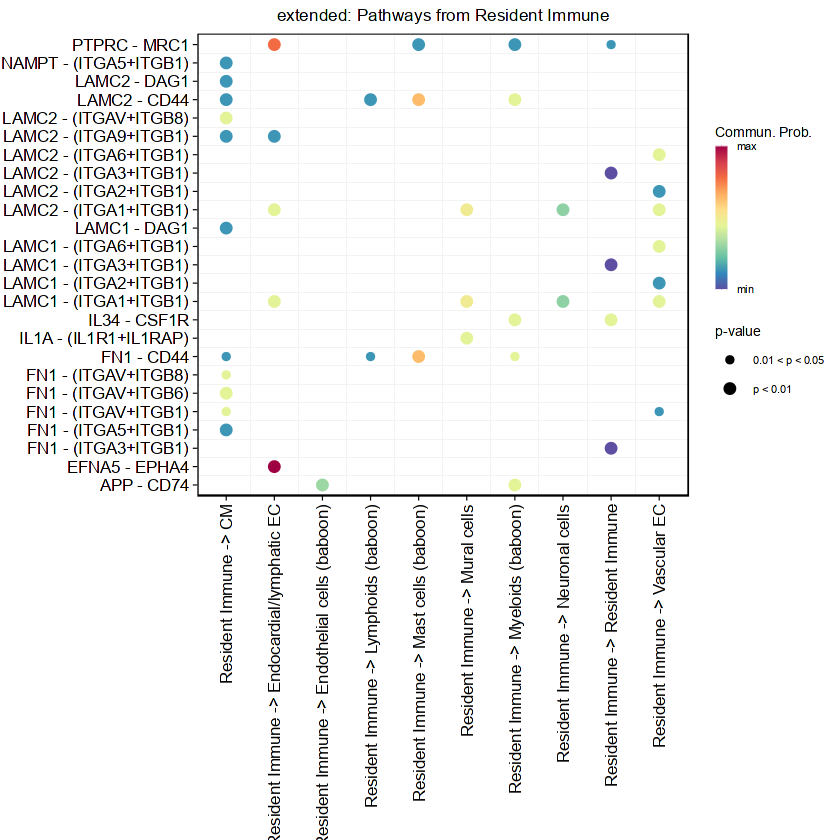

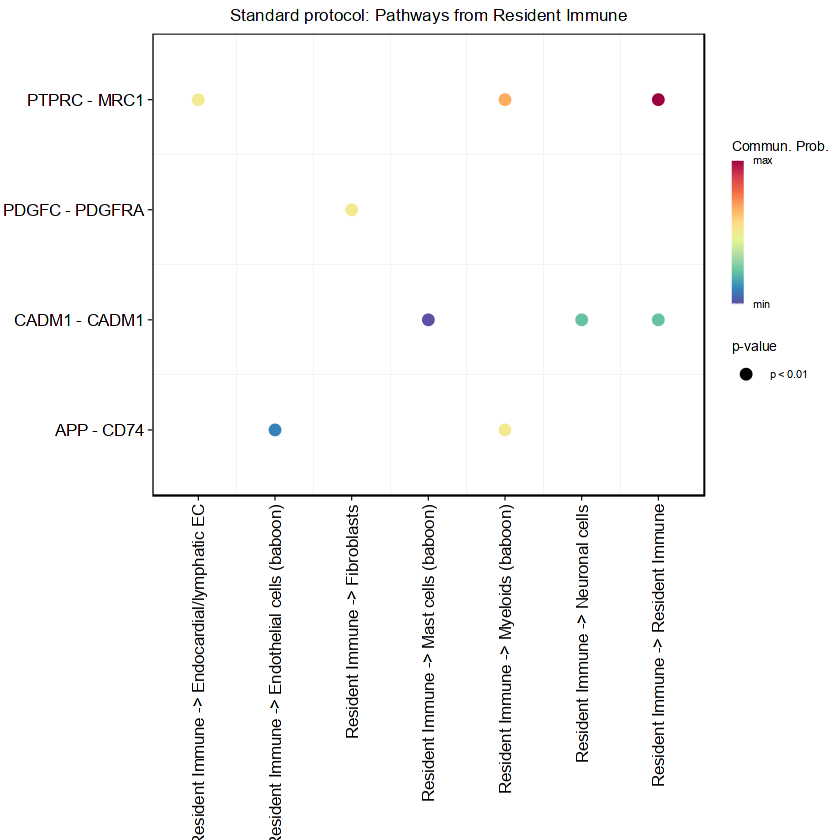

In [15]:
# Rejection group
netVisual_bubble(
  cellchat_extended, 
  sources.use = "Resident Immune", 
  remove.isolate = FALSE,  # Show all pathways, even if weak
  title.name = "extended: Pathways from Resident Immune",
  font.size = 12,
  angle.x = 90
)

# Per-Protocol group
netVisual_bubble(
  cellchat_standard, 
  sources.use = "Resident Immune", 
  remove.isolate = FALSE,
  title.name = "Standard protocol: Pathways from Resident Immune",
  font.size = 12,
  angle.x = 90
)


In [24]:
library(CellChat)

# Output directory
plot_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Bubble_plots"
if (!dir.exists(plot_dir)) dir.create(plot_dir, recursive = TRUE)

# List of all your senders
all_senders <- c(
  'CM','Endocardial/lymphatic EC','Endothelial cells (baboon)','Fibroblasts',
  'Lymphoids (baboon)','Mast cells (baboon)','Mural cells','Myeloids (baboon)',
  'Neuronal cells','Resident Immune','Vascular EC'
)

# Safe filename function (replace slashes and spaces)
safe_filename <- function(x) {
  gsub("[/\\\\ ]", "_", x)
}

for (sender in all_senders) {
  cat("Processing sender:", sender, "\n")
  fname_sender <- safe_filename(sender)
  
  # Rejection
  pdf(file = file.path(plot_dir, paste0("extended_Bubble_", fname_sender, ".pdf")),
      width = 12, height = 10, pointsize = 12)
  print(
    netVisual_bubble(
      cellchat_extended, 
      sources.use = sender, 
      remove.isolate = FALSE,
      title.name = paste("extended: Pathways from", sender),
      font.size = 11,
      angle.x = 90
    )
  )
  dev.off()
  
  # Standard protocol
  pdf(file = file.path(plot_dir, paste0("Standard_Bubble_", fname_sender, ".pdf")),
      width = 12, height = 10, pointsize = 12)
  print(
    netVisual_bubble(
      cellchat_standard, 
      sources.use = sender, 
      remove.isolate = FALSE,
      title.name = paste("Standard protocol: Pathways from", sender),
      font.size = 11,
      angle.x = 90
    )
  )
  dev.off()
}
cat("All bubble plots saved in:\n", plot_dir, "\n")


Processing sender: CM 


Comparing communications on a single object 


Comparing communications on a single object 




Processing sender: Endocardial/lymphatic EC 


Comparing communications on a single object 


Comparing communications on a single object 




Processing sender: Endothelial cells (baboon) 


...

Processing sender: Resident Immune 


Comparing communications on a single object 


Comparing communications on a single object 




Processing sender: Vascular EC 


Comparing communications on a single object 


Comparing communications on a single object 




All bubble plots saved in:
 /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Bubble_plots 


In [36]:
# pick pathways (case-insensitive match to what's in your objects)
want <- c("FN1","LAMININ","COLLAGEN","TGFb")
all_pw <- unique(c(cellchat_standard@netP$pathways, cellchat_extended@netP$pathways))
map_pw <- sapply(want, function(w) {
  hit <- all_pw[match(tolower(w), tolower(all_pw))]
  if (is.na(hit)) w else hit
}, USE.NAMES = FALSE)

# output
out_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots"
if (!dir.exists(out_dir)) dir.create(out_dir, recursive = TRUE)

safe_filename <- function(x) gsub("[/\\\\ ]", "_", x)

for (pw in map_pw) {
  f <- file.path(out_dir, paste0(safe_filename(pw), "_chord_compare.pdf"))
  pdf(f, width = 14, height = 7)
  par(mfrow = c(1,2), mar = c(1,1,2,1))

  ## --- Standard
  if (pw %in% cellchat_standard@netP$pathways) {
    lr.use.std <- extractEnrichedLR(cellchat_standard, signaling = pw, geneLR.return = FALSE)
    netVisual_chord_gene(
      cellchat_standard,
      pairLR.use = lr.use.std,   # <-- keep only this (no 'signaling' arg)
      title.name = paste0(pw, " — Standard protocol"),
      small.gap = 1, big.gap = 5,
      lab.cex = 0.8
    )
  } else { plot.new(); title(paste0(pw," — Standard protocol\n(Not detected)")) }

  ## --- Extended
  if (pw %in% cellchat_extended@netP$pathways) {
    lr.use.ext <- extractEnrichedLR(cellchat_extended, signaling = pw, geneLR.return = FALSE)
    netVisual_chord_gene(
      cellchat_extended,
      pairLR.use = lr.use.ext,   # <-- keep only this (no 'signaling' arg)
      title.name = paste0(pw, " — Extended protocol"),
      small.gap = 1, big.gap = 5,
      lab.cex = 0.8
    )
  } else { plot.new(); title(paste0(pw," — Extended protocol\n(Not detected)")) }

  dev.off()
  cat("Saved:", f, "\n")
}


You may try the function `netVisual_chord_cell` for visualizing individual signaling pathway

You may try the function `netVisual_chord_cell` for visualizing individual signaling pathway



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots/FN1_chord_compare.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots/LAMININ_chord_compare.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots/COLLAGEN_chord_compare.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Chord_plots/TGFb_chord_compare.pdf 


In [47]:
# Select a key sender cell type, for example, "Resident Immune"
sender_cell_type <- "CM"

# Create a PDF file to save the figure
pdf(file = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Bubble_plot_comparison.pdf",
    width = 15, height = 10, pointsize = 12)
par(mfrow = c(1, 2)) # Arrange plots side by side

# Plot for the Standard protocol
netVisual_bubble(
  cellchat_standard,
  sources.use = sender_cell_type,
  remove.isolate = FALSE,
  title.name = paste("Standard protocol: Pathways from", sender_cell_type),
  font.size = 12,
  angle.x = 90
)

# Plot for the Extended protocol
netVisual_bubble(
  cellchat_extended,
  sources.use = sender_cell_type,
  remove.isolate = FALSE,
  title.name = paste("Extended protocol: Pathways from", sender_cell_type),
  font.size = 12,
  angle.x = 90
)

dev.off()

Comparing communications on a single object 


Comparing communications on a single object 




png 
  2

###COLLAGEN

In [27]:
library(networkD3)

# Pathways of interest
fibrosis_pathways <- c("TGFb", "COLLAGEN", "LAMININ", "PDGF", "FN1")

# Read data
df_std <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv", stringsAsFactors = FALSE)
df_extended <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/cellchat_Extended_CCC_info_table.csv", stringsAsFactors = FALSE)
# Standard Protocol
fibro_std <- df_std %>%
  filter(source == "Fibroblasts", pathway_name %in% fibrosis_pathways) %>%
  mutate(prob = as.numeric(prob))

# Rejection
fibro_extended <- df_extended%>%
  filter(source == "Fibroblasts", pathway_name %in% fibrosis_pathways) %>%
  mutate(prob = as.numeric(prob))
plot_fibro_sankey <- function(df, title = "Sankey") {
  df <- df %>% filter(prob > 0)
  if (nrow(df) == 0) {
    warning("No interactions for this condition!")
    return(NULL)
  }
  df <- df %>%
    group_by(pathway_name, target) %>%
    summarise(value = sum(-log10(prob)), .groups = "drop")
  
  nodes <- data.frame(name = c("Fibroblasts", unique(df$pathway_name), unique(df$target)))
  links1 <- data.frame(
    source = match("Fibroblasts", nodes$name) - 1,
    target = match(df$pathway_name, nodes$name) - 1,
    value = sapply(df$pathway_name, function(x) sum(df$value[df$pathway_name == x])) # sum for each pathway
  )
  links1 <- links1[!duplicated(links1[,c("source","target")]),]  # remove duplicates
  
  links2 <- data.frame(
    source = match(df$pathway_name, nodes$name) - 1,
    target = match(df$target, nodes$name) - 1,
    value = df$value
  )
  links <- rbind(links1, links2)
  
  sankeyNetwork(Links = links, Nodes = nodes,
                Source = "source", Target = "target",
                Value = "value", NodeID = "name",
                fontSize = 13, nodeWidth = 30,
                sinksRight = FALSE)
}

      # Standard Protocol
plot_fibro_sankey(fibro_std, title = "Fibroblasts → Fibrosis Pathways (Standard Protocol)")

# Rejection
plot_fibro_sankey(fibro_extended, title = "Fibroblasts → Fibrosis Pathways (Extended protocol)")


HTML widgets cannot be represented in plain text (need html)

HTML widgets cannot be represented in plain text (need html)

PDF saved at: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Bubble_for_LR_pairs/GHRELIN_Extended_GHRELIN_LR.pdf 


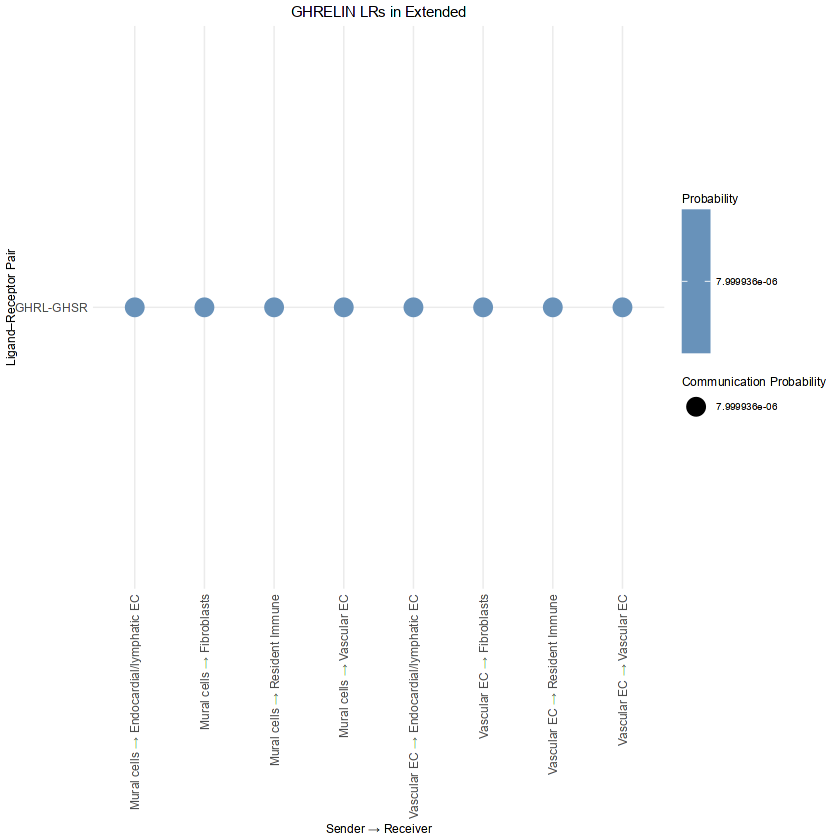

In [29]:
library(dplyr)
library(ggplot2)

# --- Define the Pathway of Interest ---
PATHWAY_OF_INTEREST_VEGF <- "GHRELIN"

# --- 1. Prepare data for VEGF signaling in the Extended protocol ---
vefg_extended_data <- df_extended %>%
  filter(pathway_name == PATHWAY_OF_INTEREST_VEGF) %>%
  # Optionally, arrange by probability to highlight stronger interactions
  arrange(desc(prob))

# Check if there's any data for VEGF in the extended protocol
if (nrow(vefg_extended_data) == 0) {
  stop(paste("No VEGF signaling data found for the Extended Protocol. Please check pathway_name:", PATHWAY_OF_INTEREST_VEGF))
}

# --- 2. Create the Bubble Plot for VEGF signaling in Extended Protocol ---

p_vefg_extended <- ggplot(vefg_extended_data, aes(
  x = paste(source, "→", target), # Sender -> Receiver on X-axis
  y = paste(ligand, receptor, sep = "-"), # Ligand-Receptor Pair on Y-axis
  size = prob, # Bubble size based on communication probability
  color = prob # Color based on communication probability
)) +
  geom_point() +
  scale_color_gradient(low = "lightblue", high = "#08528f", name = "Probability") + # Blue gradient for probability
  labs(
    title = paste0("GHRELIN LRs in Extended"),
    x = "Sender → Receiver",
    y = "Ligand–Receptor Pair",
    size = "Communication Probability"
  ) +
  theme_minimal(base_size = 7) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 7),
    axis.text.y = element_text(size = 7),
    plot.title = element_text(hjust = 0.5)
  )

# --- 3. Save and Print the Plot ---

file_path_vefg <- paste0(
  "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Bubble_for_LR_pairs/",
  PATHWAY_OF_INTEREST_VEGF, "_Extended_GHRELIN_LR.pdf"
)

ggsave(
  filename = file_path_vefg,
  plot = p_vefg_extended,
  device = "pdf",
  width = 4.5, # Adjusted width to accommodate potentially more labels
  height = 4.5, # Adjusted height
  units = "in",
  dpi = 300,
  useDingbats = FALSE
)

print(p_vefg_extended)
cat(paste("PDF saved at:", file_path_vefg, "\n"))

Bubble plot from CSV data saved.


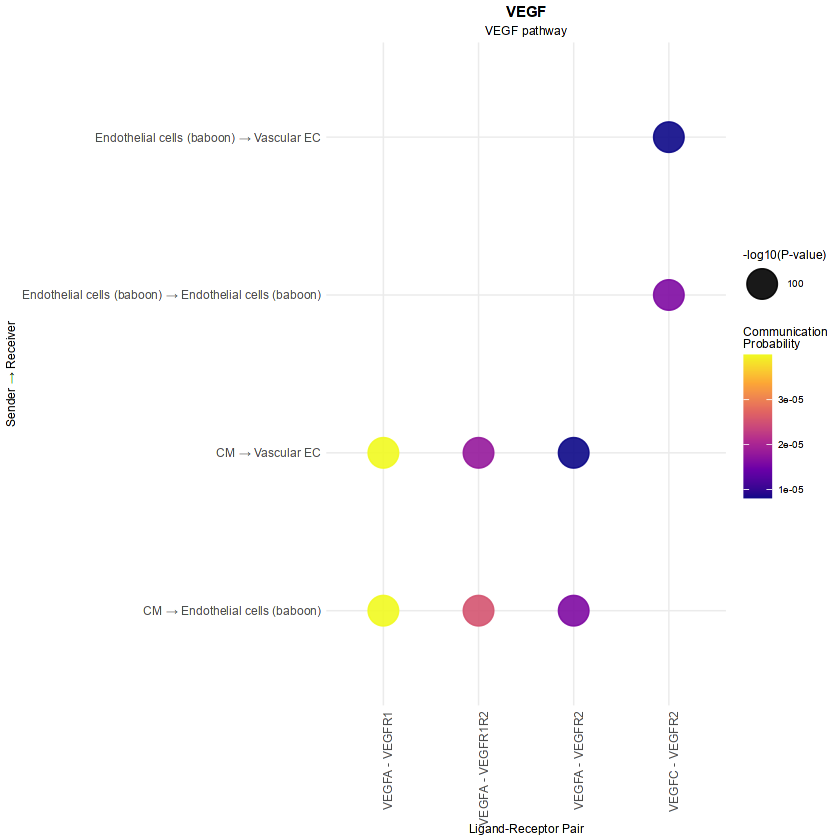

In [39]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(scales)
library(viridis) # Ensure viridis is loaded for scale_color_viridis_c

# Load the data from your CSV file
df_ext <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/csv_results/cellchat_Extended_CCC_info_table.csv")

# Filter for the NOTCH pathway and specific sender cells
plot_data <- df_ext %>%
  filter(
    pathway_name == "VEGF",
    # source == "Vascular EC" 
      # | source == "Endocardial/lymphatic EC"
  ) %>%
  # Ensure pval and prob are numeric
  mutate(pval = as.numeric(as.character(pval)),
         prob = as.numeric(as.character(prob))) %>%
  # Handle pval = 0 by setting it to a very small number to avoid -Inf
  mutate(pval = ifelse(pval == 0, 1e-100, pval)) %>%
  # Create a combined source-target label for the y-axis
  mutate(source_target = paste(source, "→", target)) %>%
  # Use interaction_name_2 for cleaner ligand-receptor pair labels
  mutate(lr_pair = interaction_name_2) %>%
  # Convert to factors to ensure correct plotting
  mutate(source_target = as.factor(source_target),
         lr_pair = as.factor(lr_pair))

# Create the bubble plot
p_bubble <- ggplot(plot_data, aes(
  x = lr_pair,
  y = source_target,
  size = -log10(pval), # Bubble size based on significance
  color = prob # Color based on communication probability
)) +
  geom_point(alpha = 0.9) +
  scale_size_continuous(range = c(3, 10), name = "-log10(P-value)") +
  scale_color_viridis_c(option = "plasma", name = "Communication\nProbability") +
  labs(
    title = "VEGF",
    subtitle = "VEGF pathway",
    x = "Ligand-Receptor Pair",
    y = "Sender → Receiver"
  ) +
  theme_minimal(base_size = 7) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 1, size = 7),
    axis.text.y = element_text(size = 7),
    legend.position = "right",
    plot.title = element_text(face = "bold", hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5)
  )

# Print and save the plot
print(p_bubble)
ggsave(
  filename = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Bubble_for_LR_pairs/VEGF_bubble_plot_extended.pdf",
  plot = p_bubble,
  width = 5,
  height = 5,
  dpi = 300,
  useDingbats = FALSE
)
cat("Bubble plot from CSV data saved.\n")

Sender Bar plot saved at: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Typical cellchat stuff/Fibroblasts_SENDER_Pathway_Counts_Comparison.pdf 


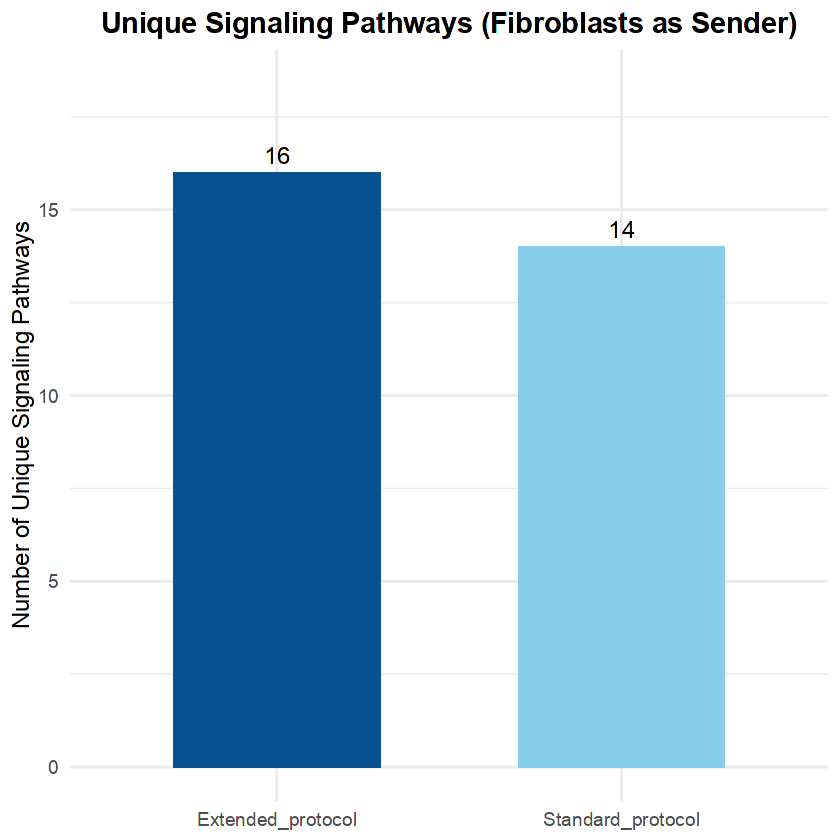

Receiver Bar plot saved at: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Typical cellchat stuff/Fibroblasts_RECEIVER_Pathway_Counts_Comparison.pdf 


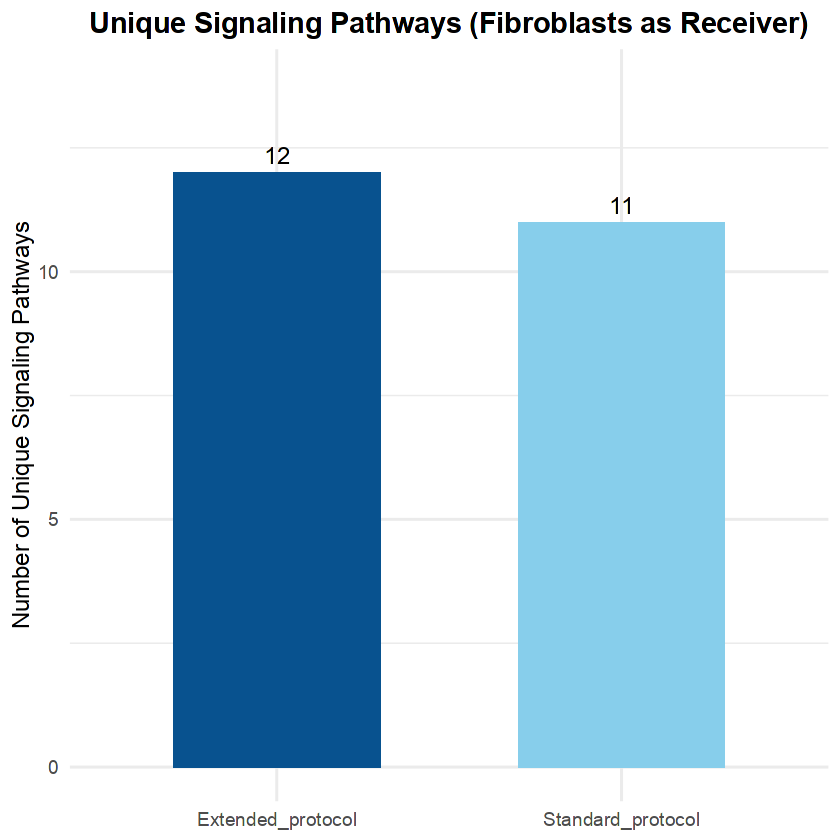

In [26]:
library(dplyr)
library(ggplot2)

# Define the cell type of interest
CELL_TYPE <- "Fibroblasts"

# Define colors for consistency
PROTOCOL_COLORS <- c("Standard_protocol" = "skyblue", "Extended_protocol" = "#08528f")

# --- 1. Prepare and Tally Pathway Counts for Sender and Receiver Roles ---

# Function to filter data and count unique pathways
count_pathways_by_role <- function(df, protocol_name, role = c("sender", "receiver")) {
  role <- match.arg(role)
  
  if (role == "sender") {
    df_filtered <- df %>% filter(source == CELL_TYPE)
  } else { # role == "receiver"
    df_filtered <- df %>% filter(target == CELL_TYPE)
  }
  
  df_filtered %>%
    # Count distinct pathway names
    distinct(pathway_name) %>%
    # Summarize the count
    summarise(
      Count = n(),
      Protocol = protocol_name
    )
}

# --- Calculate Sender Counts (Fibroblasts -> ALL) ---
sender_extended <- count_pathways_by_role(df_extended, "Extended_protocol", "sender")
sender_standard <- count_pathways_by_role(df_standard, "Standard_protocol", "sender")
sender_comparison_data <- bind_rows(sender_standard, sender_extended)

# --- Calculate Receiver Counts (ALL -> Fibroblasts) ---
receiver_extended <- count_pathways_by_role(df_extended, "Extended_protocol", "receiver")
receiver_standard <- count_pathways_by_role(df_standard, "Standard_protocol", "receiver")
receiver_comparison_data <- bind_rows(receiver_standard, receiver_extended)

# --- 2. Plotting Function ---

generate_barplot <- function(data, role = c("Sender", "Receiver")) {
  role <- match.arg(role)
  
  plot_title <- paste0("Unique Signaling Pathways (Fibroblasts as ", role, ")")
  
  p <- ggplot(data, aes(
    x = Protocol,
    y = Count,
    fill = Protocol
  )) +
    geom_bar(stat = "identity", width = 0.6) +
    # Add the count value on top of each bar
    geom_text(aes(label = Count), vjust = -0.5, size = 5) +
    scale_fill_manual(values = PROTOCOL_COLORS) +
    labs(
      title = plot_title,
      x = NULL,
      y = "Number of Unique Signaling Pathways",
      fill = "Protocol"
    ) +
    # Set y-axis limits to accommodate the text on top
    scale_y_continuous(limits = c(0, max(data$Count) * 1.15)) +
    theme_minimal(base_size = 14) +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold"),
      legend.position = "none" # Legend not needed
    )
  
  return(p)
}

# --- 3. Generate and Save Plots ---

# 3a. Sender Plot (Fibroblasts -> ALL)
p_sender <- generate_barplot(sender_comparison_data, "Sender")
file_path_sender <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Typical cellchat stuff/Fibroblasts_SENDER_Pathway_Counts_Comparison.pdf"

ggsave(
  filename = file_path_sender,
  plot = p_sender,
  device = "pdf",
  width = 6,
  height = 7,
  units = "in",
  dpi = 300
)
print(p_sender)
cat(paste("Sender Bar plot saved at:", file_path_sender, "\n"))

# 3b. Receiver Plot (ALL -> Fibroblasts)
p_receiver <- generate_barplot(receiver_comparison_data, "Receiver")
file_path_receiver <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/Typical cellchat stuff/Fibroblasts_RECEIVER_Pathway_Counts_Comparison.pdf"

ggsave(
  filename = file_path_receiver,
  plot = p_receiver,
  device = "pdf",
  width = 6,
  height = 7,
  units = "in",
  dpi = 300
)
print(p_receiver)
cat(paste("Receiver Bar plot saved at:", file_path_receiver, "\n"))

--------------------------------------------------

--- Processing sender: CM ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/CM/CM_diff_sig_table.csv 


Skipping VEGF: no interaction in one of the groups

Skipping VISFATIN: no interaction in one of the groups

Skipping HSPG: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



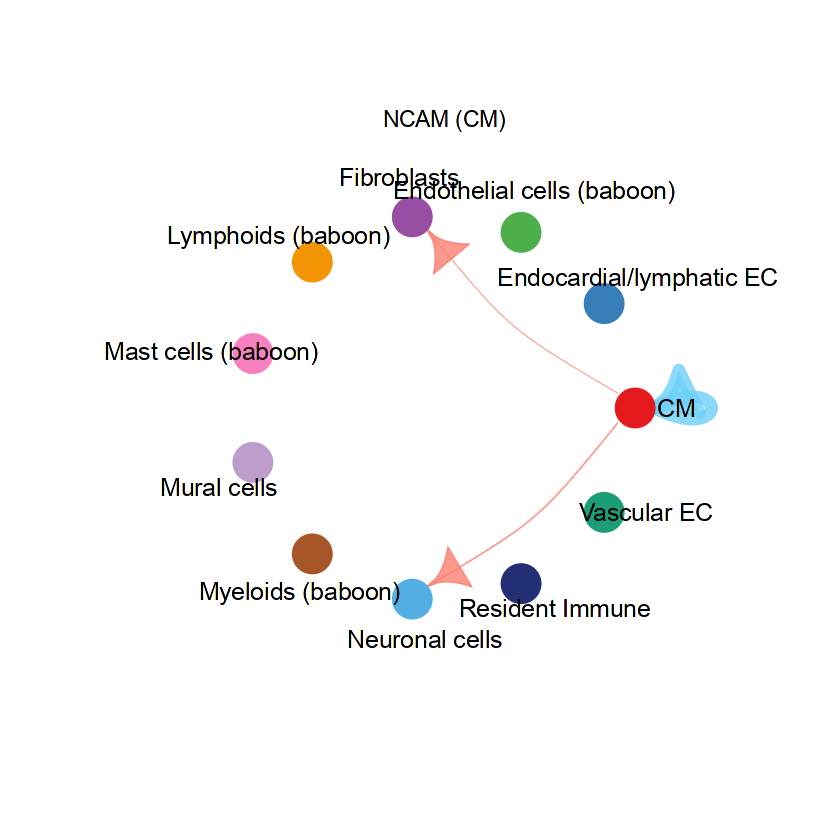

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



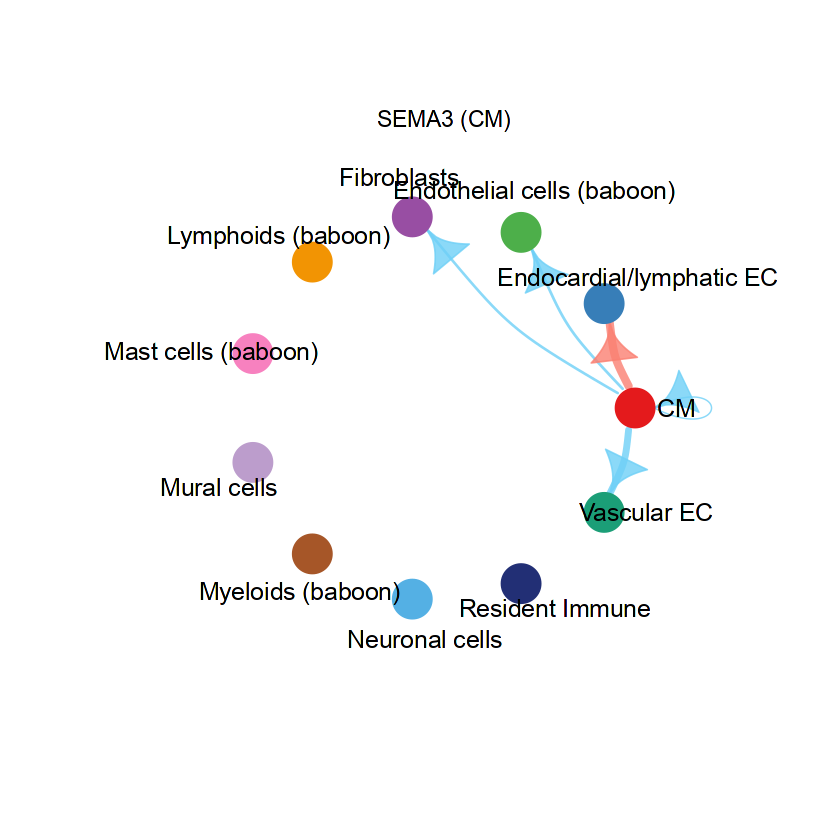

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



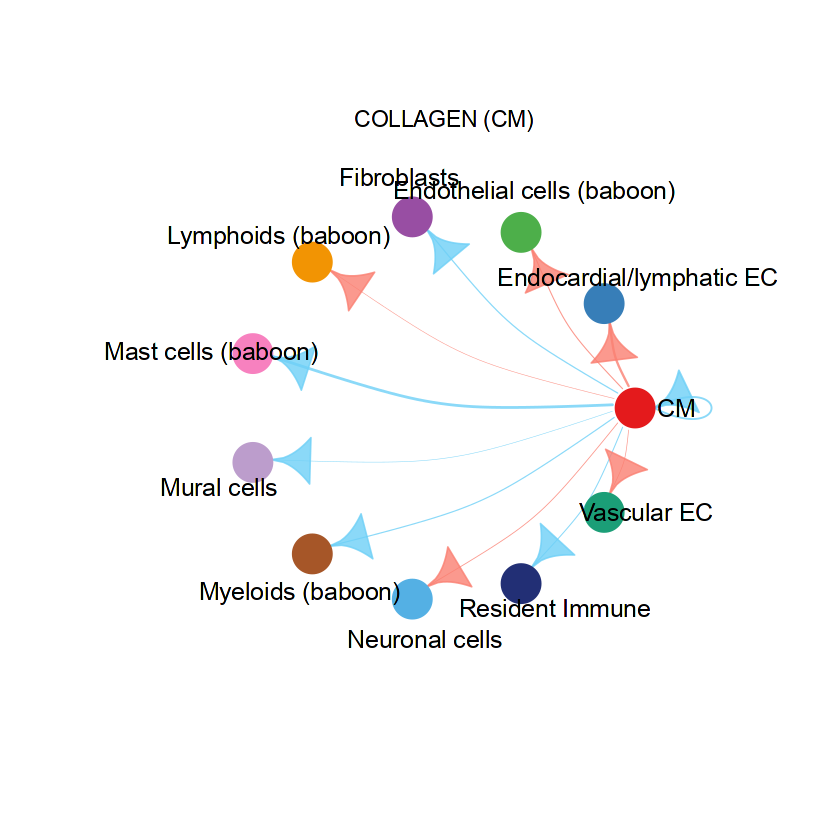

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



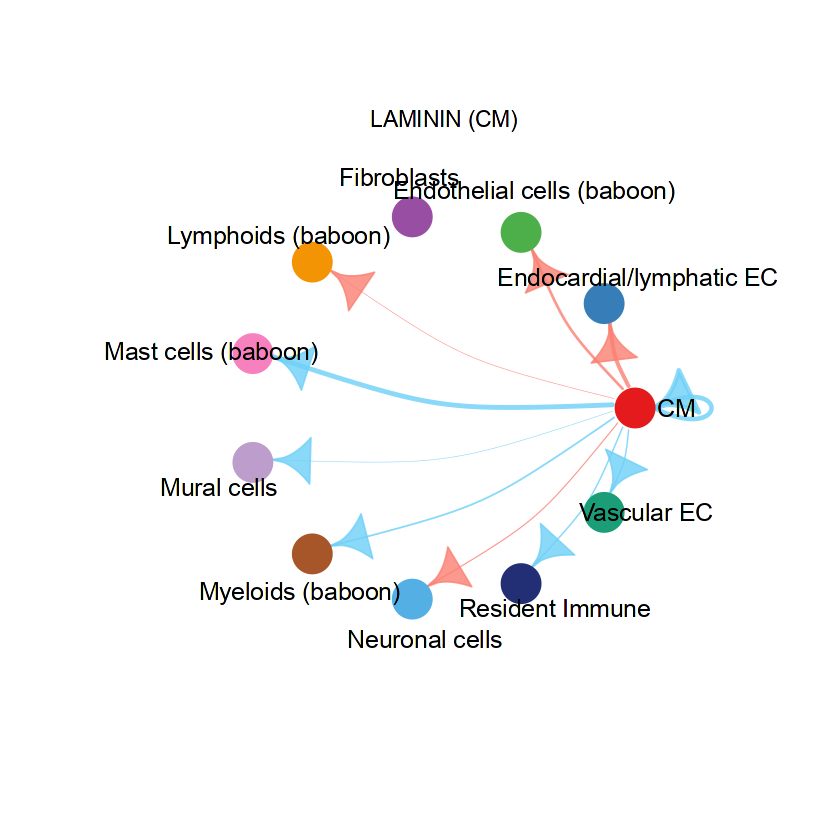

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



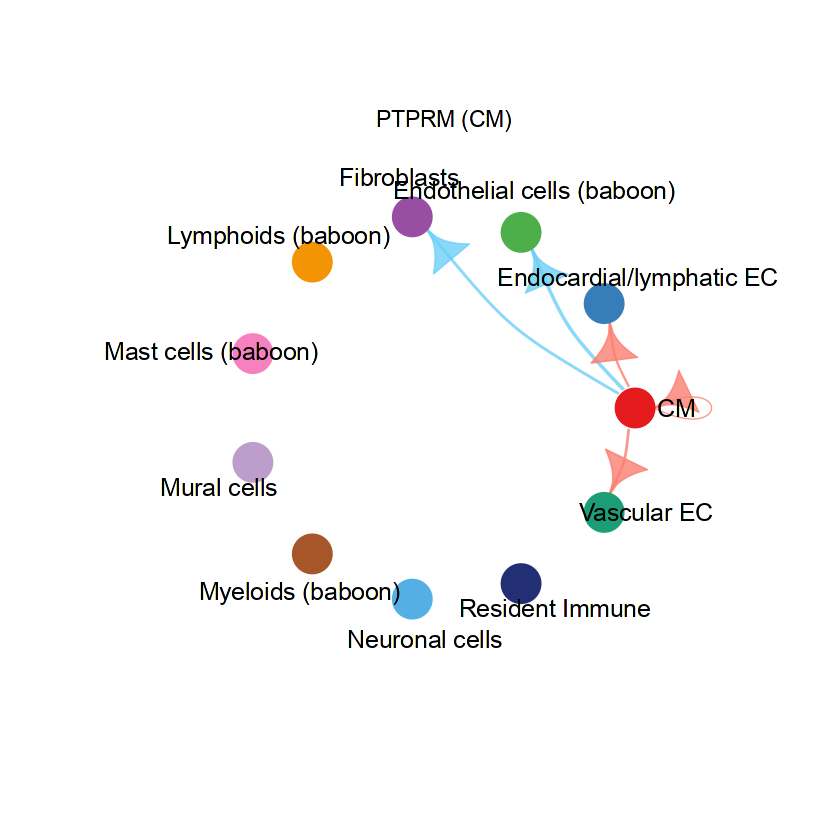

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



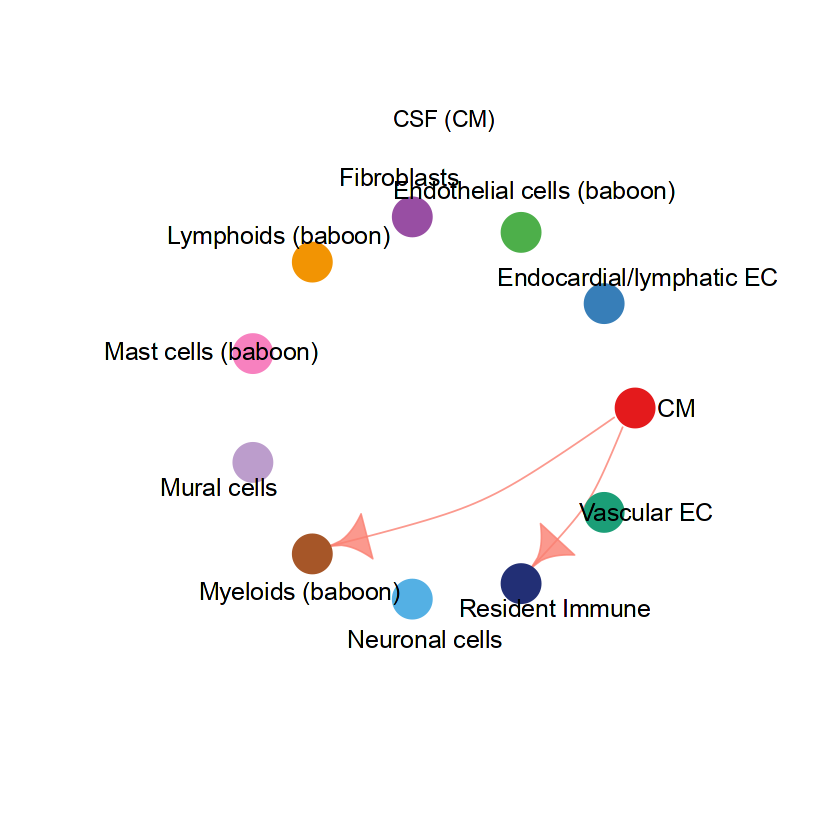

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



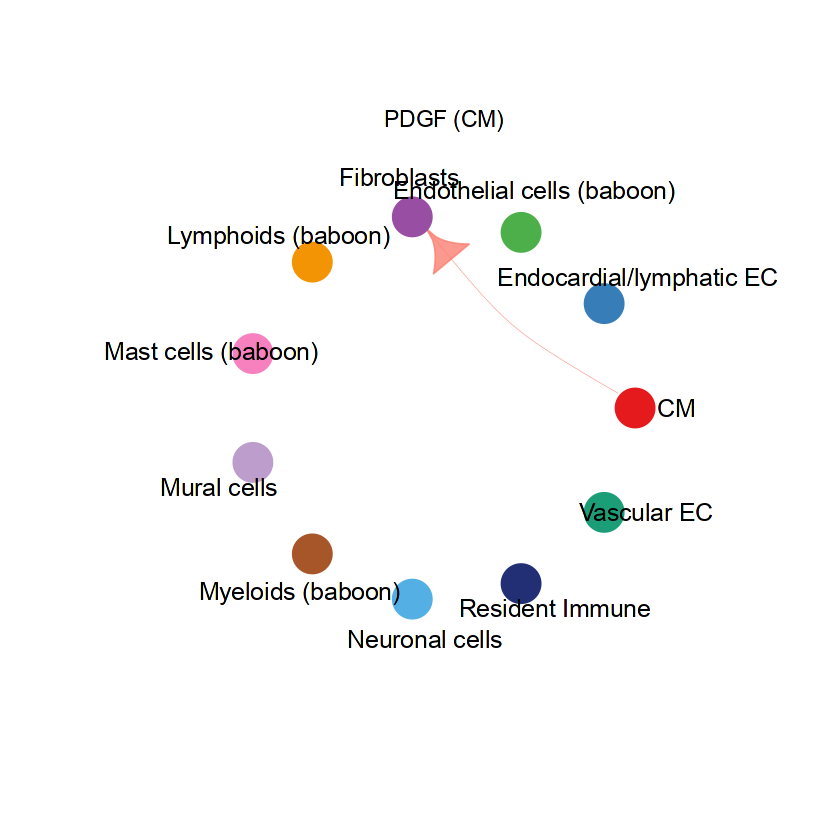

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



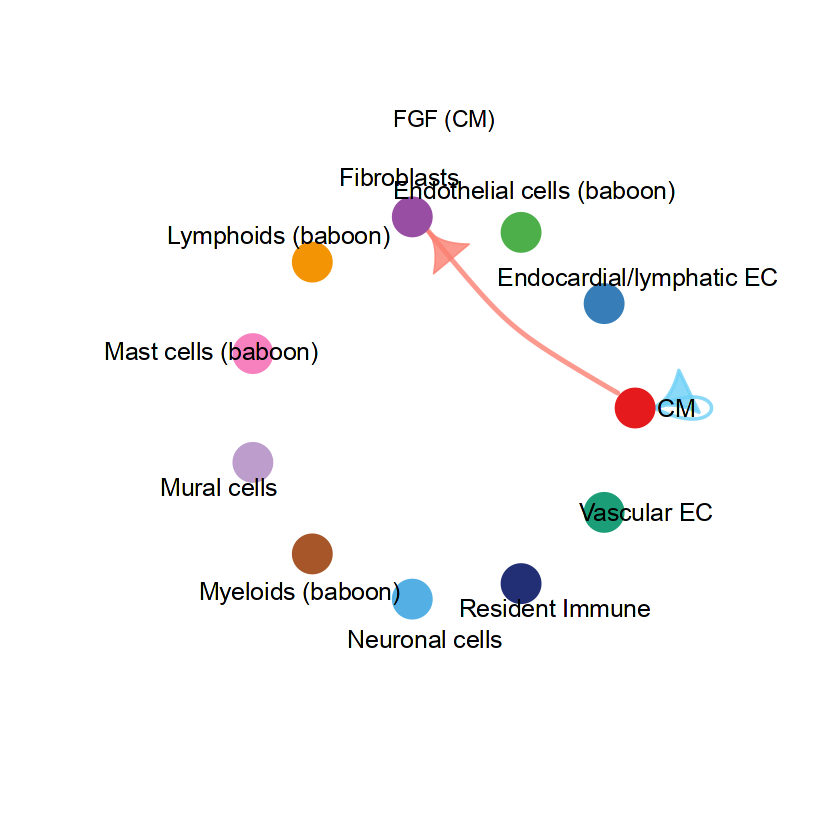

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



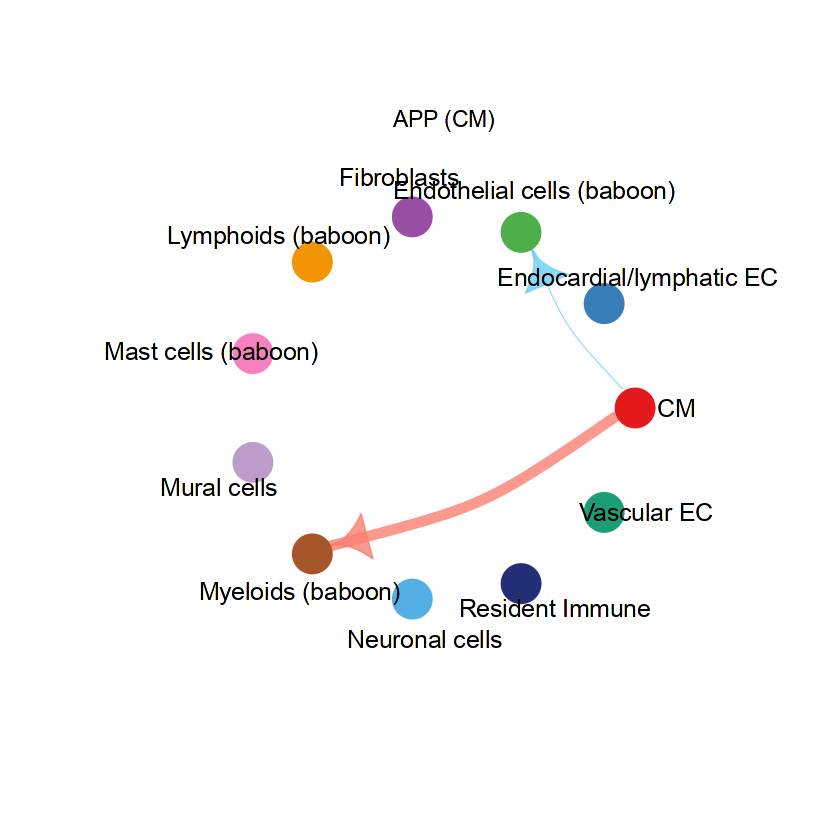

All pathway-specific differential circle plots for CM are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/CM 
--- Processing sender: Endocardial/lymphatic EC ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Endocardial_lymphatic_EC/Endocardial_lymphatic_EC_diff_sig_table.csv 


Skipping RELN: no interaction in one of the groups

Skipping HSPG: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



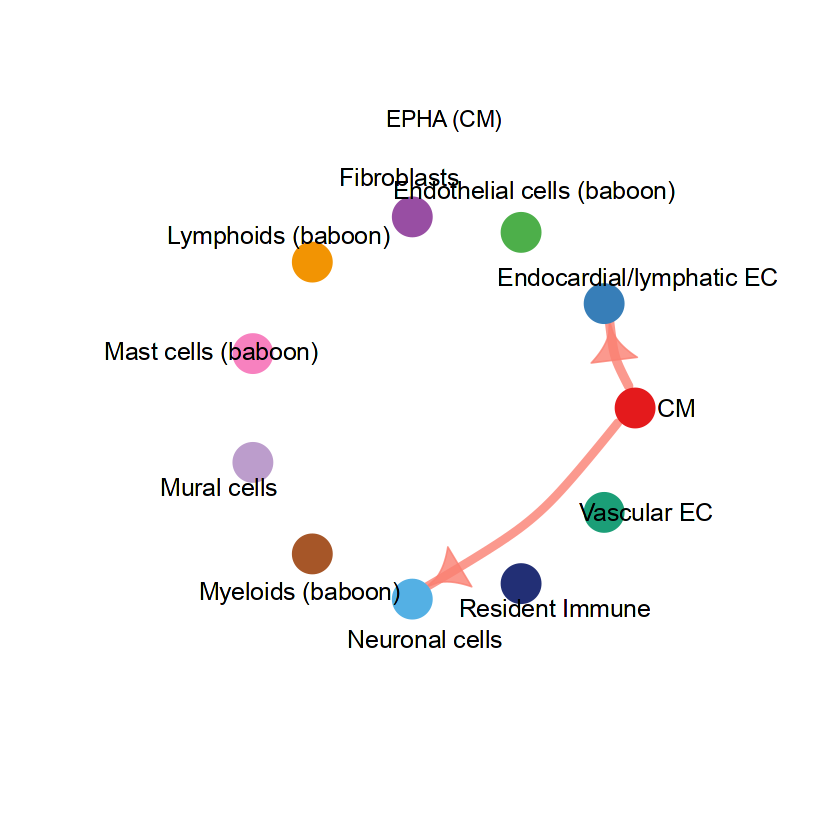

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



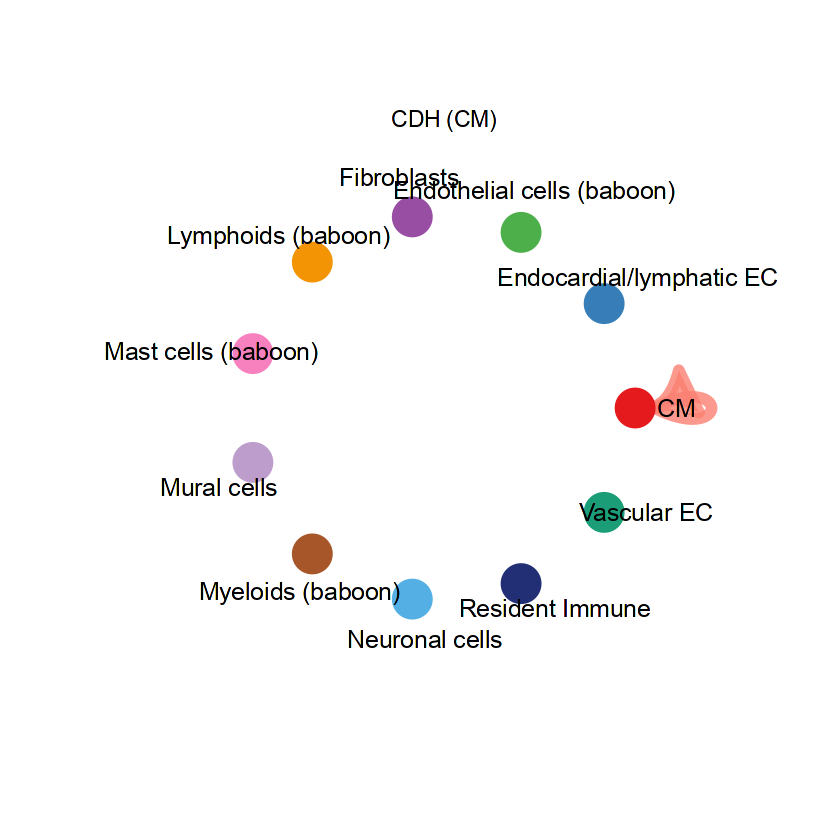

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping SEMA6: plotting failed - Length of new attribute value must be 1 or 5, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping ANGPT: plotting failed - Length of new attribute value must be 1 or 4, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping PTPRM: plotting failed - Length of new attribute value must be 1 or 5, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



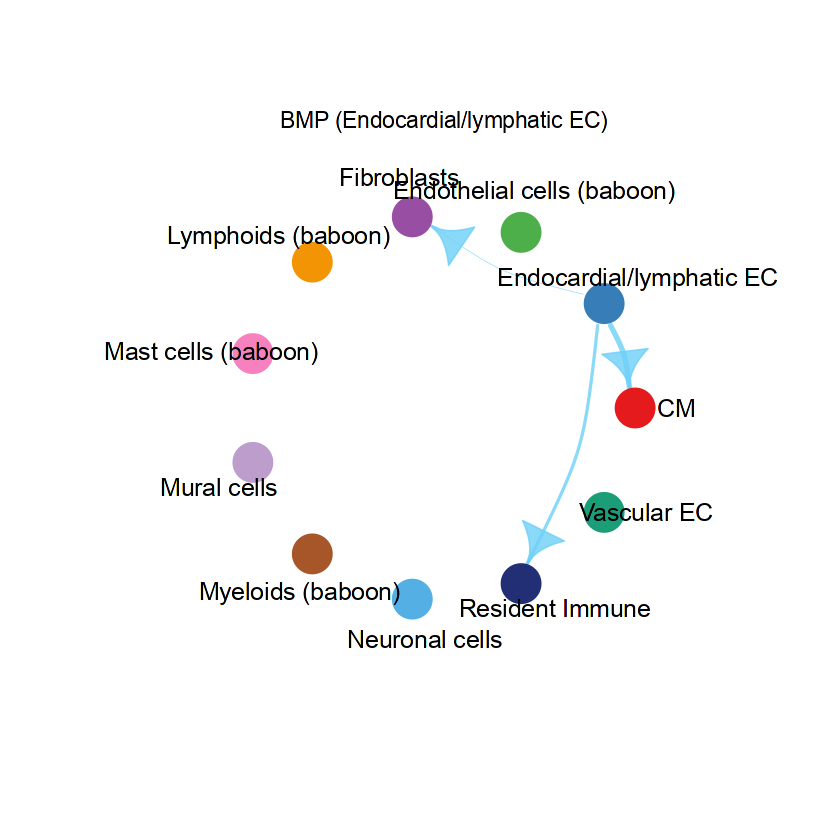

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



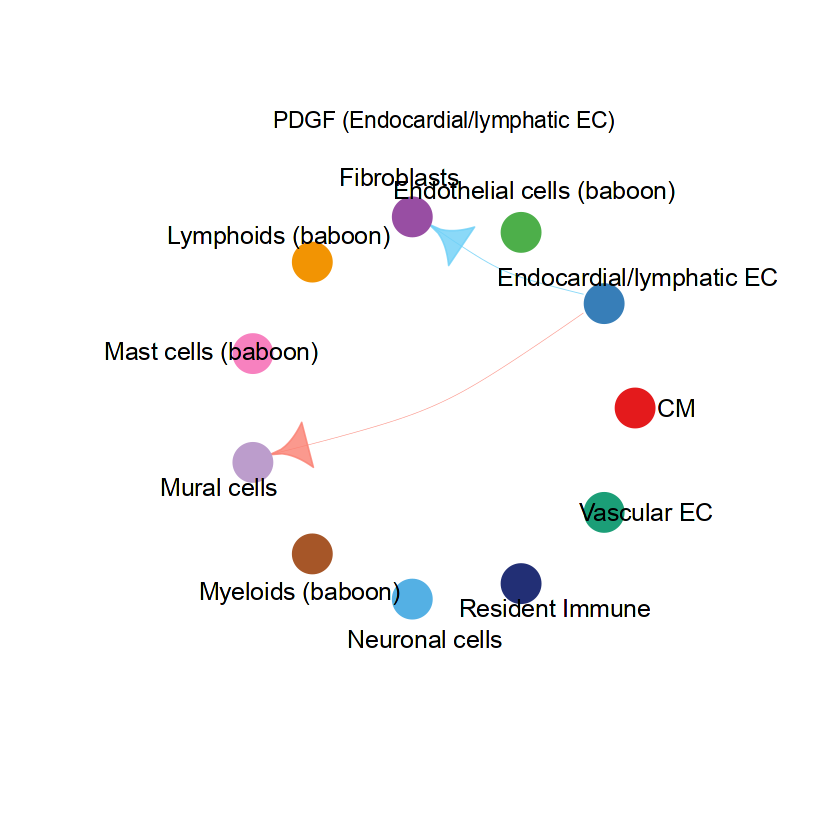

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping LAMININ: plotting failed - Length of new attribute value must be 1 or 10, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



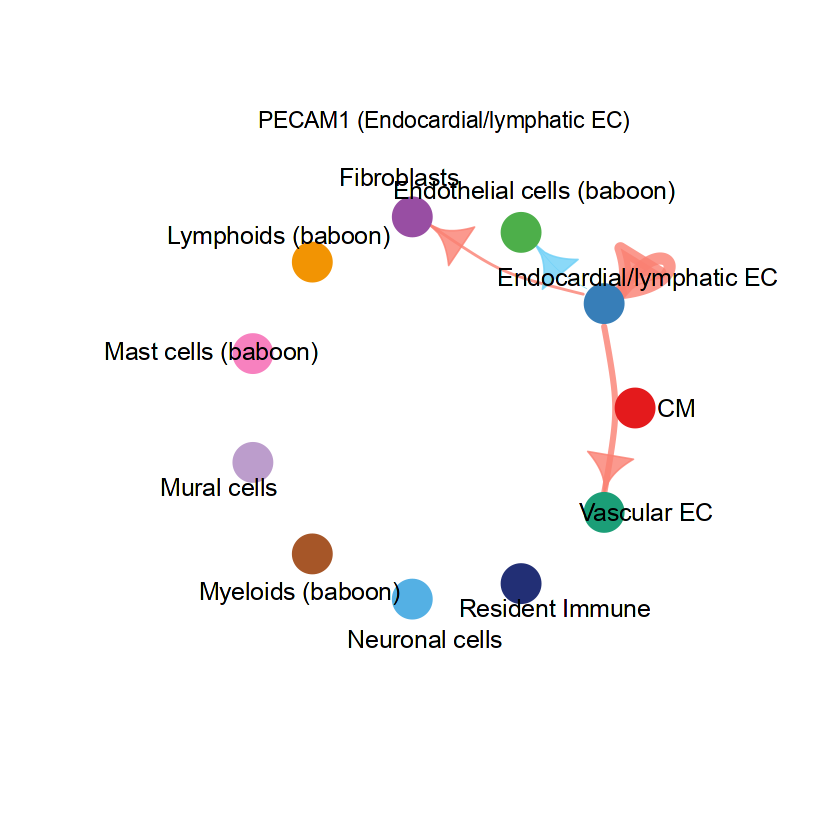

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping COLLAGEN: plotting failed - Length of new attribute value must be 1 or 10, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping SEMA3: plotting failed - Length of new attribute value must be 1 or 5, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



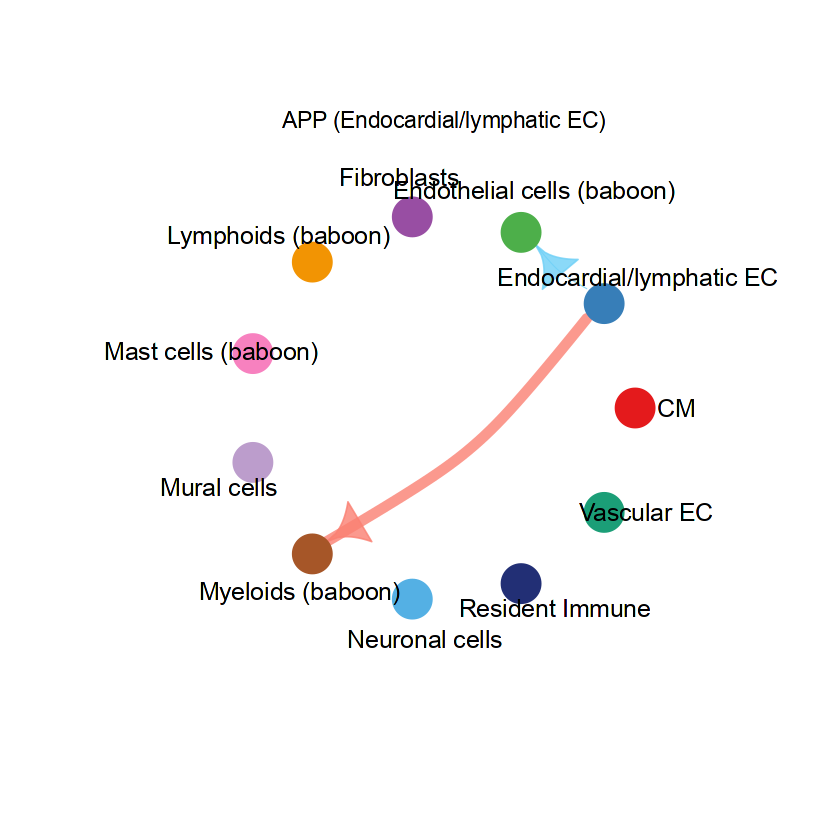

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping TENASCIN: plotting failed - Length of new attribute value must be 1 or 4, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping IGF: plotting failed - Length of new attribute value must be 1 or 7, the number of target edges, not 2



All pathway-specific differential circle plots for Endocardial/lymphatic EC are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Endocardial_lymphatic_EC 
--- Processing sender: Endothelial cells (baboon) ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Endothelial_cells_(baboon)/Endothelial_cells_(baboon)_diff_sig_table.csv 


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



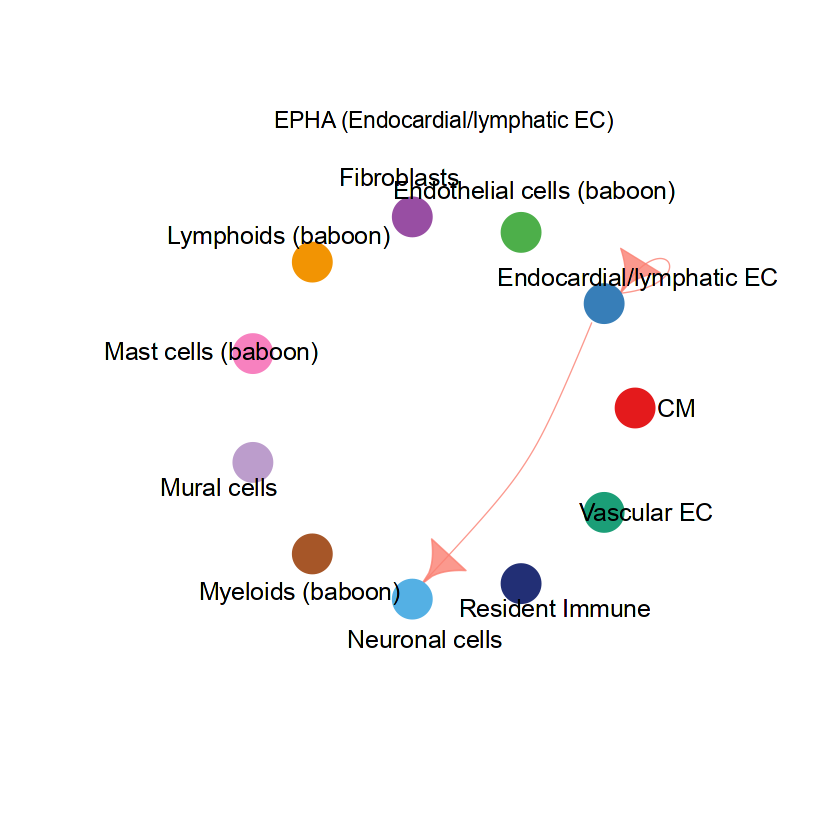

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



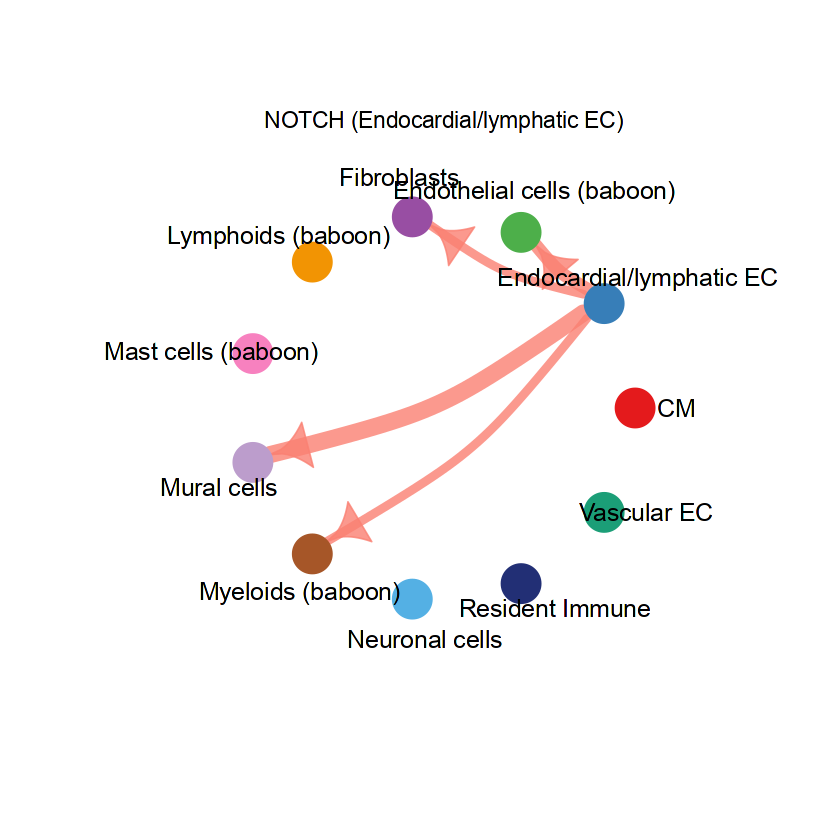

Skipping HSPG: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



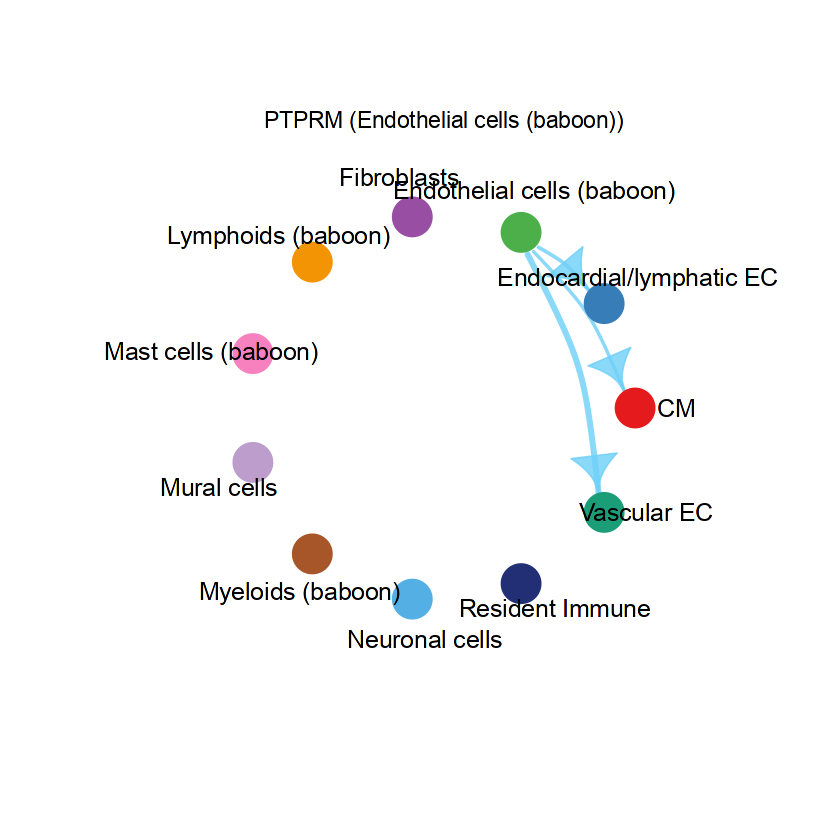

Skipping VEGF: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



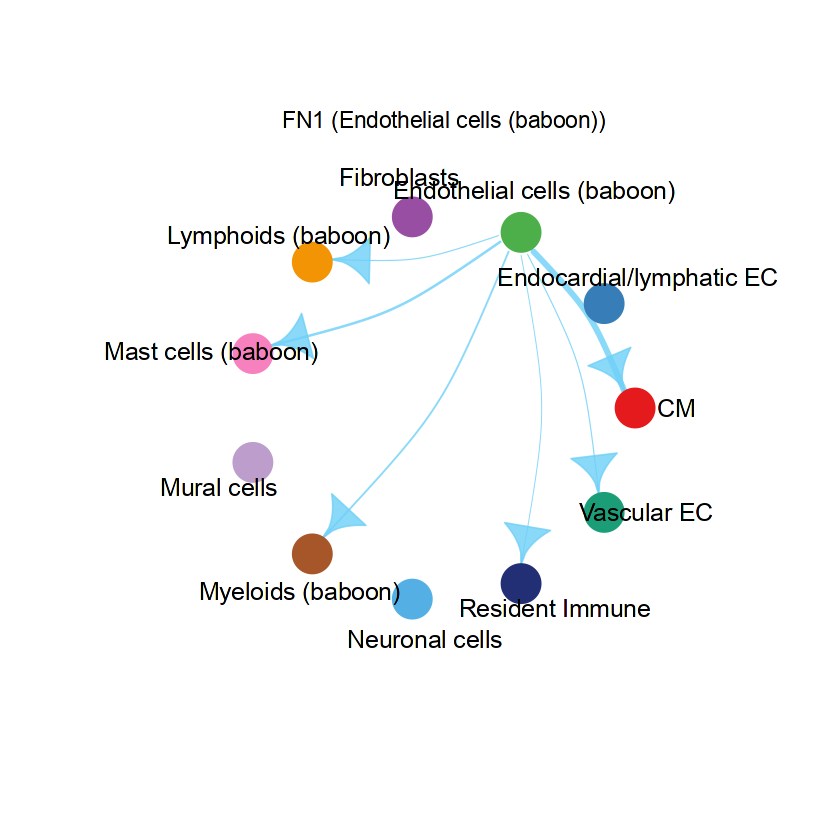

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping LAMININ: plotting failed - Length of new attribute value must be 1 or 10, the number of target edges, not 3

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping COLLAGEN: plotting failed - Length of new attribute value must be 1 or 11, the number of target edges, not 3

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping PECAM1: plotting failed - Length of new attribute value must be 1 or 4, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



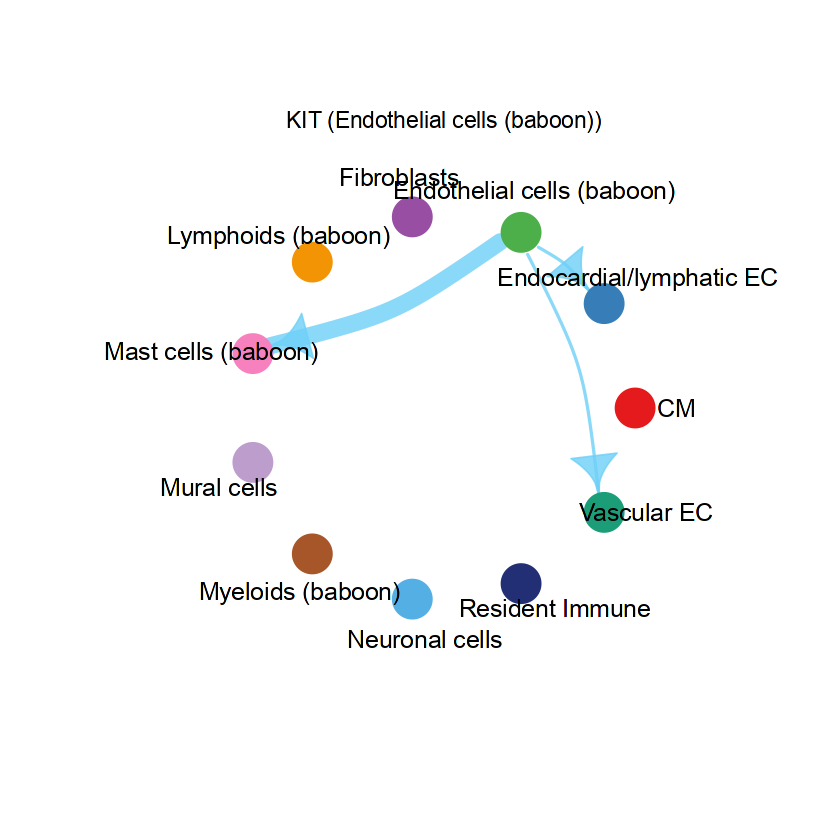

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



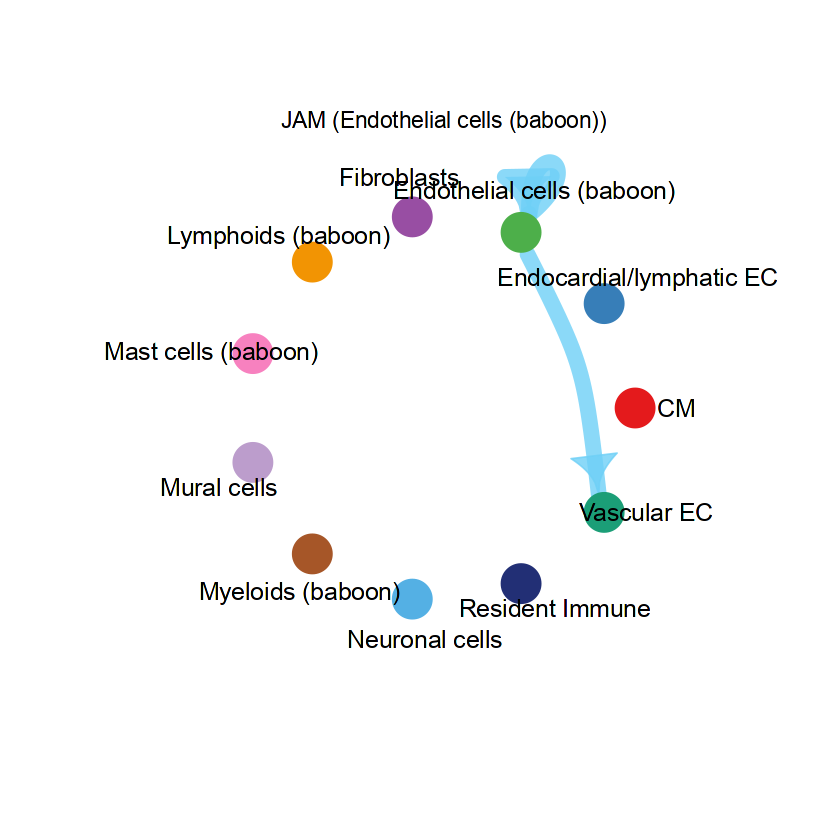

Skipping CD99: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



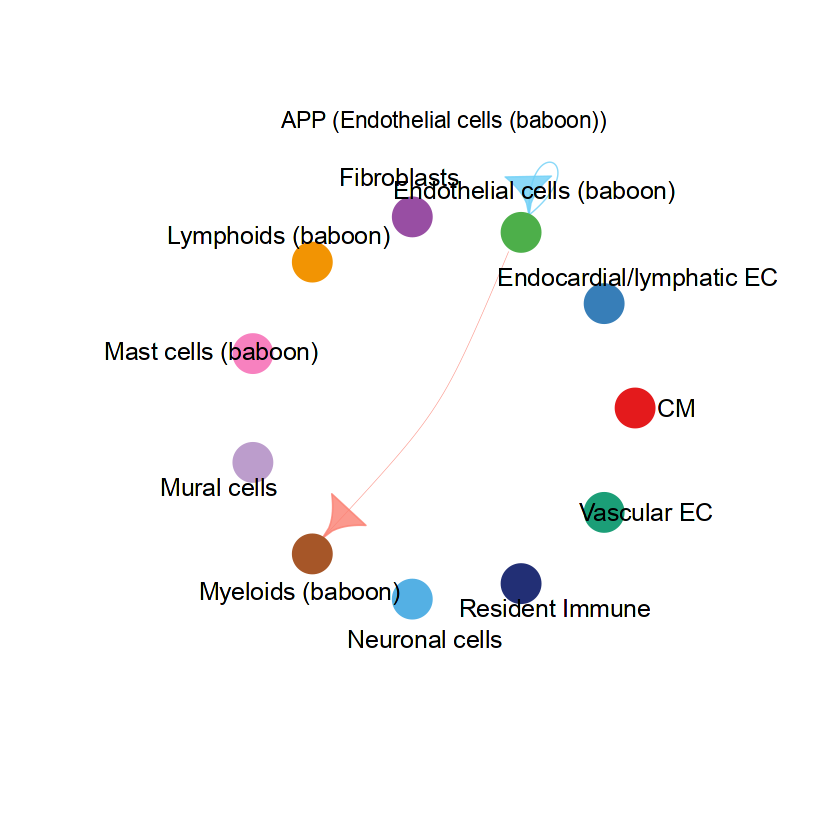

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



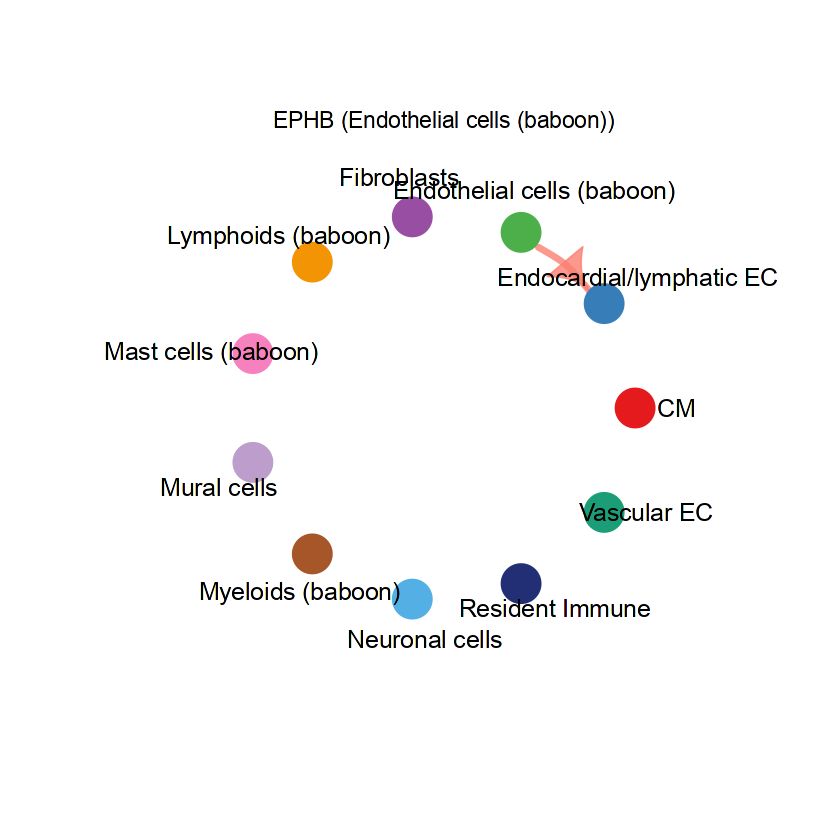

All pathway-specific differential circle plots for Endothelial cells (baboon) are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Endothelial_cells_(baboon) 
--- Processing sender: Fibroblasts ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Fibroblasts/Fibroblasts_diff_sig_table.csv 


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



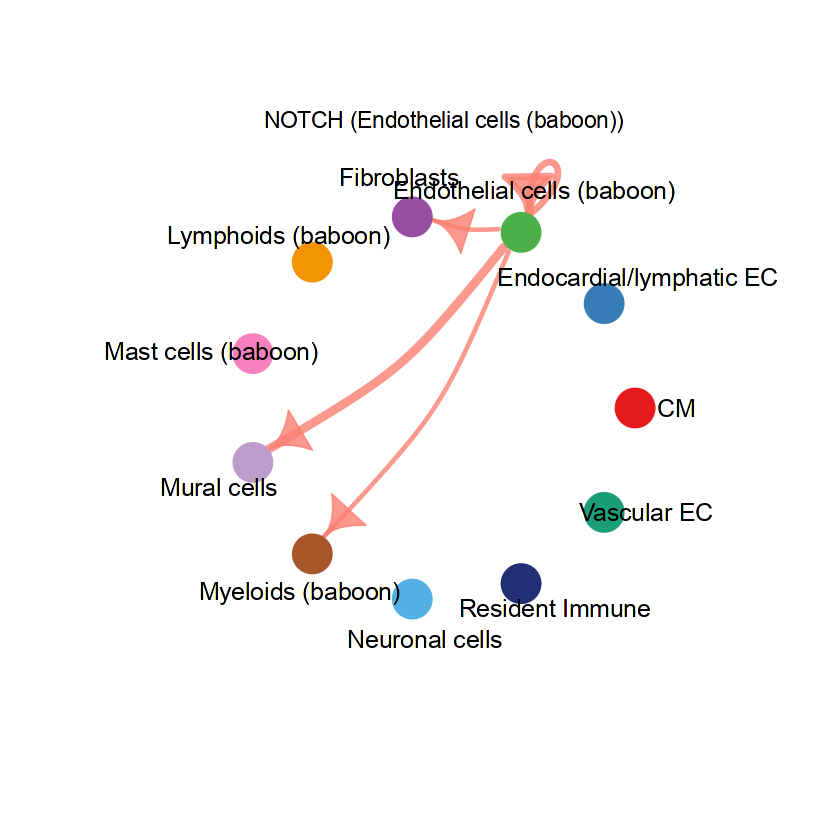

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



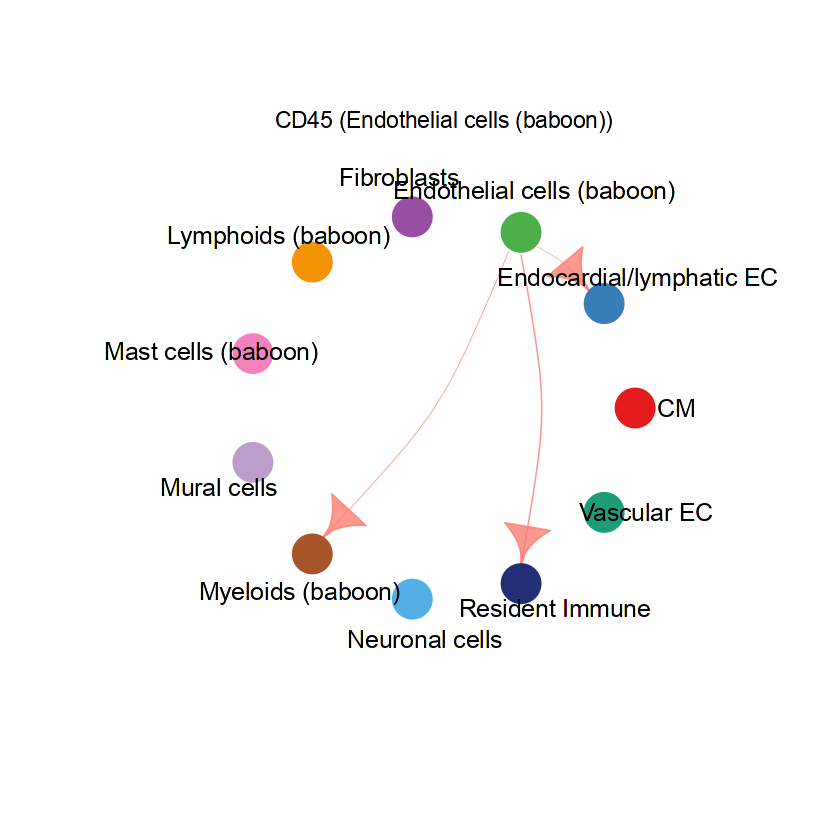

Skipping HSPG: no interaction in one of the groups

Skipping CCL: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



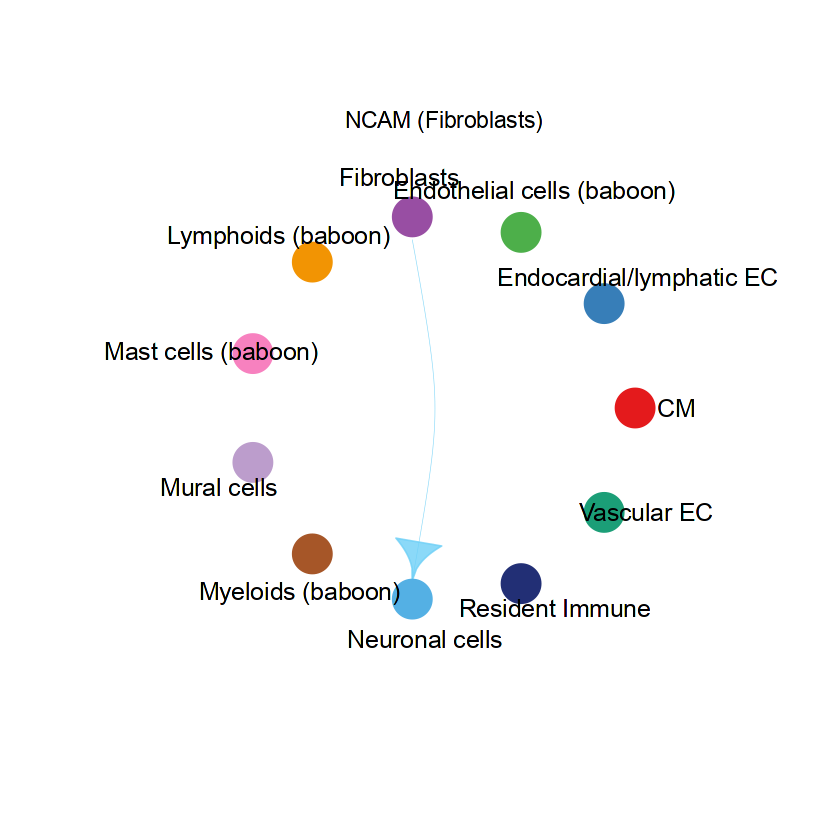

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



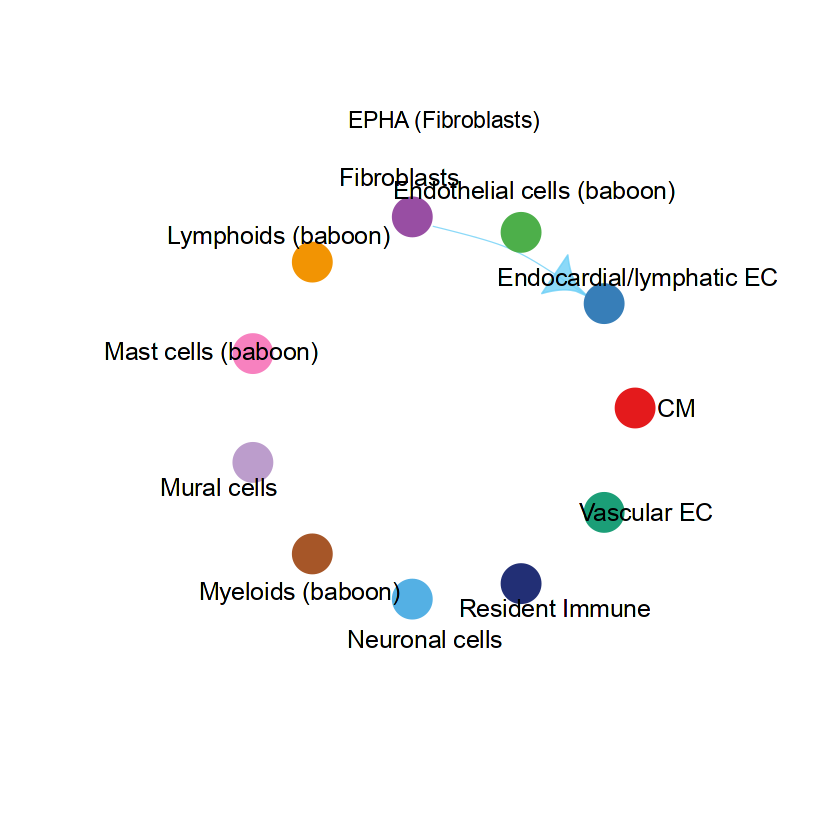

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping PTPRM: plotting failed - Length of new attribute value must be 1 or 4, the number of target edges, not 3

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping BMP: plotting failed - Length of new attribute value must be 1 or 3, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



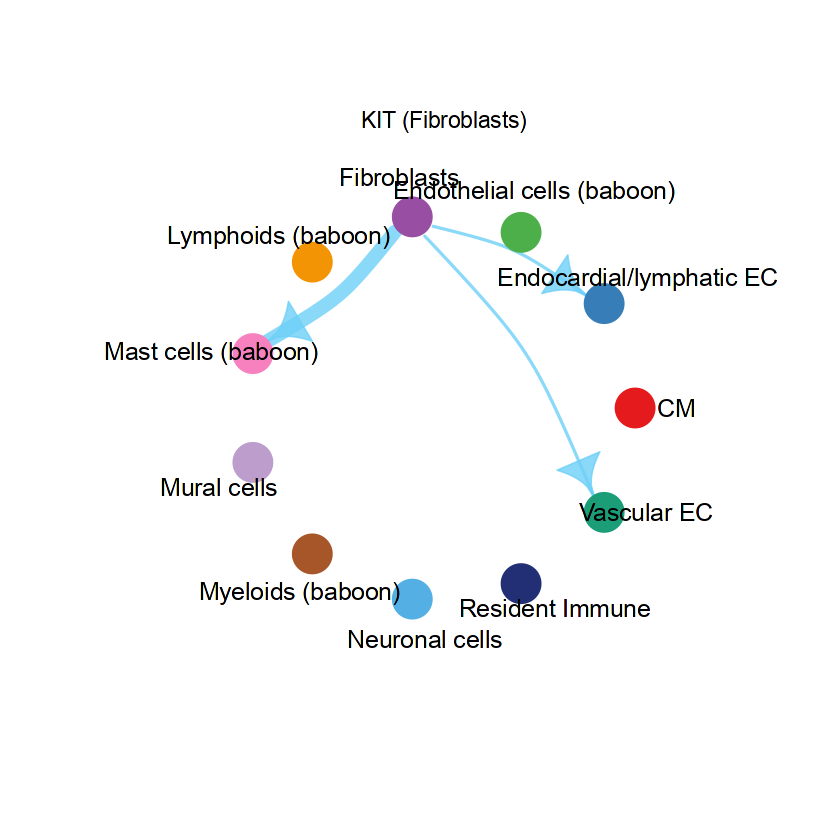

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping COLLAGEN: plotting failed - Length of new attribute value must be 1 or 11, the number of target edges, not 4

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



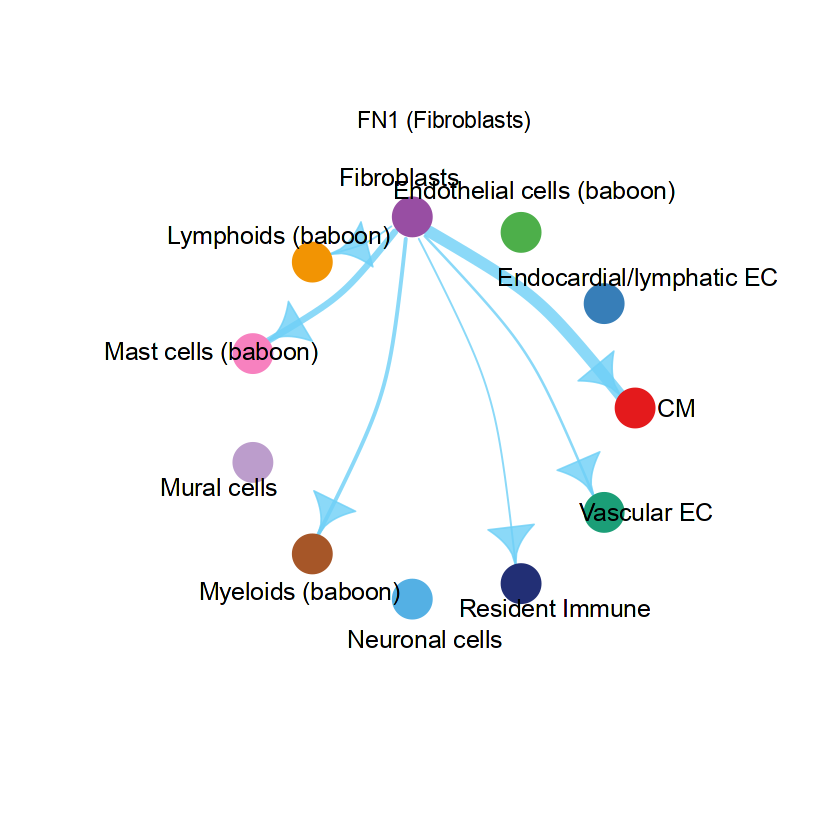

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping IGF: plotting failed - Length of new attribute value must be 1 or 7, the number of target edges, not 3

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



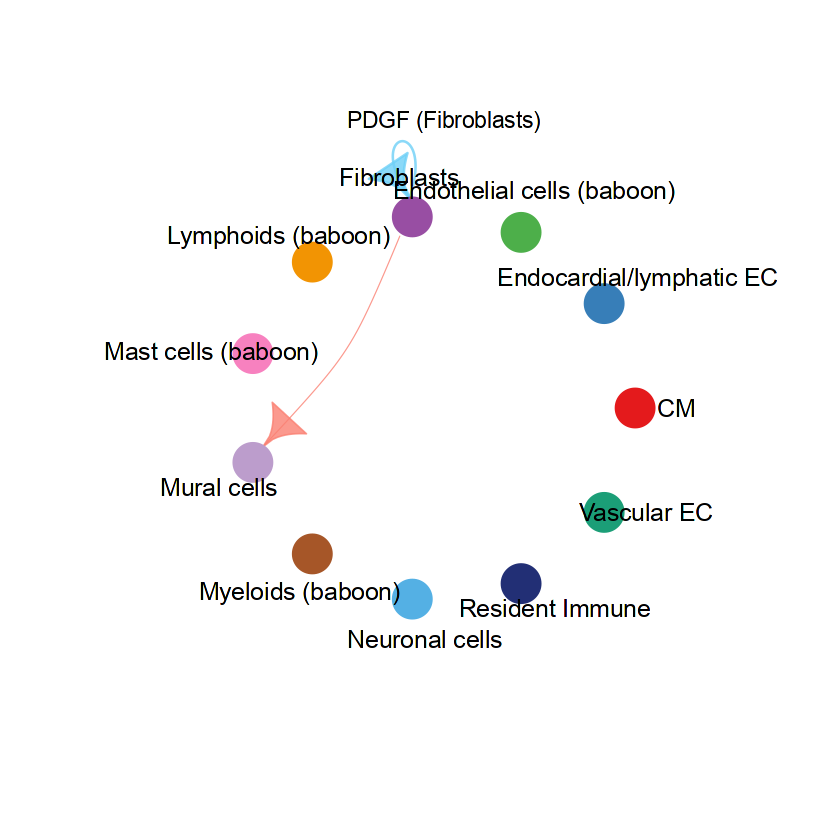

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



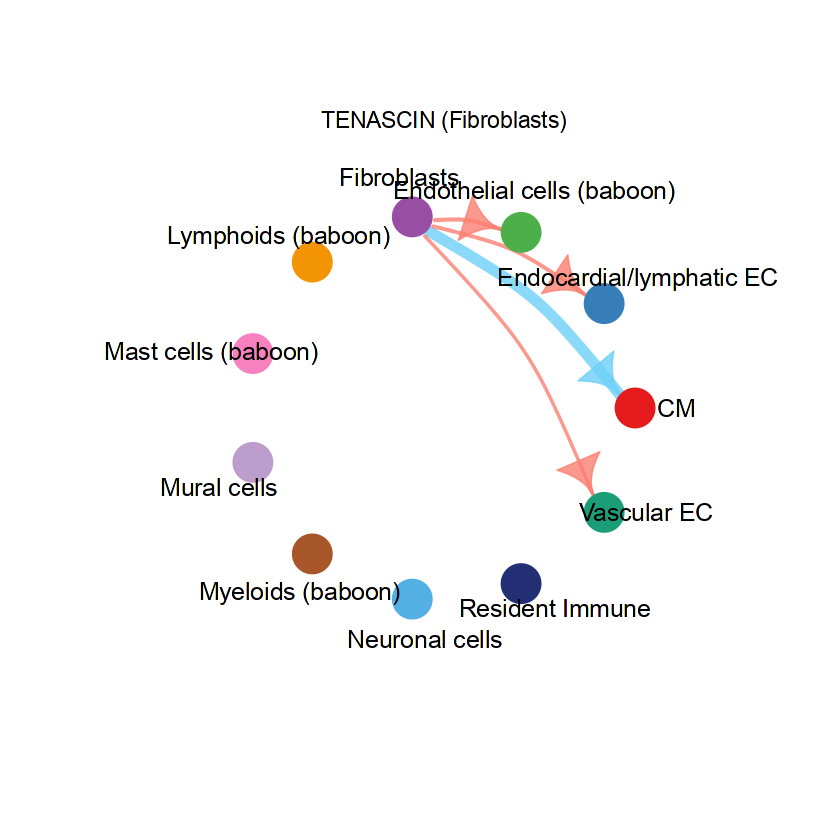

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



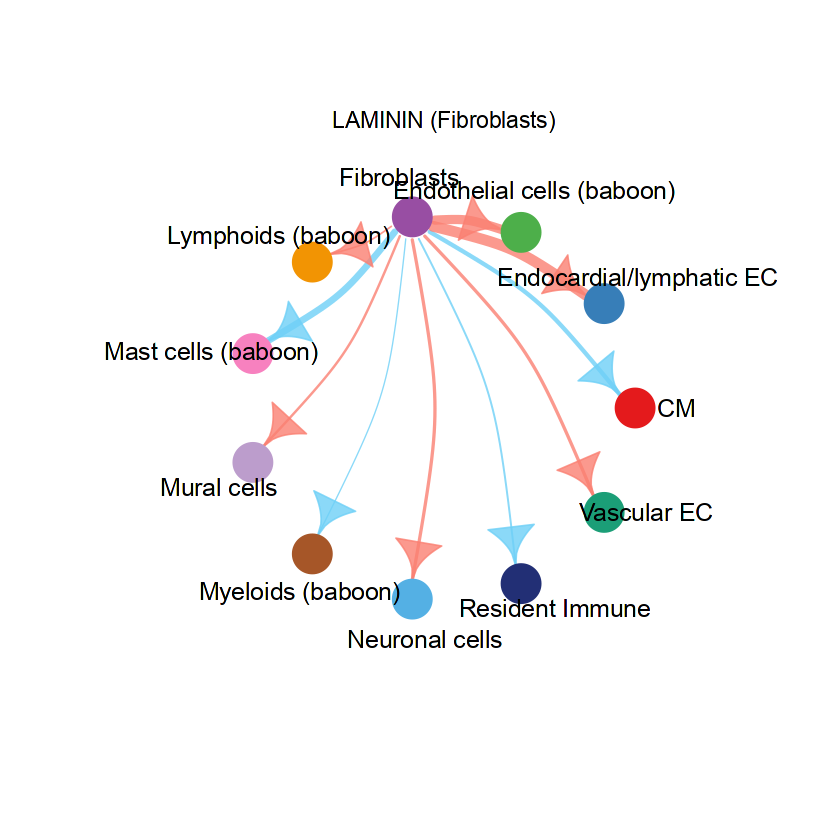

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping THBS: plotting failed - Length of new attribute value must be 1 or 6, the number of target edges, not 3

Skipping NEGR: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping PECAM1: plotting failed - Length of new attribute value must be 1 or 4, the number of target edges, not 3



All pathway-specific differential circle plots for Fibroblasts are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Fibroblasts 
--- Processing sender: Lymphoids (baboon) ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Lymphoids_(baboon)/Lymphoids_(baboon)_diff_sig_table.csv 


Skipping MPZ: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



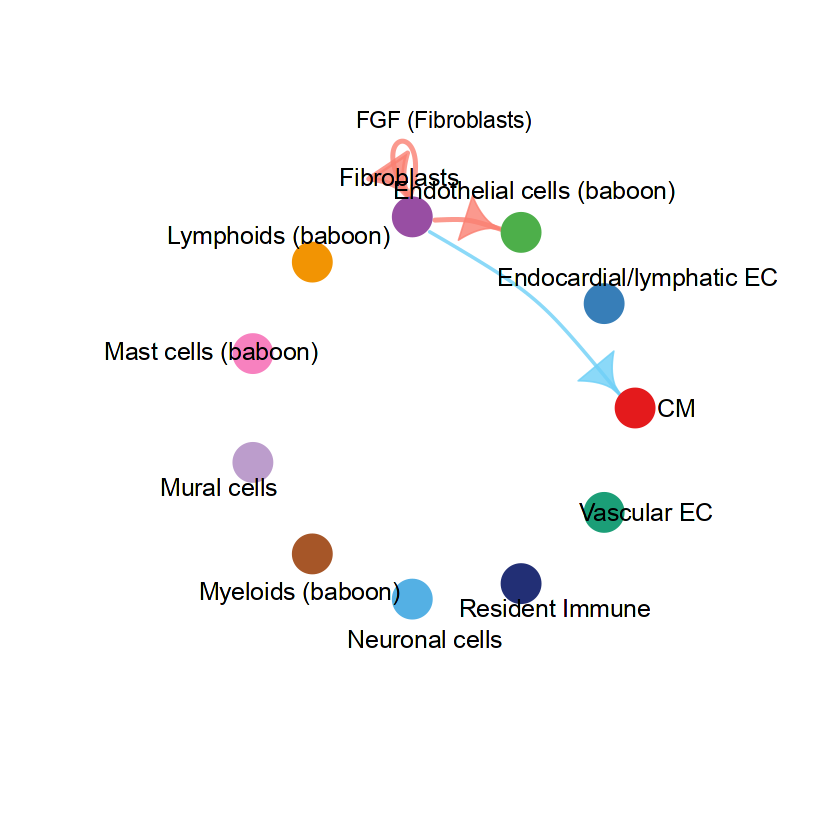

All pathway-specific differential circle plots for Lymphoids (baboon) are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Lymphoids_(baboon) 
--- Processing sender: Mast cells (baboon) ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Mast_cells_(baboon)/Mast_cells_(baboon)_diff_sig_table.csv 


Skipping SEMA4: no interaction in one of the groups

Skipping VISFATIN: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping CD45: plotting failed - Length of new attribute value must be 1 or 4, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



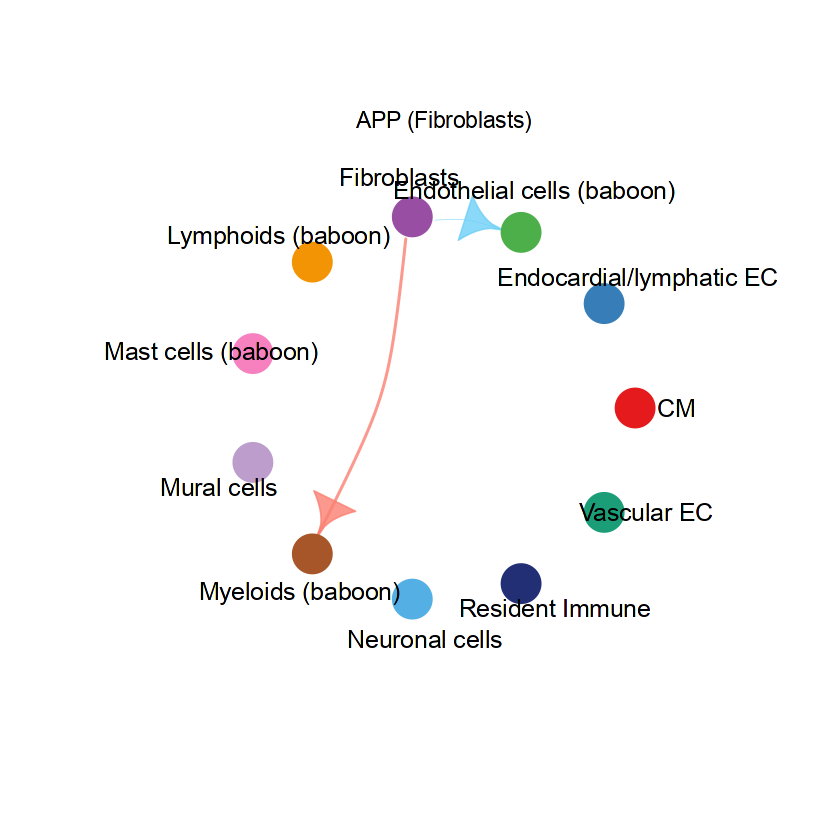

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



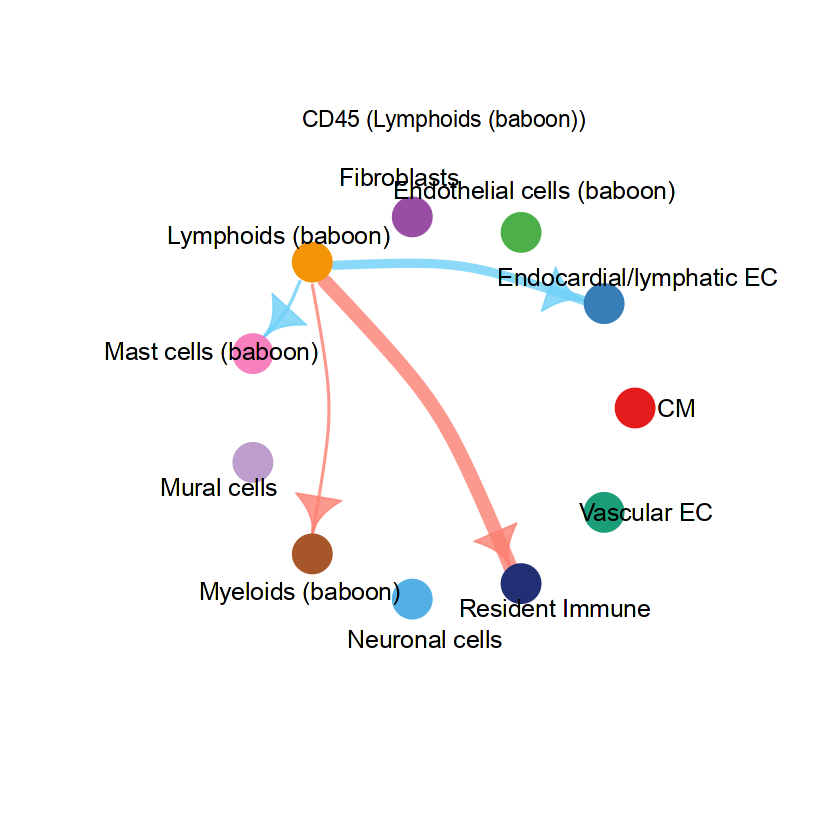

All pathway-specific differential circle plots for Mast cells (baboon) are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Mast_cells_(baboon) 
--- Processing sender: Mural cells ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Mural_cells/Mural_cells_diff_sig_table.csv 


Skipping GHRELIN: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping LAMININ: plotting failed - Length of new attribute value must be 1 or 10, the number of target edges, not 6

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping COLLAGEN: plotting failed - Length of new attribute value must be 1 or 11, the number of target edges, not 7

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



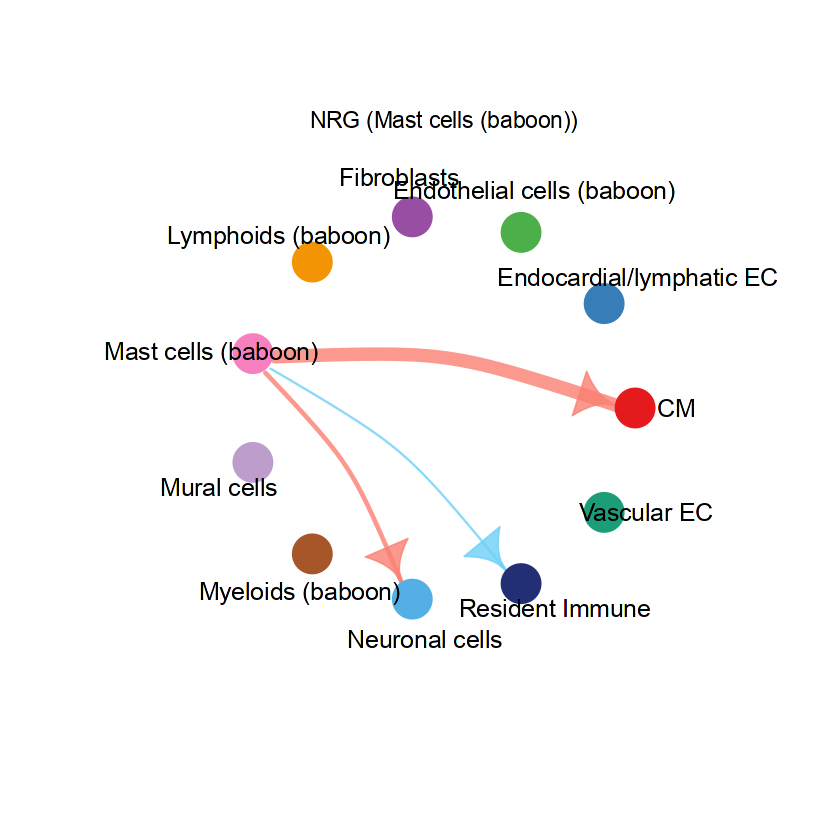

All pathway-specific differential circle plots for Mural cells are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Mural_cells 
--- Processing sender: Myeloids (baboon) ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Myeloids_(baboon)/Myeloids_(baboon)_diff_sig_table.csv 


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping CD45: plotting failed - Length of new attribute value must be 1 or 4, the number of target edges, not 3

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



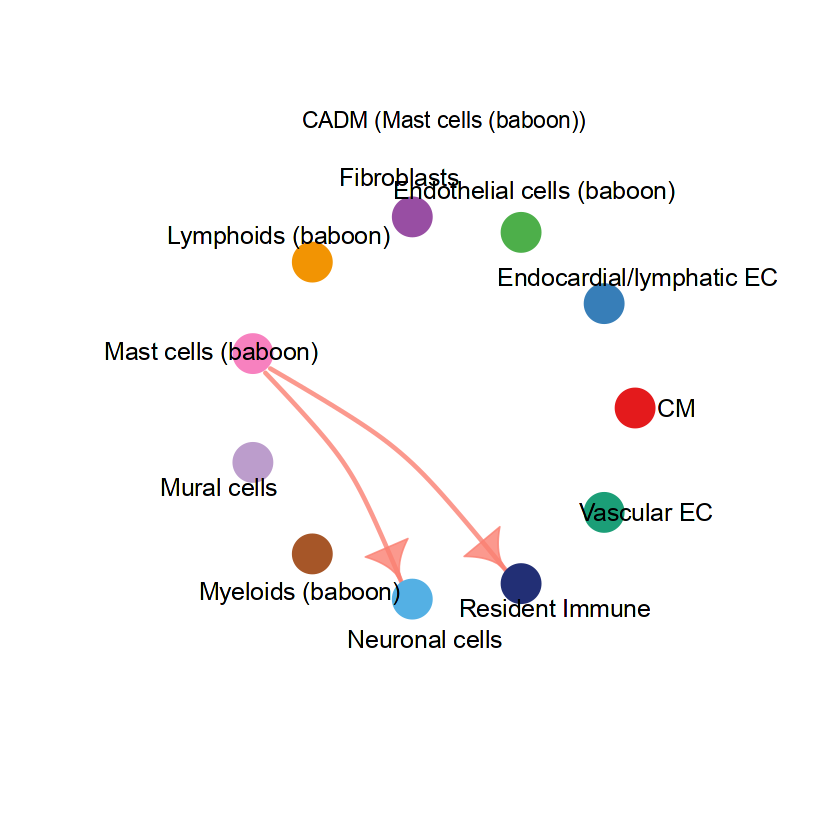

All pathway-specific differential circle plots for Myeloids (baboon) are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Myeloids_(baboon) 
--- Processing sender: Neuronal cells ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Neuronal_cells/Neuronal_cells_diff_sig_table.csv 


Skipping HSPG: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



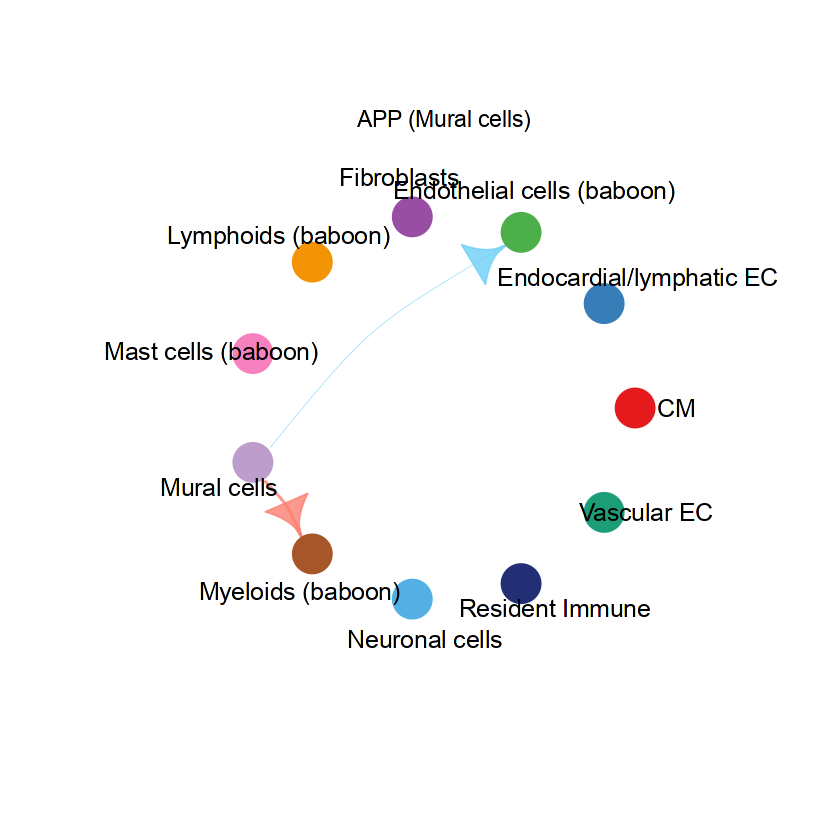

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



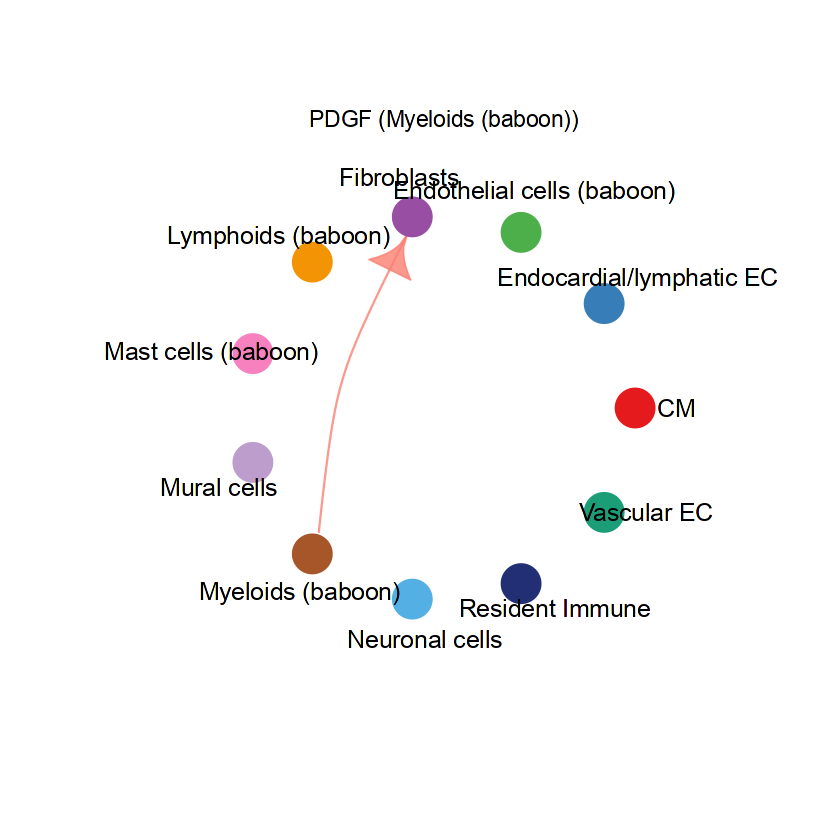

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



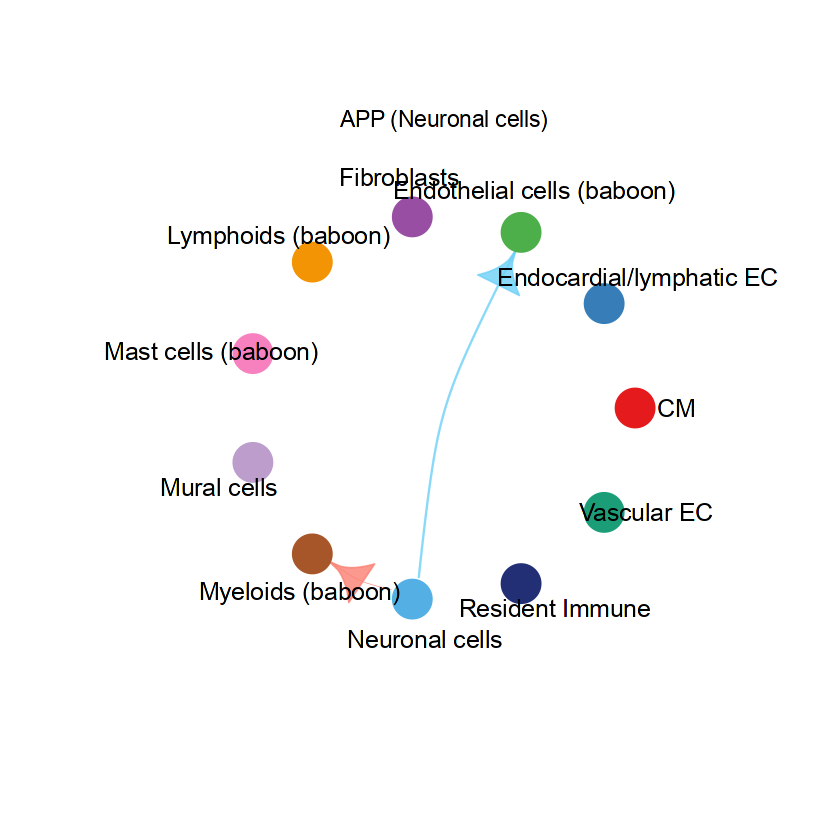

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping LAMININ: plotting failed - Length of new attribute value must be 1 or 10, the number of target edges, not 8

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping CADM: plotting failed - Length of new attribute value must be 1 or 3, the number of target edges, not 2

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



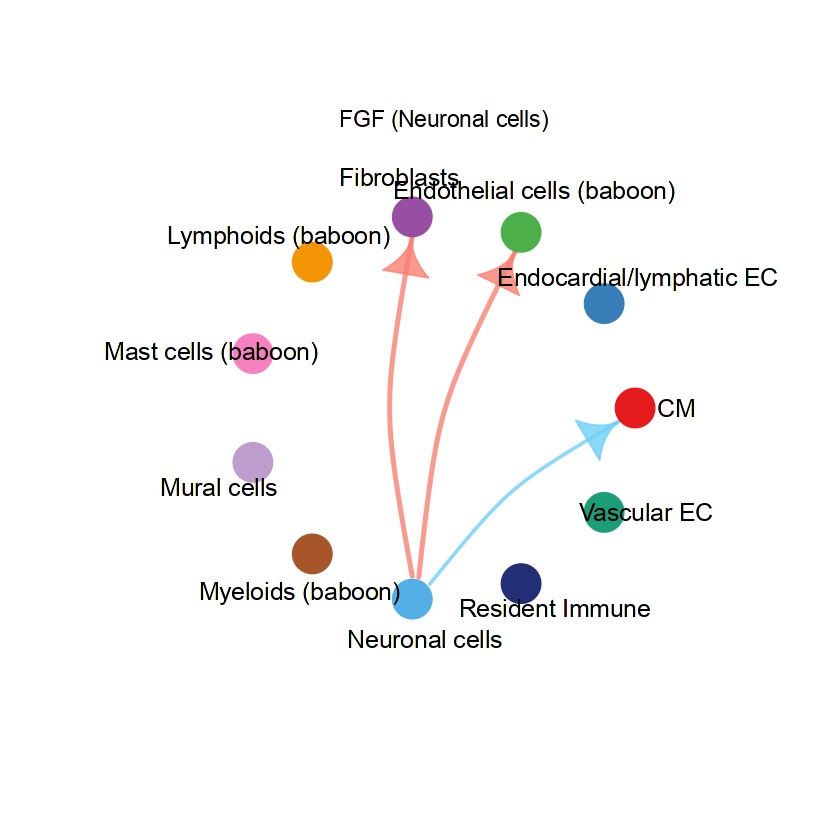

Skipping NGL: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



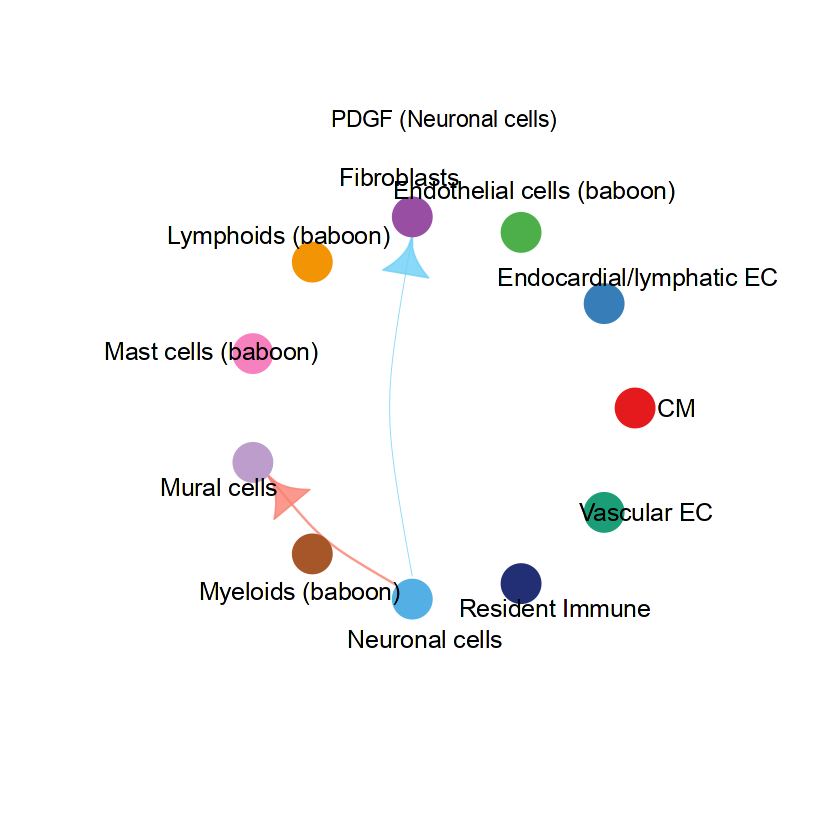

Skipping NRXN: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping COLLAGEN: plotting failed - Length of new attribute value must be 1 or 8, the number of target edges, not 7



All pathway-specific differential circle plots for Neuronal cells are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Neuronal_cells 
--- Processing sender: Resident Immune ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Resident_Immune/Resident_Immune_diff_sig_table.csv 


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping LAMININ: plotting failed - Length of new attribute value must be 1 or 9, the number of target edges, not 8

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Skipping FN1: plotting failed - Length of new attribute value must be 1 or 6, the number of target edges, not 5

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



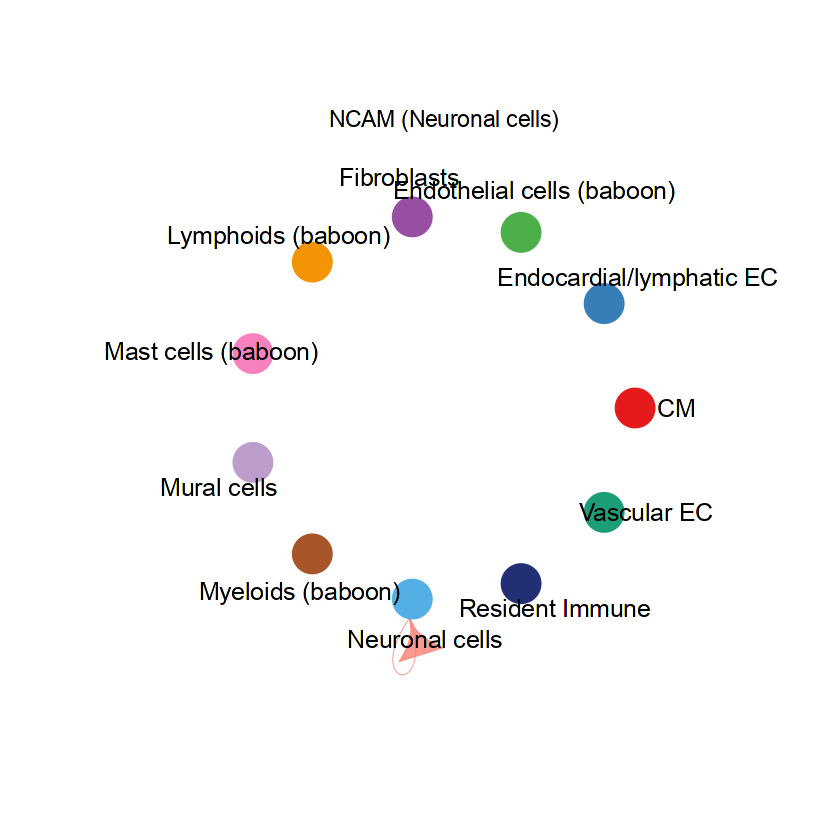

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



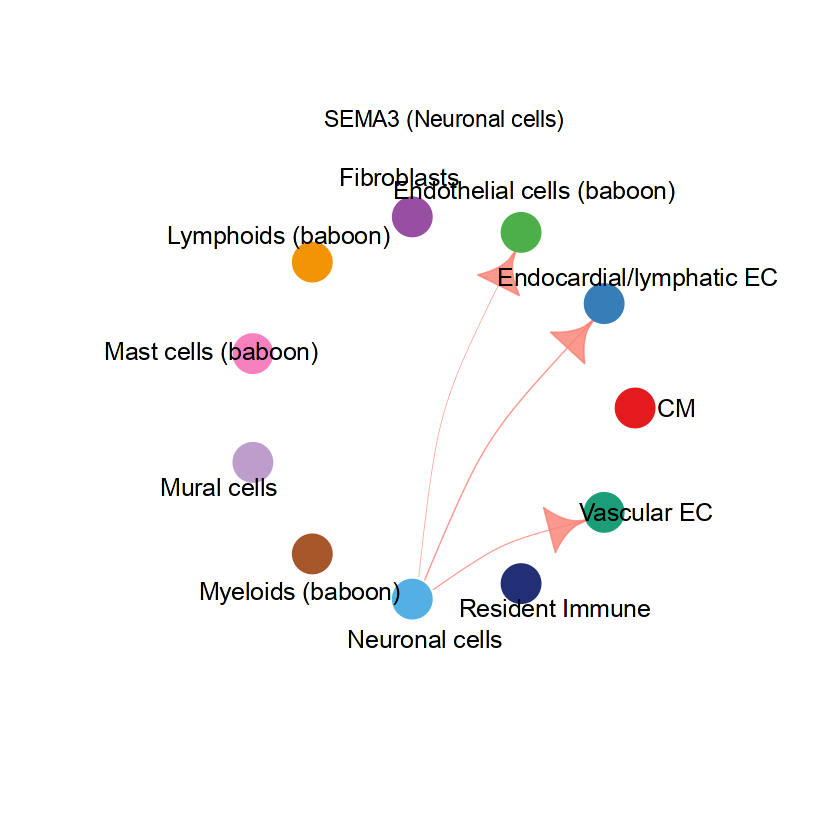

Skipping IL1: no interaction in one of the groups

Skipping VISFATIN: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



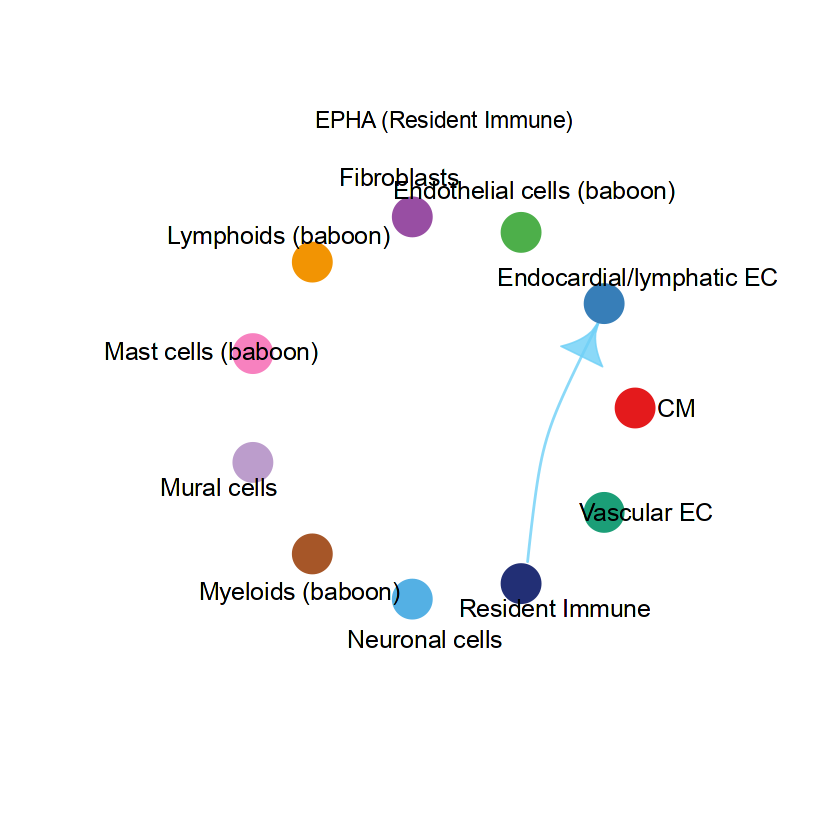

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



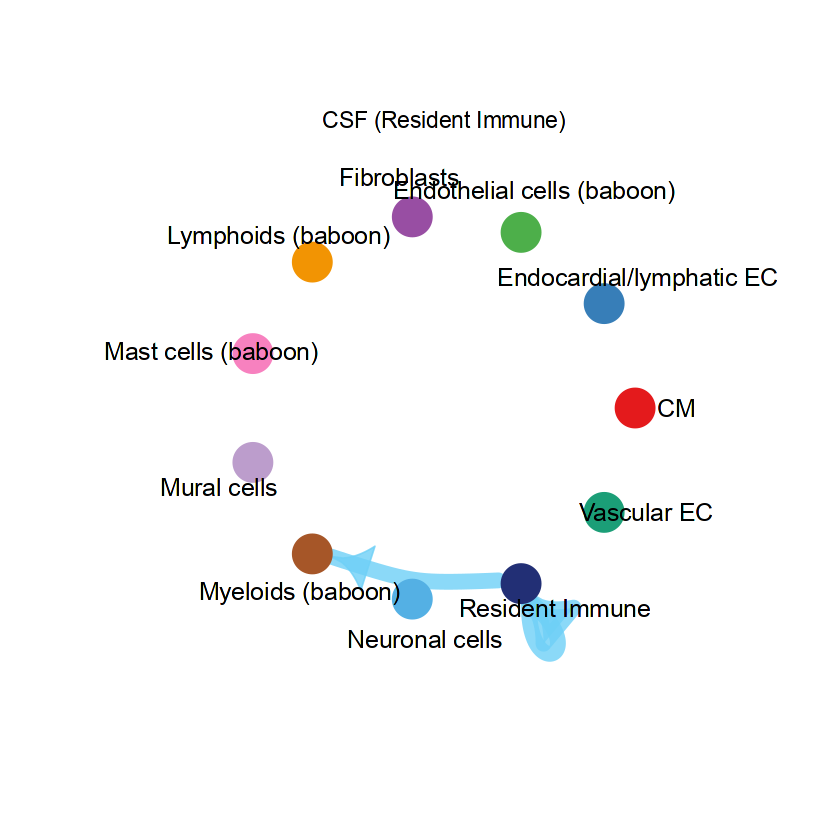

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



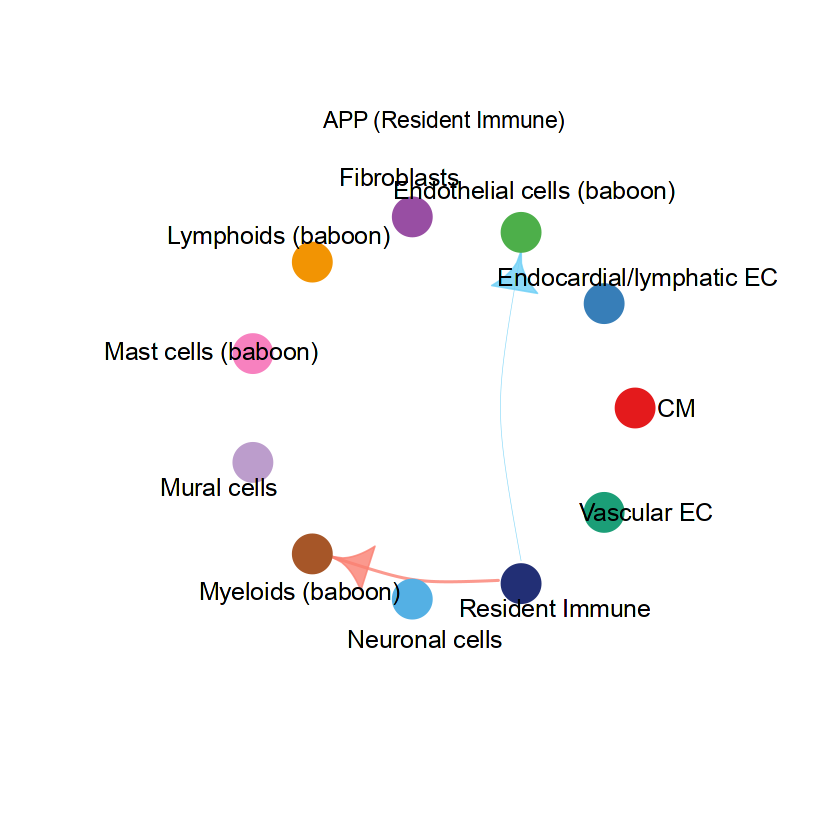

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



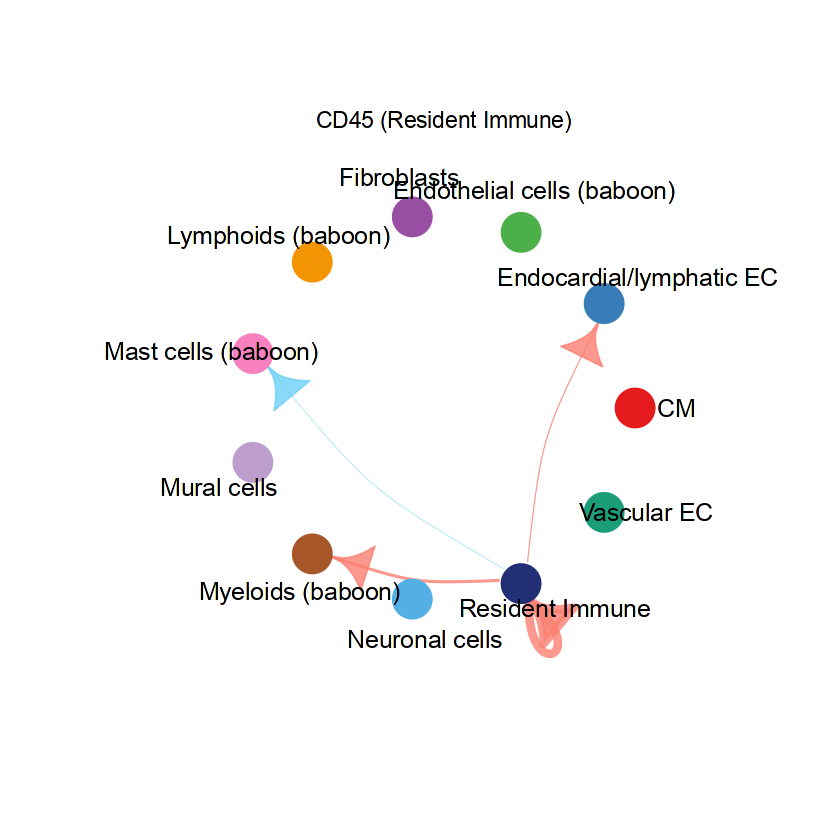

All pathway-specific differential circle plots for Resident Immune are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Resident_Immune 
--- Processing sender: Vascular EC ---
RankNet differential signaling results saved to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Vascular_EC/Vascular_EC_diff_sig_table.csv 


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



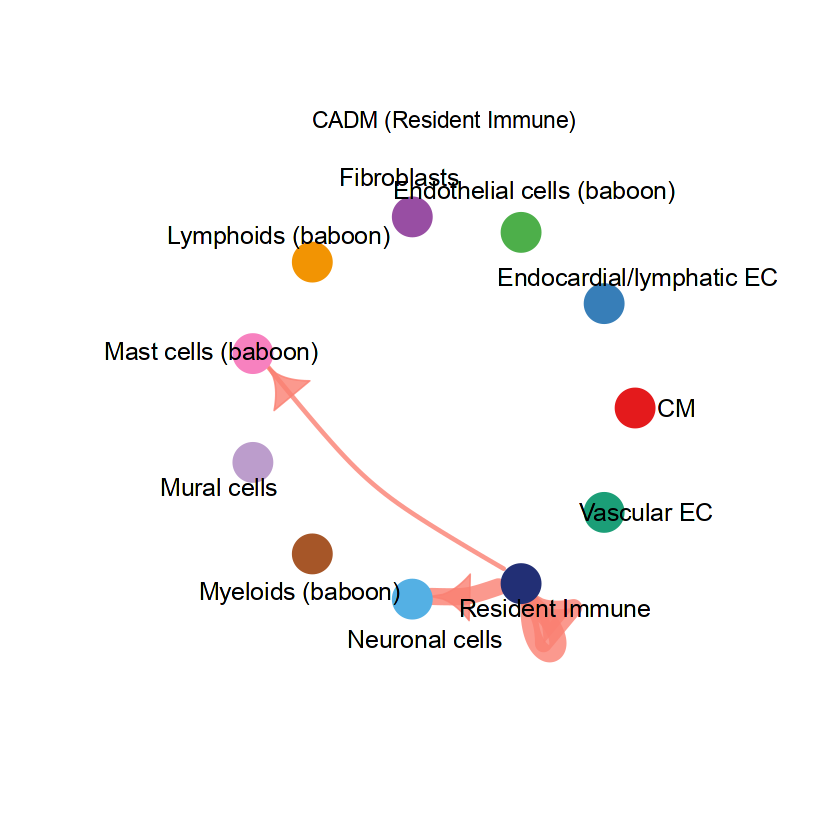

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



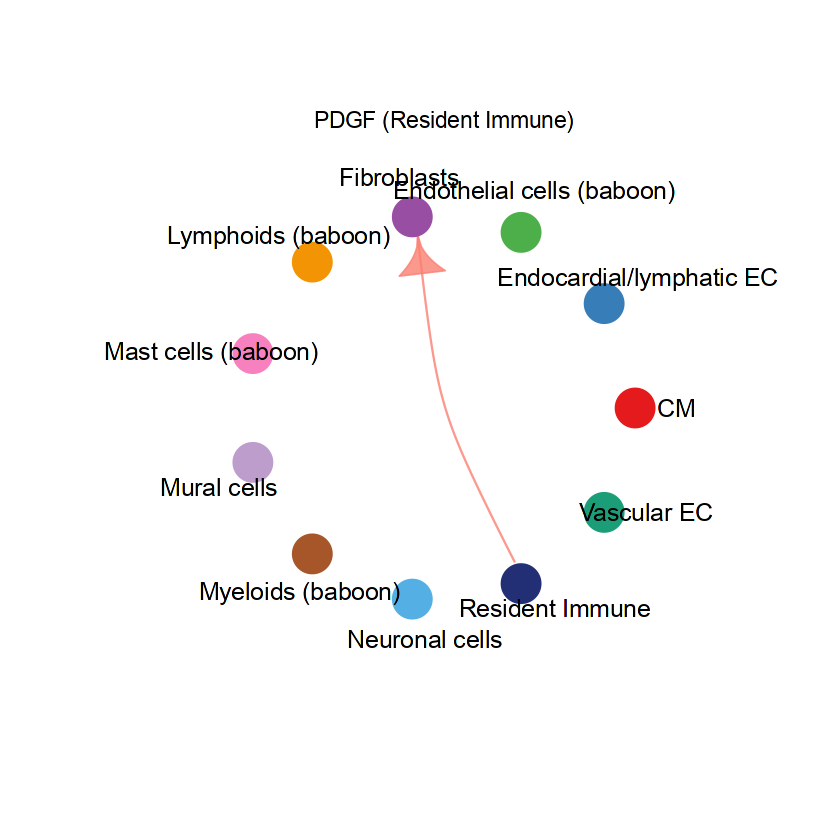

Skipping GHRELIN: no interaction in one of the groups

Skipping HSPG: no interaction in one of the groups

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



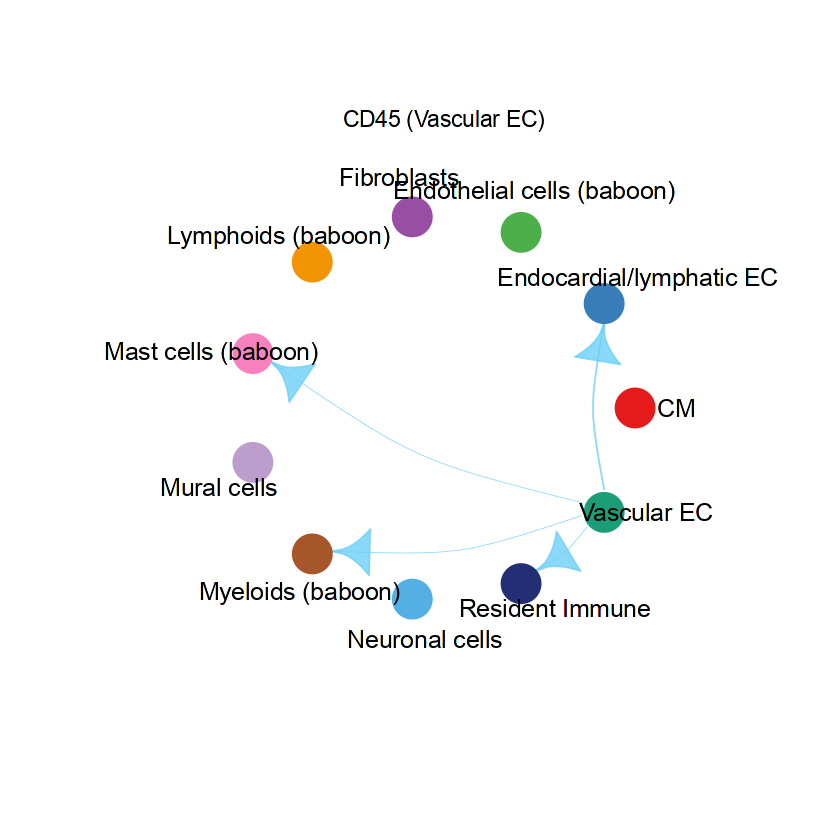

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



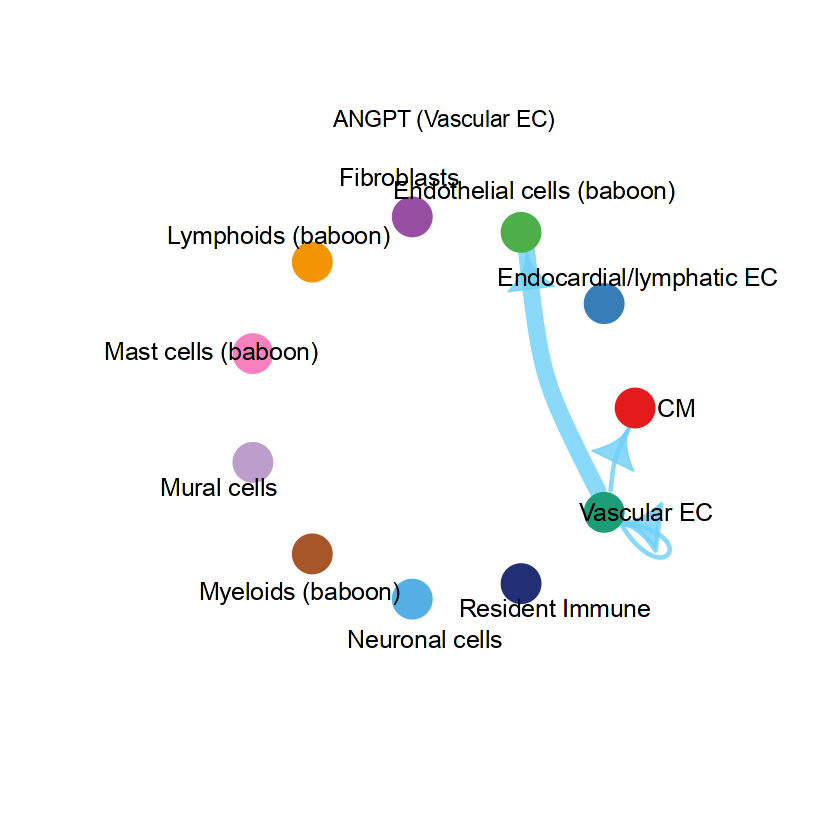

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



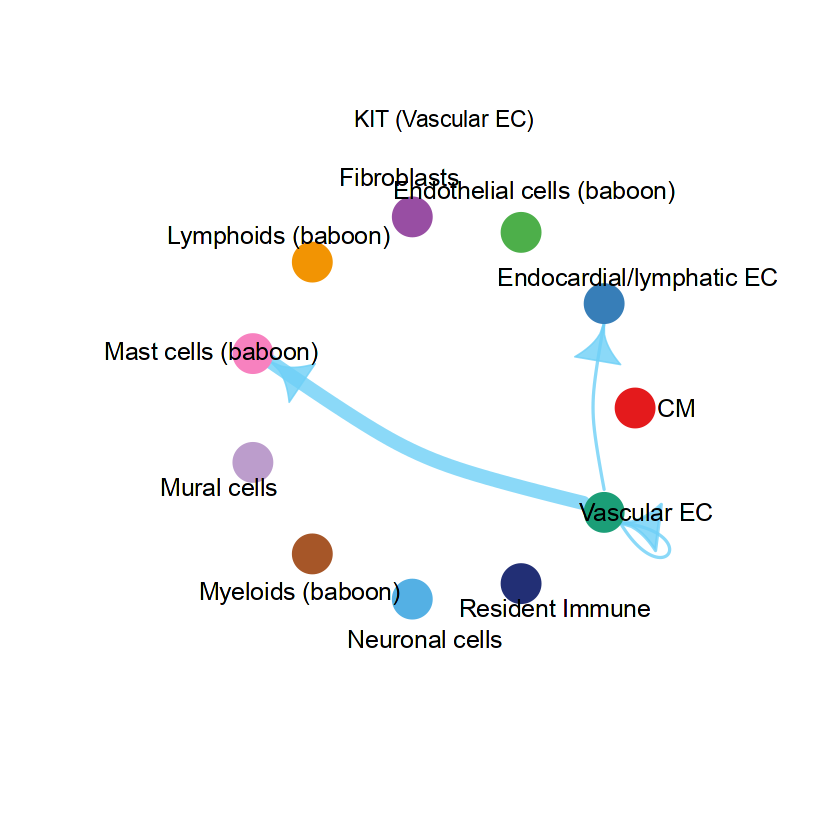

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



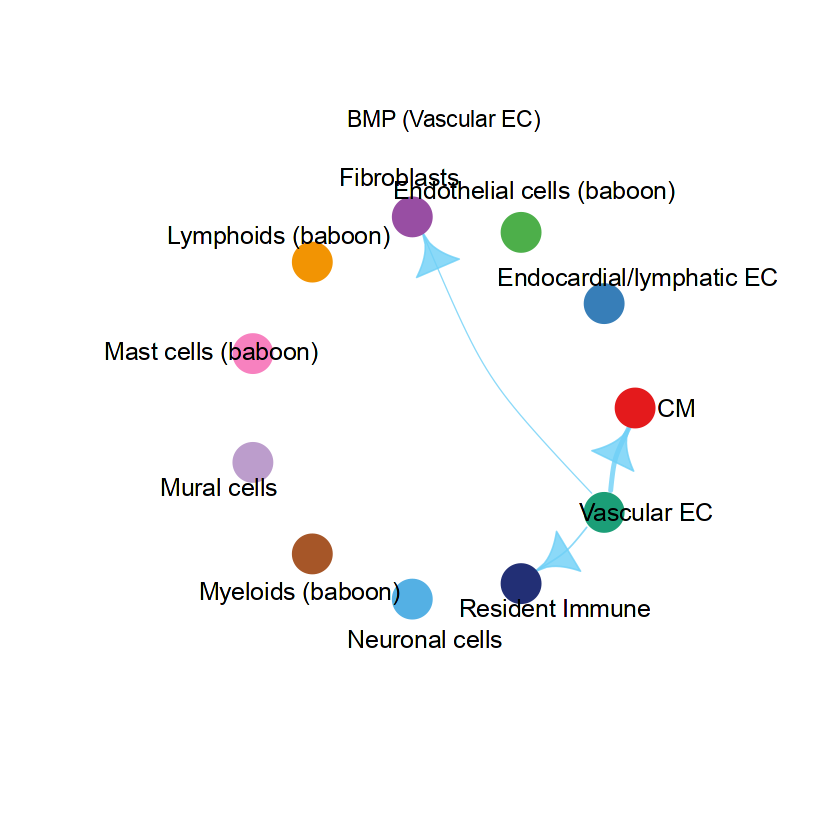

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



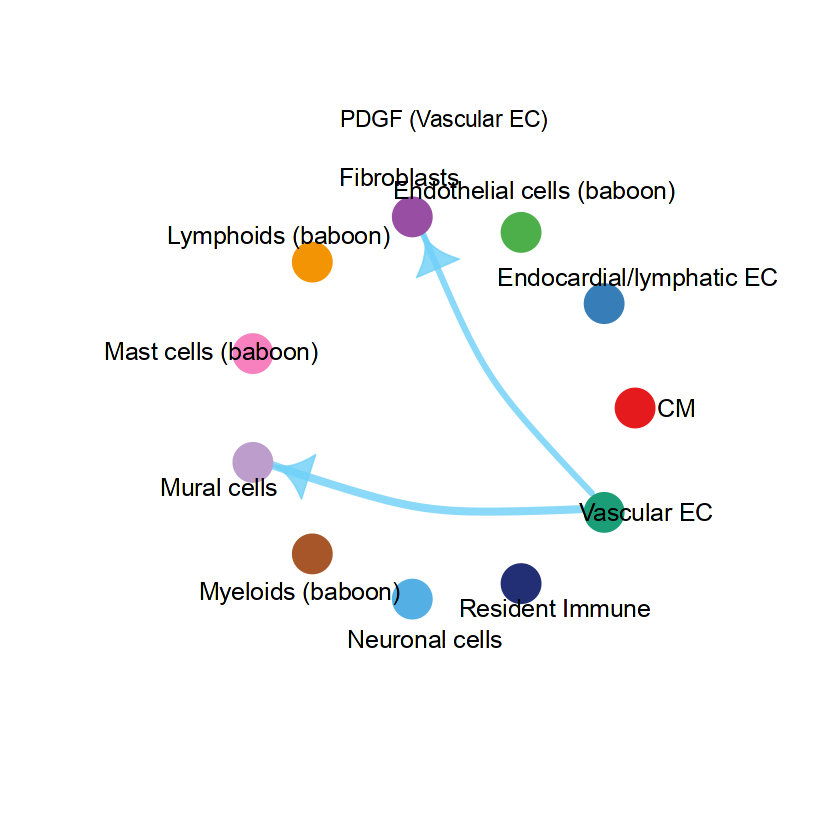

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



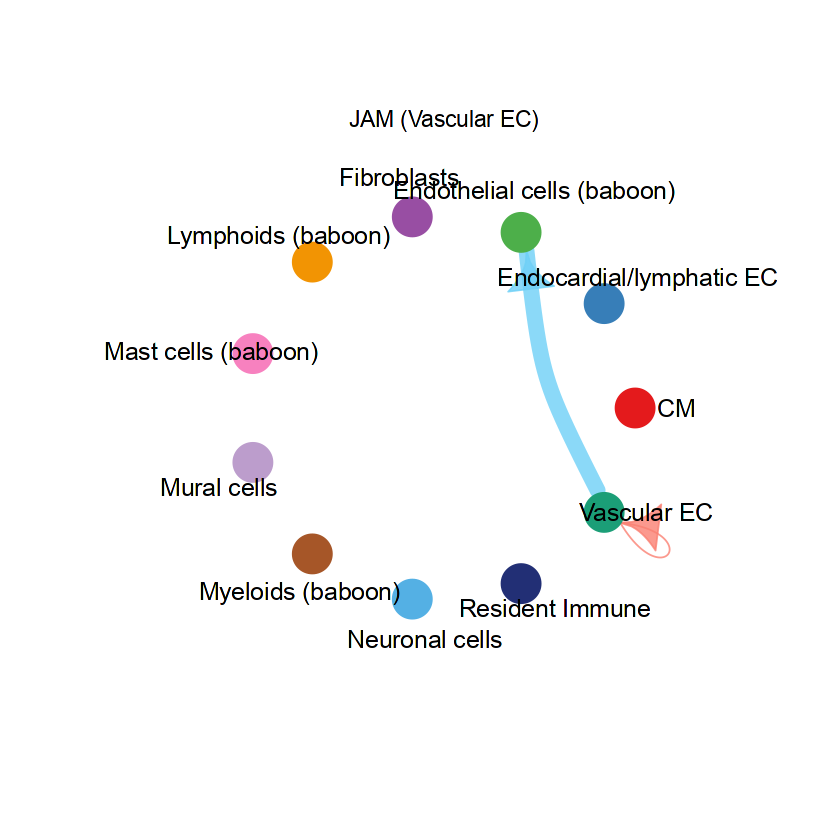

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



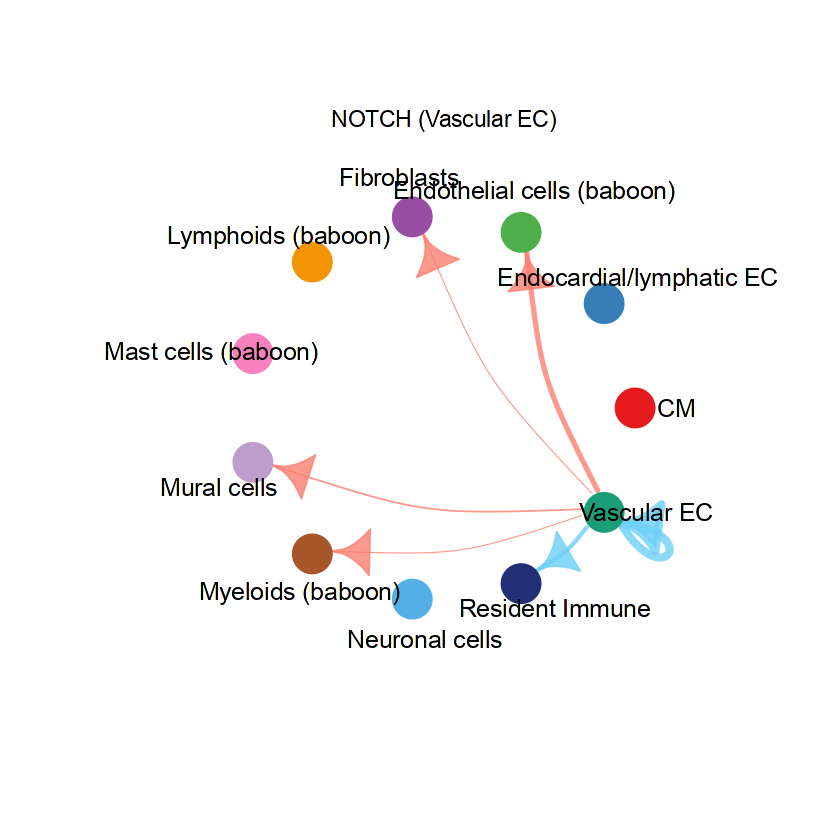

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



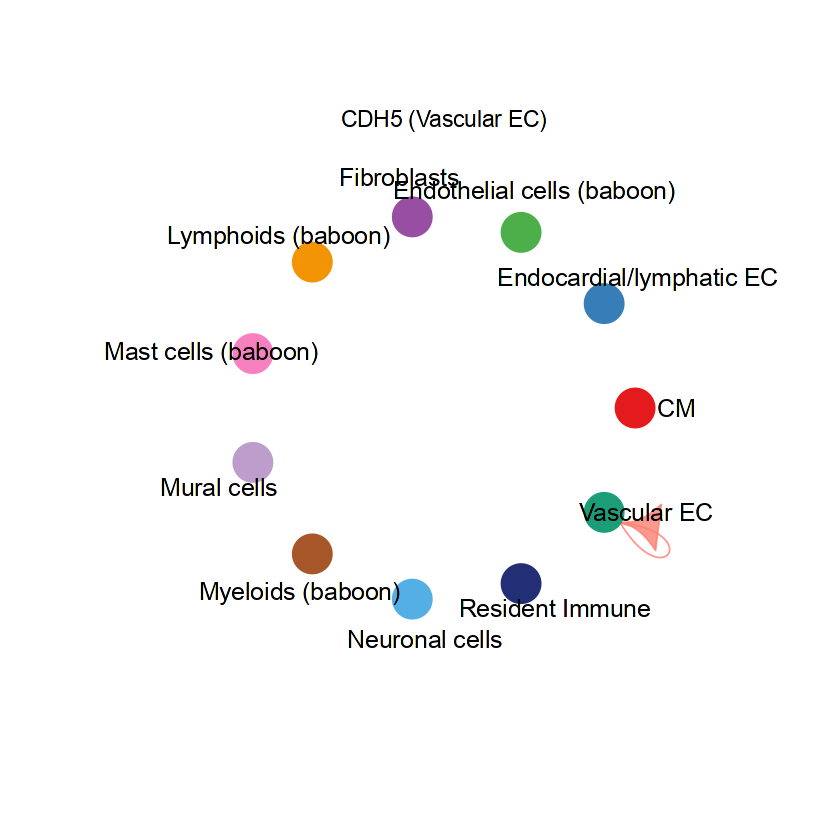

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



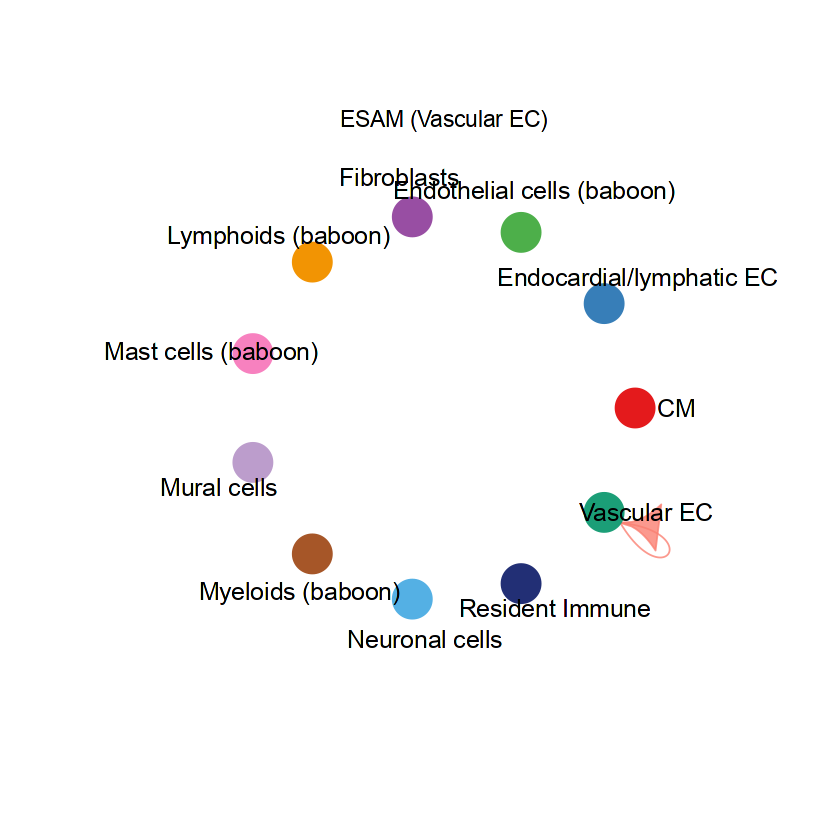

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



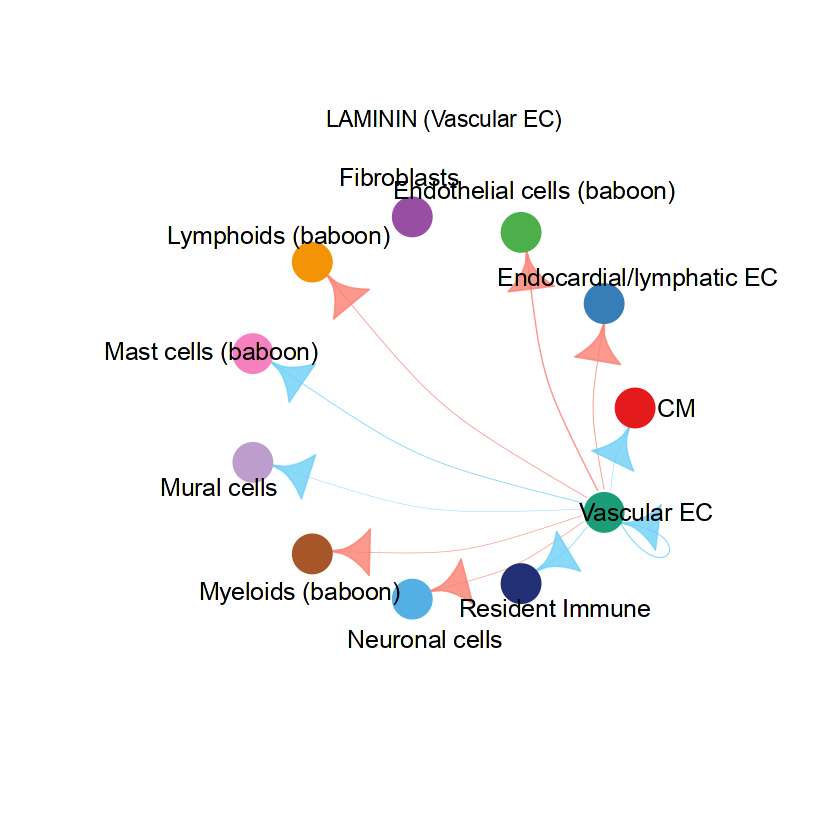

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



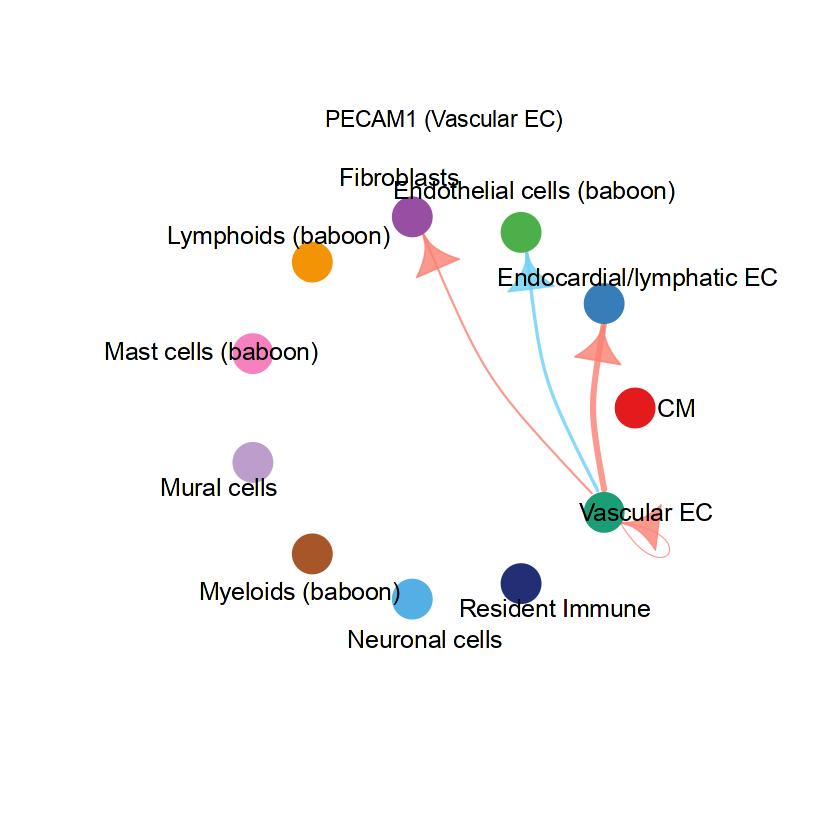

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



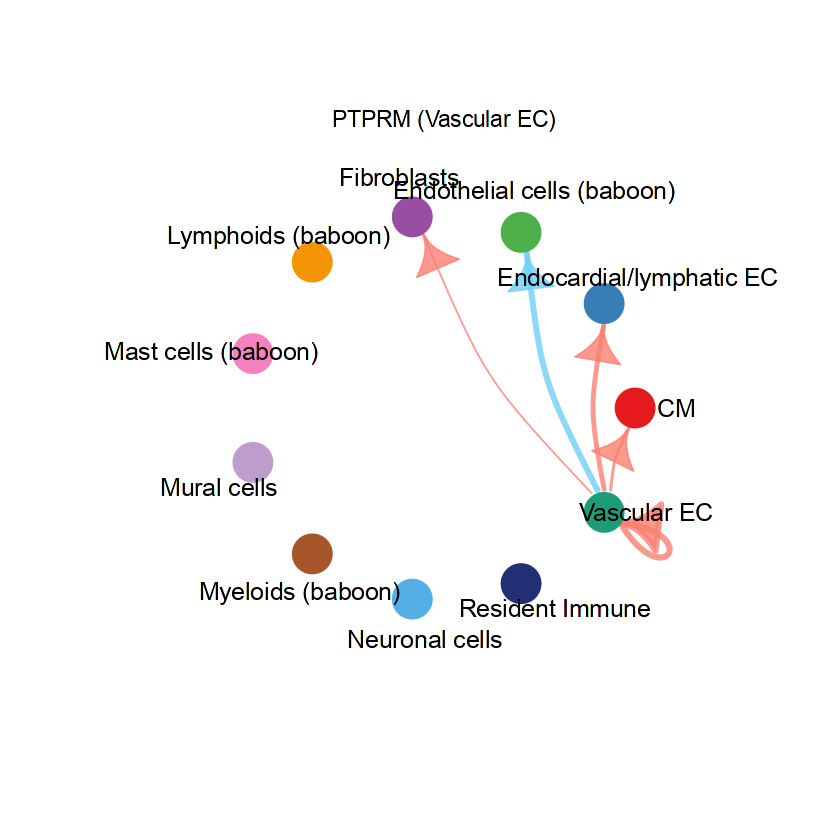

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



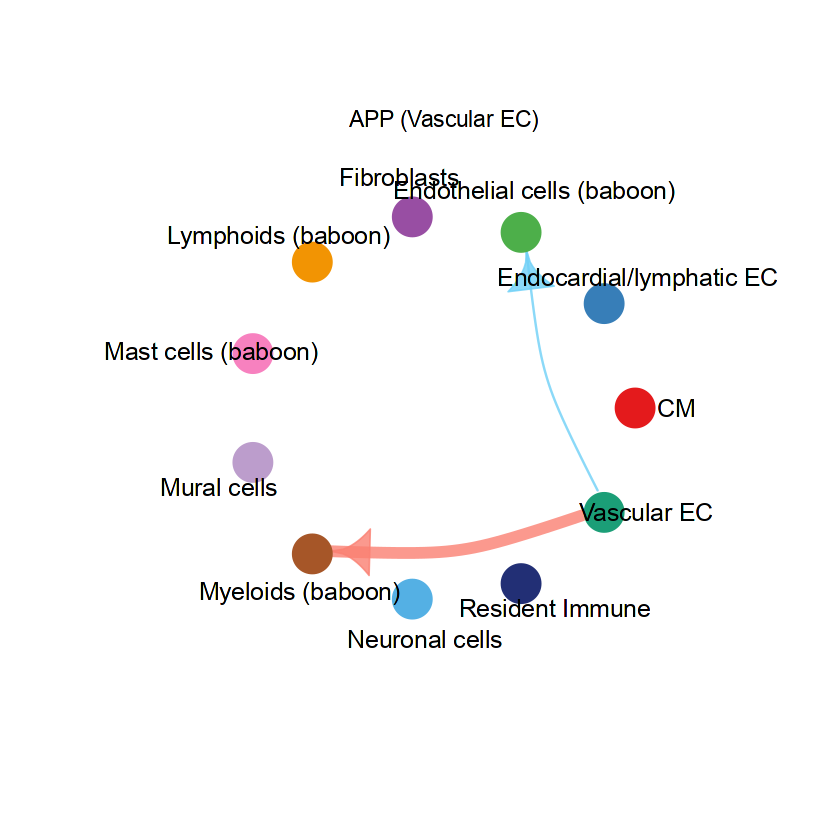

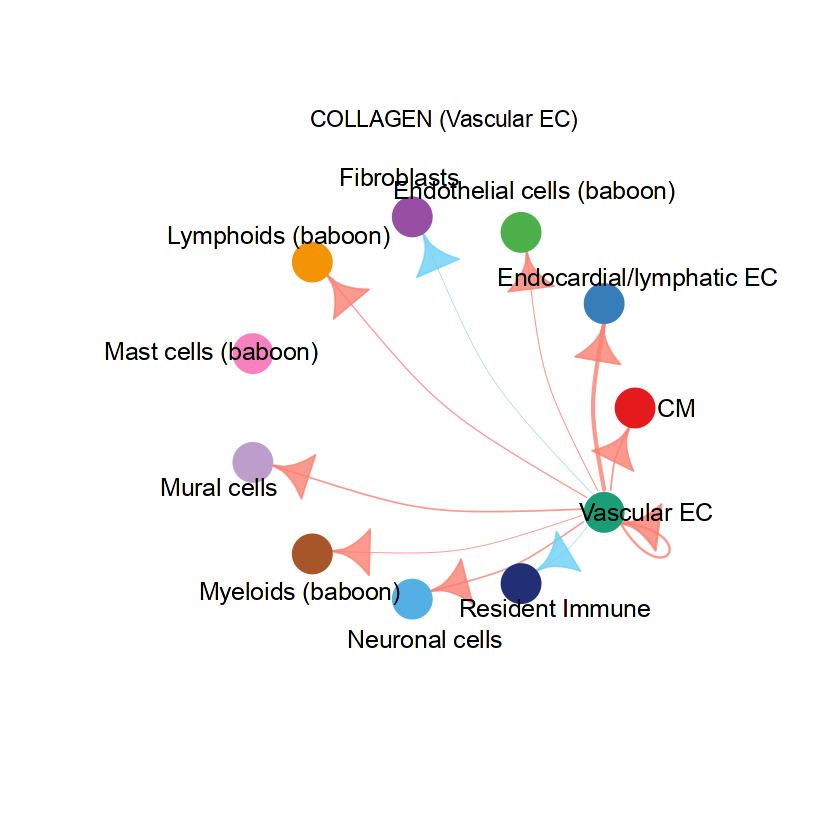

All pathway-specific differential circle plots for Vascular EC are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS/Vascular_EC 
Script finished. All results are in: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS 


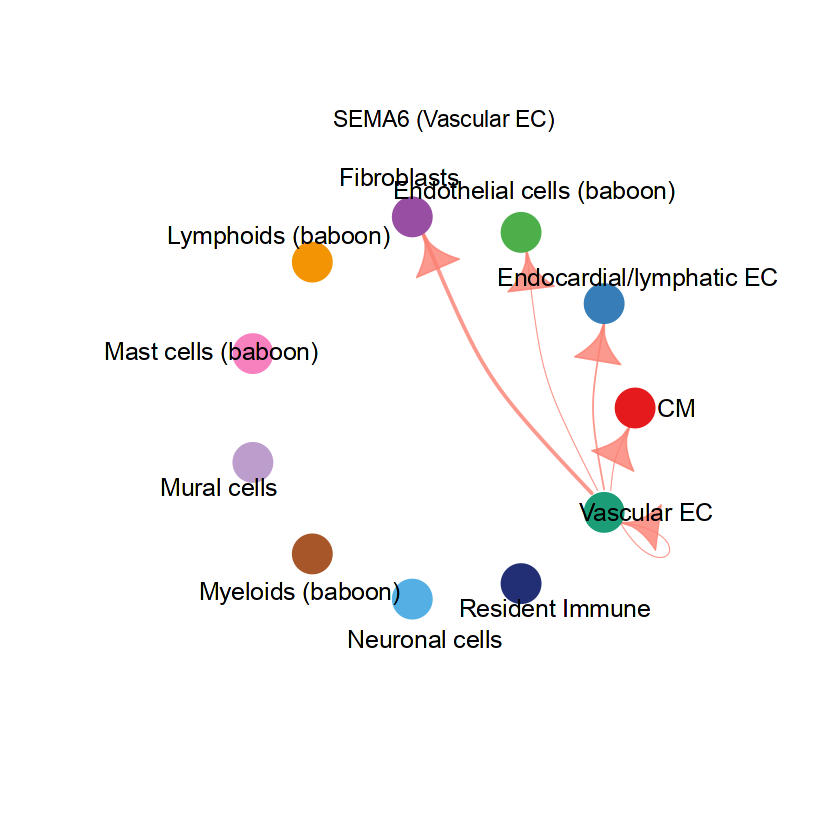

In [14]:
# ---- RankNet differential signaling analysis and plot differential circle plots for ALL senders ----

library(CellChat)

# Get all unique cell types to use as senders
all_senders <- levels(cellchat_extended@idents)

# Master output directory
master_output_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Extended_vs_standard/fig_results/ALL_SENDERS_DIFF_PLOTS"
if (!dir.exists(master_output_dir)) dir.create(master_output_dir, recursive = TRUE)

# Loop through each sender cell type
for (my_sender in all_senders) {
  
  cat("--- Processing sender:", my_sender, "---\n")
  
  # Sanitize the sender name for use in file and directory paths.
  # Replace spaces and forward slashes with an underscore.
  safe_sender_name <- gsub("[ /]", "_", my_sender)

  # Create a sender-specific output directory using the sanitized name
  sender_dir <- file.path(master_output_dir, safe_sender_name)
  if (!dir.exists(sender_dir)) dir.create(sender_dir, recursive = TRUE)
  
  # 1. Run rankNet to get all candidate pathways for this sender
  ranknet_frame <- tryCatch({
    rankNet(
      cellchat_merged,
      mode = "comparison",
      stacked = TRUE,
      do.stat = TRUE,
      cutoff.pvalue = 0.05,
      return.data = TRUE,
      sources.use = my_sender,
      measure = "weight"
    )$signaling.contribution
  }, error = function(e) {
    message(sprintf("Skipping sender %s: rankNet failed - %s", my_sender, e$message))
    return(NULL)
  })
  
  # Skip if no rankNet data was returned
  if (is.null(ranknet_frame)) {
    next
  }
  
  # --- Save as CSV ---
  csv_out <- file.path(sender_dir, paste0(safe_sender_name, "_diff_sig_table.csv"))
  write.csv(ranknet_frame, file = csv_out, row.names = FALSE)
  cat("RankNet differential signaling results saved to:", csv_out, "\n")
  
  # Option 1: Use all tested pathways for plotting
  all_pathways <- unique(ranknet_frame$name)
  
  for (this_pathway in all_pathways) {
    
    # Get group-specific aggregate nets for this pathway
    group1 <- tryCatch({
      aggregateNet(cellchat_extended, signaling = this_pathway, remove.isolate = FALSE)
    }, error = function(e) NULL)
    
    group2 <- tryCatch({
      aggregateNet(cellchat_standard, signaling = this_pathway, remove.isolate = FALSE)
    }, error = function(e) NULL)
    
    # Check if both groups have valid nets
    if (is.null(group1) || is.null(group2)) {
      message(sprintf("Skipping %s: no interaction in one of the groups", this_pathway))
      next
    }
    
    # Merge for diff plotting
    object_list <- list(extended = group1, Standard_protocol = group2)
    cellchat_pathway <- mergeCellChat(object_list, add.names = names(object_list))
    
    # Get maximum edge weight for scaling
    weight.max <- tryCatch({
      getMaxWeight(object_list, slot.name = "netP", attribute = this_pathway)
    }, error = function(e) NULL)
    if (is.null(weight.max)) {
      message(sprintf("Skipping %s: getMaxWeight failed", this_pathway))
      next
    }
    
    # Plot! (tryCatch for robustness)
    g <- tryCatch({
      netVisual_diffInteraction(
        cellchat_pathway,
        weight.scale = TRUE,
        measure = "weight",
        color.edge = c("#FA8072", "#6ECFF6"),
        title.name = sprintf("%s (%s)", this_pathway, my_sender),
        label.edge = FALSE,
        arrow.size = 1.5,
        arrow.width = 2,
        alpha.edge = 0.8,
        margin = 0.4,
        vertex.label.cex = 1.2,
        edge.weight.max = weight.max[1],
        edge.width.max = 10,
        sources.use = my_sender
      )
    }, error = function(e) {
      message(sprintf("Skipping %s: plotting failed - %s", this_pathway, e$message))
      return(NULL)
    })
    
    if (!is.null(g)) {
      safe_name <- gsub("[/\\\\ ]", "_", this_pathway)
      pdf(file = file.path(sender_dir, sprintf("%s_differential_%s.pdf", safe_name, safe_sender_name)), width = 7, height = 7)
      print(g)
      dev.off()
    }
  }
  
  cat("All pathway-specific differential circle plots for", my_sender, "are in:", sender_dir, "\n")
}

cat("Script finished. All results are in:", master_output_dir, "\n")